# Visualisasi Tujuan 2 — Pembangunan Sistem QA Berbasis Instruction-Tuned SLM

Notebook ini hanya membaca **artefak hasil aktual** yang ditempatkan di `Hasil/tujuan2`.
Notebook tidak membaca notebook pengolahan, tidak memakai modul penghubung, dan tidak memiliki
angka hasil penelitian sebagai fallback. Jika artefak wajib belum tersedia, eksekusi dihentikan
dengan daftar nama berkas yang perlu dimasukkan ke folder hasil.

| Bagian | Cakupan | Artefak pada `Hasil/tujuan2` |
|---|---|---|
| 1-2 | Korpus, pembersihan, strukturisasi, chunking | JSON hasil cleaning + `laporan_chunking_bab4.json` |
| 3 | Pembentukan dan evaluasi dataset QA | JSON/JSONL/CSV keluaran notebook 05-07 |
| 4 | Konfigurasi dan training | `training_config.json`, `index_manifest.json`, `*_training_summary.json` |
| 5-6 | Evaluasi otomatis utama dan GGUF Q4_K_M | `summary_metrics.csv`, `summary_metrics_gguf.csv`, dan `*_scored*.csv` |
| 7 | Evaluasi manusia | `human_eval_*.csv` pada folder hasil |


## Setup dan konfigurasi global

In [225]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [226]:
%cd /content/drive/MyDrive/Skripsi/SourceCode/SkripsiNabil/Hasil/tujuan2

/content/drive/MyDrive/Skripsi/SourceCode/SkripsiNabil/Hasil/tujuan2


In [227]:
%matplotlib inline
import os
import json
import re
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

plt.rcParams.update({"font.family": "serif", "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.dpi": 150})

C_RAW, C_CLEAN = "#b3b3b3", "#2c6fbb"
C_BASE, C_FT = "#b3b3b3", "#2c6fbb"
C_GEMMA, C_LLAMA = "#e08a1e", "#3a7d44"
C_DROP, C_KEEP = "#c0392b", "#3a7d44"
C_ACCENT, C_MUTED = "#e08a1e", "#7f8c8d"

MODEL_KEYS = ["gemma2", "llama3.2"]
CONDITIONS = ["base", "finetuned"]
METRICS = ["em", "f1", "rouge_l", "indobertscore"]
METRIC_LABELS = {"em": "Exact Match", "f1": "Token F1", "rouge_l": "ROUGE-L", "indobertscore": "IndoBERTScore"}
MODEL_LABELS = {"gemma2": "Gemma-2-2B", "llama3.2": "Llama-3.2-3B"}

def temukan_root(mulai=Path.cwd()):
    mulai = Path(mulai).resolve()
    for kandidat in (mulai, *mulai.parents):
        if (kandidat / "Hasil" / "tujuan2").is_dir():
            return kandidat
    raise FileNotFoundError("Root proyek dengan Hasil/tujuan2 tidak ditemukan.")

PROJECT_ROOT = temukan_root()
DATA_TUJUAN2 = PROJECT_ROOT / "Hasil" / "tujuan2"

def hasil_t2(nama, wajib=False):
    cocok = sorted(DATA_TUJUAN2.rglob(nama))
    if len(cocok) > 1:
        raise RuntimeError(f"Artefak ambigu, ditemukan lebih dari satu {nama}: {cocok}")
    if cocok:
        return cocok[0]
    tujuan = DATA_TUJUAN2 / nama
    if wajib:
        raise FileNotFoundError(f"Artefak wajib belum ada di Hasil/tujuan2: {nama}")
    return tujuan

def baca_json(nama):
    with hasil_t2(nama, wajib=True).open(encoding="utf-8") as f:
        return json.load(f)

def baca_jsonl(nama):
    with hasil_t2(nama, wajib=True).open(encoding="utf-8") as f:
        return [json.loads(baris) for baris in f if baris.strip()]

def ada(*berkas):
    return all(Path(f).exists() for f in berkas)

def lewati(pesan):
    print(f"[DILEWATI] {pesan}")

def anotasi_funnel(ax, nilai, keterangan):
    puncak = max(nilai)
    for i, (teks, warna) in enumerate(keterangan):
        y = max(nilai[i], nilai[i + 1]) + puncak * .06
        ax.text(i + .5, y, teks, ha="center", va="bottom", fontsize=8.5, color=warna,
                bbox=dict(boxstyle="round,pad=.28", facecolor="white", edgecolor=warna,
                          alpha=.9, linewidth=.5))


## Pemuatan data aktual

Sel berikut membaca artefak secara langsung dari `Hasil/tujuan2`. Jika artefak wajib belum tersedia,
eksekusi berhenti dengan daftar berkas yang perlu dilengkapi; tidak ada fallback angka lama.


In [228]:
# Sel ini sengaja hanya membaca artefak di Hasil/tujuan2.
WAJIB = [
    "laporan_chunking_bab4.json", "generation_statistics.json", "raw_records.jsonl",
    "laporan_eksplorasi_bab4.json", "filtered_records.jsonl", "removed_records.jsonl",
    "qc_tahap1_report.json", "diversity_summary.json", "opener_distribution.csv",
    "indobert_similarity_summary.json", "indobert_similarity_full.csv", "dataset_manifest.json", "index_manifest.json",
    "training_config.json", "gemma2_training_summary.json", "llama3.2_training_summary.json",
    "train.csv", "val.csv", "test.csv",
]
kurang = [nama for nama in WAJIB if not hasil_t2(nama).exists()]
if kurang:
    raise FileNotFoundError("Artefak Tujuan 2 belum lengkap di Hasil/tujuan2:" + "".join(f"\n- {x}" for x in kurang))

# Statistik cleaning berasal dari setiap JSON hasil cleaning yang memiliki cleaning_summary.
clean_rows = []
for p in DATA_TUJUAN2.rglob("*.json"):
    try:
        with p.open(encoding="utf-8") as f:
            dok = json.load(f)
    except (json.JSONDecodeError, UnicodeDecodeError, OSError):
        continue
    cs = dok.get("cleaning_summary") if isinstance(dok, dict) else None
    if not isinstance(cs, dict):
        continue
    meta = dok.get("document_metadata", {})
    nama = meta.get("nama_file") or meta.get("source_file") or p.stem
    nama = Path(str(nama)).stem
    clean_rows.append({
        "nama_file": nama, "halaman": cs["total_pages"],
        "chars_raw": cs["total_chars_raw"], "chars_clean": cs["total_chars_clean"],
        "reduction_pct": cs["reduction_pct"], "max_chars_page": cs["max_chars_page"],
        "min_chars_page": cs["min_chars_page"],
        "picture_removed": cs.get("picture_blocks_removed", 0),
        "watermark_removed": cs.get("watermark_removed", 0),
        "empty_pages": cs["empty_pages"], "low_char_pages": cs["low_char_pages"],
    })
if not clean_rows:
    raise FileNotFoundError("Tidak ada JSON hasil cleaning dengan objek cleaning_summary di Hasil/tujuan2.")
df_clean = pd.DataFrame(clean_rows).drop_duplicates("nama_file")

chunk_report = baca_json("laporan_chunking_bab4.json")
df_chunk = pd.DataFrame(chunk_report["per_document"]).rename(columns={"source_file": "nama_file"})
df_chunk["nama_file"] = df_chunk["nama_file"].map(lambda x: Path(str(x)).stem)
CHUNK_TYPE_DIST = chunk_report["chunk_type_distribution"]
EXCLUSION_DIST = chunk_report["exclusion_summary"]
PROVENANCE_FALLBACK = chunk_report["provenance_fallback_count"]
TOTAL_CHUNKS = chunk_report["total_chunks"]

gen = baca_json("generation_statistics.json")
GEN_LLM = gen["generation_model"]
SECTIONS_RAW = gen["total_sections_raw"]
SECTIONS_SELECTED = gen["total_sections_selected"]
RAW_RECORDS = gen["total_raw_records"]
GEN_FAILURES = gen["total_failures"]
GEN_SKIPPED = gen["total_skipped_items"]
CACHE_HIT_RATE = gen["cache_hit_rate_pct"]
GEN_FILTER_SECTION = gen["filter_statistics"]
tu = gen["token_usage"]
TOKEN_USAGE = {"prompt": tu.get("prompt_tokens", 0), "cached": tu.get("cached_tokens", 0),
               "completion": tu.get("completion_tokens", 0)}
PARSE_STATUS = gen["parse_status_distribution"]

raw_records = baca_jsonl("raw_records.jsonl")
explore = baca_json("laporan_eksplorasi_bab4.json")
TASK_TYPE_DIST = dict(Counter(r["task_type"] for r in raw_records))
SUBTASK_RAW = dict(Counter(r["subtask_type"] for r in raw_records))
REASONING_SOURCE = dict(Counter(r.get("reasoning_source", "") for r in raw_records))
GENERATION_FOCUS = dict(Counter(r.get("generation_focus", "") for r in raw_records))
PARSE_STATUS = dict(Counter(r.get("parse_status", "") for r in raw_records))

doc_counts = Counter(r["document_title"] for r in raw_records)
section_keys = {(r["document_title"], r["section_id"]) for r in raw_records}
DOK_UNIK, SECTION_UNIK = len(doc_counts), len(section_keys)
doc_values = np.array(list(doc_counts.values()))
REC_PER_DOK = {"min": int(doc_values.min()), "median": float(np.median(doc_values)), "max": int(doc_values.max())}
TOP_DOKUMEN = dict(doc_counts.most_common(5))
BOTTOM_DOKUMEN = dict(sorted(doc_counts.items(), key=lambda x: x[1])[:5])

panjang = {
    "Instruction": [len(r.get("instruction", "").split()) for r in raw_records],
    "Response": [len(r.get("response", "").split()) for r in raw_records],
    "CoT": [len(r.get("cot", "").split()) for r in raw_records],
}
PANJANG_STAT = pd.DataFrame({k: {"min": min(v), "max": max(v), "mean": np.mean(v), "median": np.median(v)}
                             for k, v in panjang.items()}).T
brackets = [(0, 5), (5, 10), (10, 20), (20, 50), (50, 100), (100, 200), (200, np.inf)]
BUCKET_PANJANG = {k: {f"[{lo}+)" if np.isinf(hi) else f"[{lo}–{int(hi)})": sum(lo <= x < hi for x in v)
                       for lo, hi in brackets} for k, v in panjang.items()}
CONTEXT_SPANS = {f"{n} span": c for n, c in sorted(Counter(len(r.get("context", [])) for r in raw_records).items())}

sp = explore["statistik_panjang"]
TEMUAN_KUALITAS = {
    "Angka pada jawaban tidak terlacak di konteks": explore["kesesuaian_numerik"]["n_tidak_cocok"],
    "Residu notasi tabel pada konteks": explore["residu_tabel"]["n_terindikasi"],
    "CoT gagal diverifikasi (berpotensi mengarang)": explore["verifikasi_cot"]["n_gagal_verifikasi"],
    "Terminologi tidak konsisten dengan konteks": explore["konsistensi_terminologi"]["n_mismatch"],
    "Pertanyaan≈jawaban (similarity > 0,85)": explore["instruction_response_similarity"]["n_high_sim"],
    "Kebocoran meta-referensi": explore["meta_reference_leakage"]["n_total"],
    "Duplikat persis pertanyaan": explore["duplikasi_exact"]["n_records_involved"],
    "Jawaban < 6 kata": sp["n_response_sangat_pendek"],
    "Pertanyaan < 5 kata": sp["n_instruction_sangat_pendek"],
}

filtered_records = baca_jsonl("filtered_records.jsonl")
removed_records = baca_jsonl("removed_records.jsonl")
qc = baca_json("qc_tahap1_report.json")
FILTERED_RECORDS, REMOVED_RECORDS = qc["total_filtered"], qc["total_removed"]
REMOVAL_REASONS = qc["removal_reasons"]
TRACK_A_SUBTASK = pd.DataFrame(qc["track_a_score_by_subtask"]).T[["n", "mean", "min"]]
semua_skor = [r["track_a_score"] for r in filtered_records + removed_records if r.get("track_a_score") is not None]
TRACK_A_MEAN_ALL = float(np.mean(semua_skor))

DIVERSITY = baca_json("diversity_summary.json")
opener_df = pd.read_csv(hasil_t2("opener_distribution.csv", wajib=True))
TOP_OPENER = dict(zip(opener_df["opener"], opener_df["count"]))
sim = baca_json("indobert_similarity_summary.json")
SIMILARITY_SUBTASK = pd.DataFrame(sim["by_stratum"]).T
sim_full = pd.read_csv(hasil_t2("indobert_similarity_full.csv", wajib=True))
SIMILARITY_OVERALL = {"mean": sim["mean_overall"], "median": sim["median_overall"],
                      "di_bawah_0.5": int((sim_full["indobert_score"] < 0.5).sum()),
                      "n": len(sim_full)}

manifest = baca_json("dataset_manifest.json")
SPLIT_COUNTS, N_SECTION_FINAL = manifest["split_counts"], manifest["n_sections"]
SUBTASK_BY_SPLIT = pd.DataFrame(manifest["subtask_distribution_by_split"]).fillna(0).astype(int)
split_sections = []
for split in ("train", "val", "test"):
    frame = pd.read_csv(hasil_t2(f"{split}.csv", wajib=True), usecols=["document_title", "section_id"])
    split_sections.append(set(zip(frame["document_title"], frame["section_id"])))
N_SECTION_BOCOR = sum(len(split_sections[i] & split_sections[j]) for i in range(3) for j in range(i + 1, 3))
N_TEST = SPLIT_COUNTS["test"]

idx = baca_json("index_manifest.json")
EMBED_MODEL, EMBED_DIM, FAISS_INDEX = idx["model_id"], idx["embedding_dim"], idx["index_type"]
N_VEKTOR, N_TERPOTONG = idx["total_chunks"], idx["n_truncated_chunks"]

training_config = baca_json("training_config.json")
BATCH_CANDIDATES = sorted({int(b) for cfg in training_config.values() for b in cfg["vram_estimate_gb"]})
TOKEN_STATS = pd.DataFrame({mk: {"max_seq_length": cfg["max_seq_length"],
                                 "max_batch_size_ok": max(int(b) for b, v in cfg["vram_estimate_gb"].items() if v is not None)}
                            for mk, cfg in training_config.items()}).T

training_summaries = {mk: baca_json(f"{mk}_training_summary.json") for mk in MODEL_KEYS}
TRAIN_META = pd.DataFrame({mk: {"train_runtime_sec": s["total_train_time_sec"], **s["hyperparameters"]}
                           for mk, s in training_summaries.items()}).T
train_maps, eval_maps = {}, {}
for mk, s in training_summaries.items():
    train_maps[mk] = {int(x["step"]): float(x["loss"]) for x in s["train_loss_history"] if "loss" in x}
    eval_maps[mk] = {int(x["step"]): float(x["eval_loss"]) for x in s["eval_loss_history"] if "eval_loss" in x}
LOSS_STEPS = sorted(set.intersection(*(set(d) for d in [*train_maps.values(), *eval_maps.values()])))
if not LOSS_STEPS:
    raise ValueError("Riwayat loss training/evaluasi tidak memiliki langkah pencatatan yang sama.")
LOSS_HISTORY = {mk: {"train": [train_maps[mk][s] for s in LOSS_STEPS],
                     "val": [eval_maps[mk][s] for s in LOSS_STEPS]} for mk in MODEL_KEYS}
epochs = float(TRAIN_META.loc["gemma2", "epochs"])
STEP_PER_EPOCH = round(max(LOSS_STEPS) / epochs)

SUBTASK_LABEL = {
    "factual_retrieval": "Penelusuran fakta", "definition_clarification": "Klarifikasi definisi",
    "comparative_analysis": "Analisis perbandingan", "methodology_explanation": "Penjelasan metodologi",
    "source_navigation": "Navigasi sumber", "causal_reasoning": "Penalaran kausal",
    "trend_interpretation": "Interpretasi tren", "multi_source_synthesis": "Sintesis multi-sumber",
    "document_overview": "Ikhtisar dokumen",
}

def tahun_publikasi(nama):
    tahun = re.findall(r"(?:19|20)\d{2}", nama)
    return int(tahun[-1]) if tahun else np.nan

def seri_publikasi(nama):
    return re.sub(r"[-]+((?:19|20)\d{2})(-+((?:19|20)\d{2}))*$", "", nama).strip("-")

def label_pendek(nama, n=42):
    return nama if len(nama) <= n else nama[:n - 1] + "…"

for d in (df_clean, df_chunk):
    d["tahun"] = d["nama_file"].map(tahun_publikasi)
    d["seri"] = d["nama_file"].map(seri_publikasi)

df_clean["reduction_pct"] = df_clean["reduction_pct"].astype(float)
df_clean["chars_removed"] = df_clean["chars_raw"] - df_clean["chars_clean"]
df_clean["chars_per_page"] = df_clean["chars_clean"] / df_clean["halaman"]
df_clean["problem_pages"] = df_clean["empty_pages"] + df_clean["low_char_pages"]
df_clean["problem_page_pct"] = 100 * df_clean["problem_pages"] / df_clean["halaman"]
df_korpus = df_clean.merge(df_chunk[["nama_file", "n_sections", "n_chunks", "n_toc_chunks"]], on="nama_file")
df_korpus["chunk_per_section"] = df_korpus["n_chunks"] / df_korpus["n_sections"]

print(f"Sumber data       : {DATA_TUJUAN2}")
print(f"Dokumen           : {len(df_clean)}")
print(f"Total halaman     : {df_clean['halaman'].sum():,}")
print(f"Karakter mentah   : {df_clean['chars_raw'].sum():,}")
print(f"Karakter bersih   : {df_clean['chars_clean'].sum():,}")
print(f"Reduksi korpus    : {100 * df_clean['chars_removed'].sum() / df_clean['chars_raw'].sum():.2f}%")
print(f"Total section     : {df_chunk['n_sections'].sum():,}")
print(f"Total chunk RAG   : {TOTAL_CHUNKS:,}")


Sumber data       : /content/drive/MyDrive/Skripsi/SourceCode/SkripsiNabil/Hasil/tujuan2
Dokumen           : 47
Total halaman     : 15,159
Karakter mentah   : 34,464,824
Karakter bersih   : 29,973,328
Reduksi korpus    : 13.03%
Total section     : 11,571
Total chunk RAG   : 22,603


---
# Bagian 1 — Korpus, Ekstraksi, dan Pembersihan Teks

Seluruh jumlah dokumen, halaman, karakter, dan elemen yang dibersihkan dihitung dari objek
`cleaning_summary` pada JSON hasil cleaning di `Hasil/tujuan2`.


### Gambar 1 — Komposisi korpus menurut tahun terbit dan seri publikasi

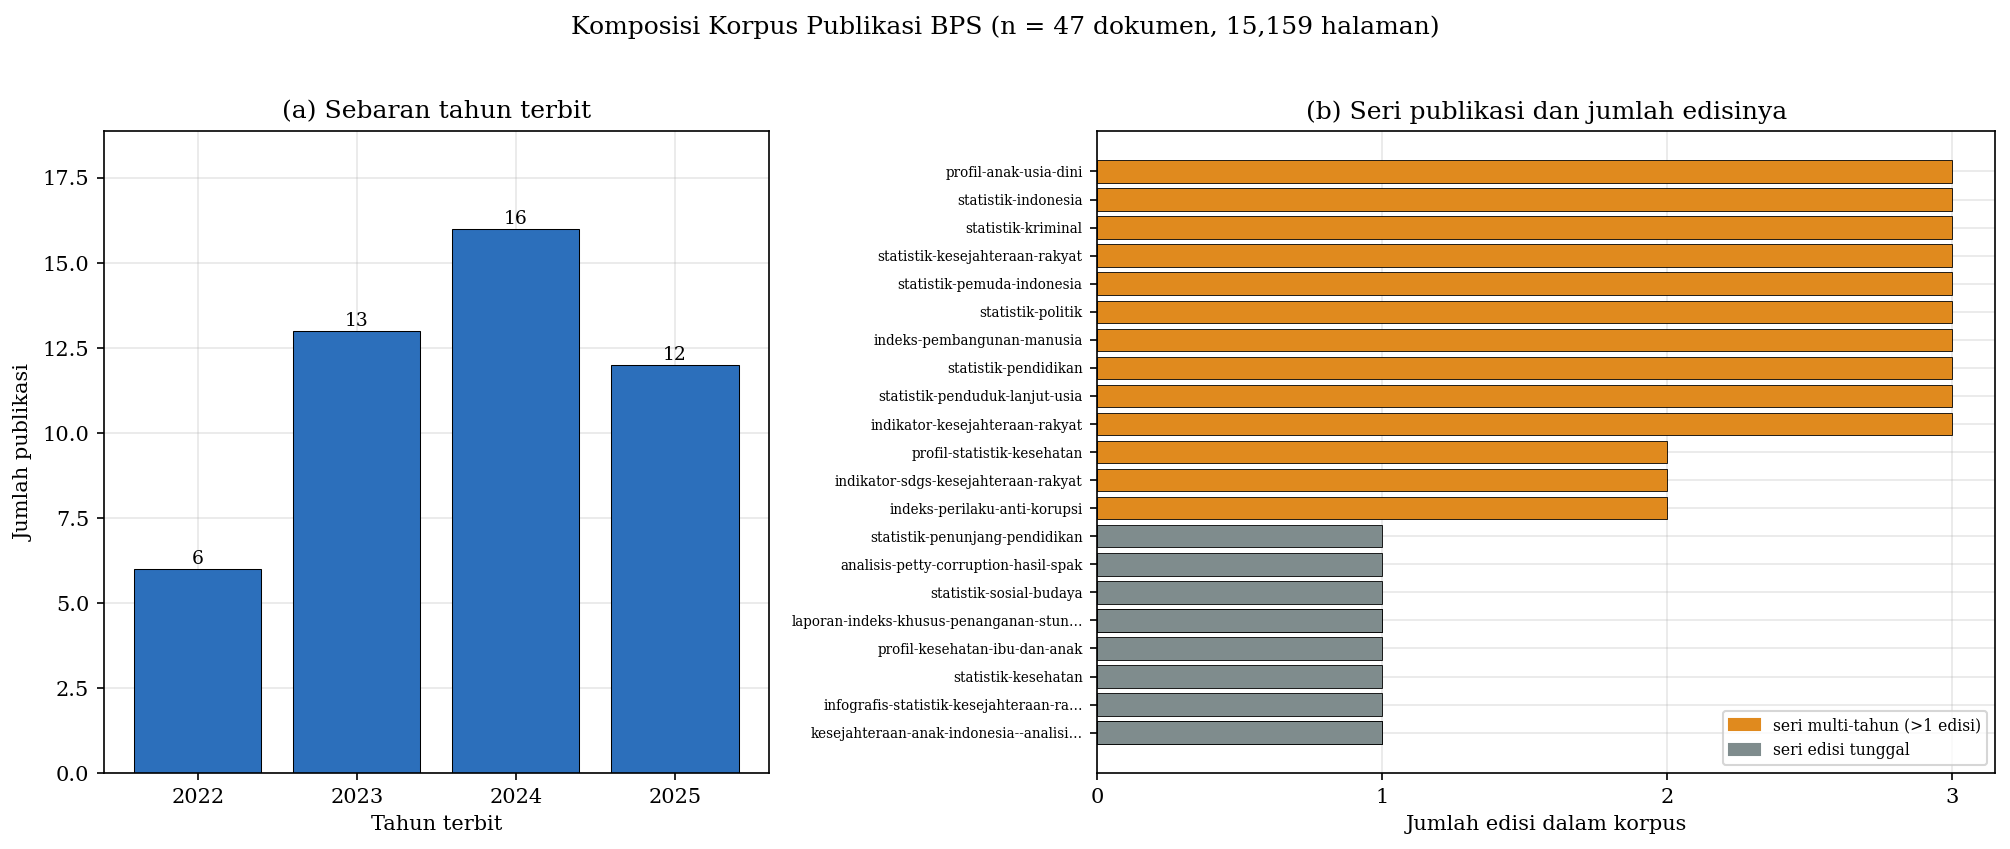

In [229]:
def fig01_komposisi_korpus():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5),
                             gridspec_kw={"width_ratios": [1, 1.35]})

    per_tahun = df_clean["tahun"].value_counts().sort_index()
    axes[0].bar(per_tahun.index.astype(int).astype(str), per_tahun.values,
                color=C_CLEAN, edgecolor="black", linewidth=.5)
    for i, v in enumerate(per_tahun.values):
        axes[0].text(i, v + .15, str(v), ha="center", fontsize=9)
    axes[0].set_xlabel("Tahun terbit"); axes[0].set_ylabel("Jumlah publikasi")
    axes[0].set_title("(a) Sebaran tahun terbit")
    axes[0].set_ylim(0, per_tahun.max() * 1.18)

    per_seri = df_clean["seri"].value_counts().sort_values()
    warna = [C_ACCENT if v > 1 else C_MUTED for v in per_seri.values]
    axes[1].barh([label_pendek(s, 38) for s in per_seri.index], per_seri.values,
                 color=warna, edgecolor="black", linewidth=.4)
    axes[1].set_xlabel("Jumlah edisi dalam korpus")
    axes[1].set_title("(b) Seri publikasi dan jumlah edisinya")
    axes[1].tick_params(axis="y", labelsize=6.5)
    axes[1].set_xticks(range(0, int(per_seri.max()) + 1))
    axes[1].legend(handles=[Patch(color=C_ACCENT, label="seri multi-tahun (>1 edisi)"),
                            Patch(color=C_MUTED, label="seri edisi tunggal")],
                   fontsize=7.5, loc="lower right")

    fig.suptitle(f"Komposisi Korpus Publikasi BPS (n = {len(df_clean)} dokumen, "
                 f"{df_clean['halaman'].sum():,} halaman)", y=1.02)
    plt.tight_layout(); plt.savefig("fig01_komposisi_korpus.png", bbox_inches="tight"); plt.show()

fig01_komposisi_korpus()

### Gambar 2 — Ukuran tiap dokumen: jumlah halaman

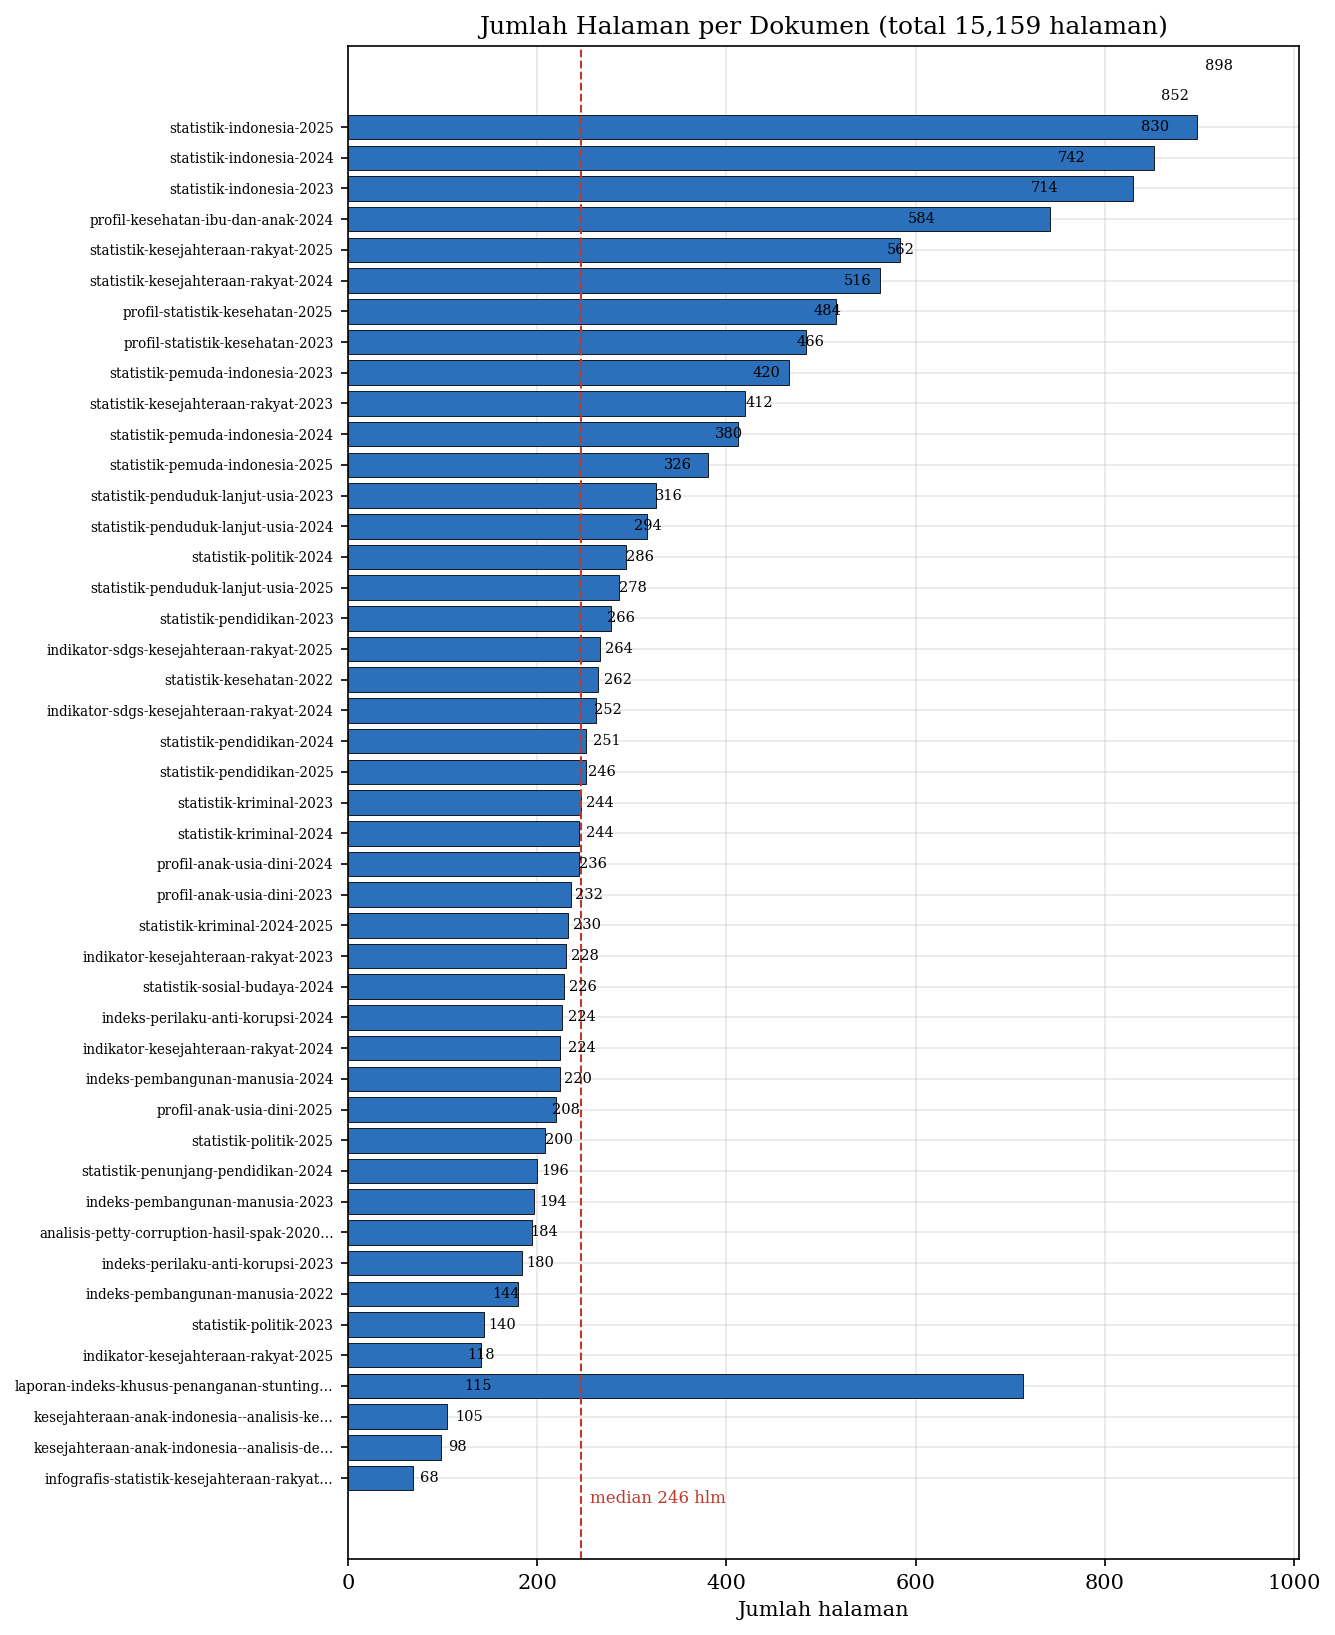

In [230]:
def fig02_halaman_per_dokumen():
    d = df_clean.sort_values("halaman")
    fig, ax = plt.subplots(figsize=(9, 11))
    ax.barh([label_pendek(n) for n in d["nama_file"]], d["halaman"],
            color=C_CLEAN, edgecolor="black", linewidth=.4)
    for y, v in enumerate(d["halaman"]):
        ax.text(v + 8, y, f"{v:,}", va="center", fontsize=7)
    ax.axvline(d["halaman"].median(), ls="--", color=C_DROP, lw=1)
    ax.text(d["halaman"].median() + 10, -0.8, f"median {d['halaman'].median():.0f} hlm",
            color=C_DROP, fontsize=8)
    ax.set_xlabel("Jumlah halaman"); ax.tick_params(axis="y", labelsize=6.5)
    ax.set_xlim(0, d["halaman"].max() * 1.12)
    ax.set_title(f"Jumlah Halaman per Dokumen (total {df_clean['halaman'].sum():,} halaman)")
    plt.tight_layout(); plt.savefig("fig02_halaman_per_dokumen.png", bbox_inches="tight"); plt.show()

fig02_halaman_per_dokumen()

### Gambar 3 — Volume teks sebelum dan sesudah pembersihan

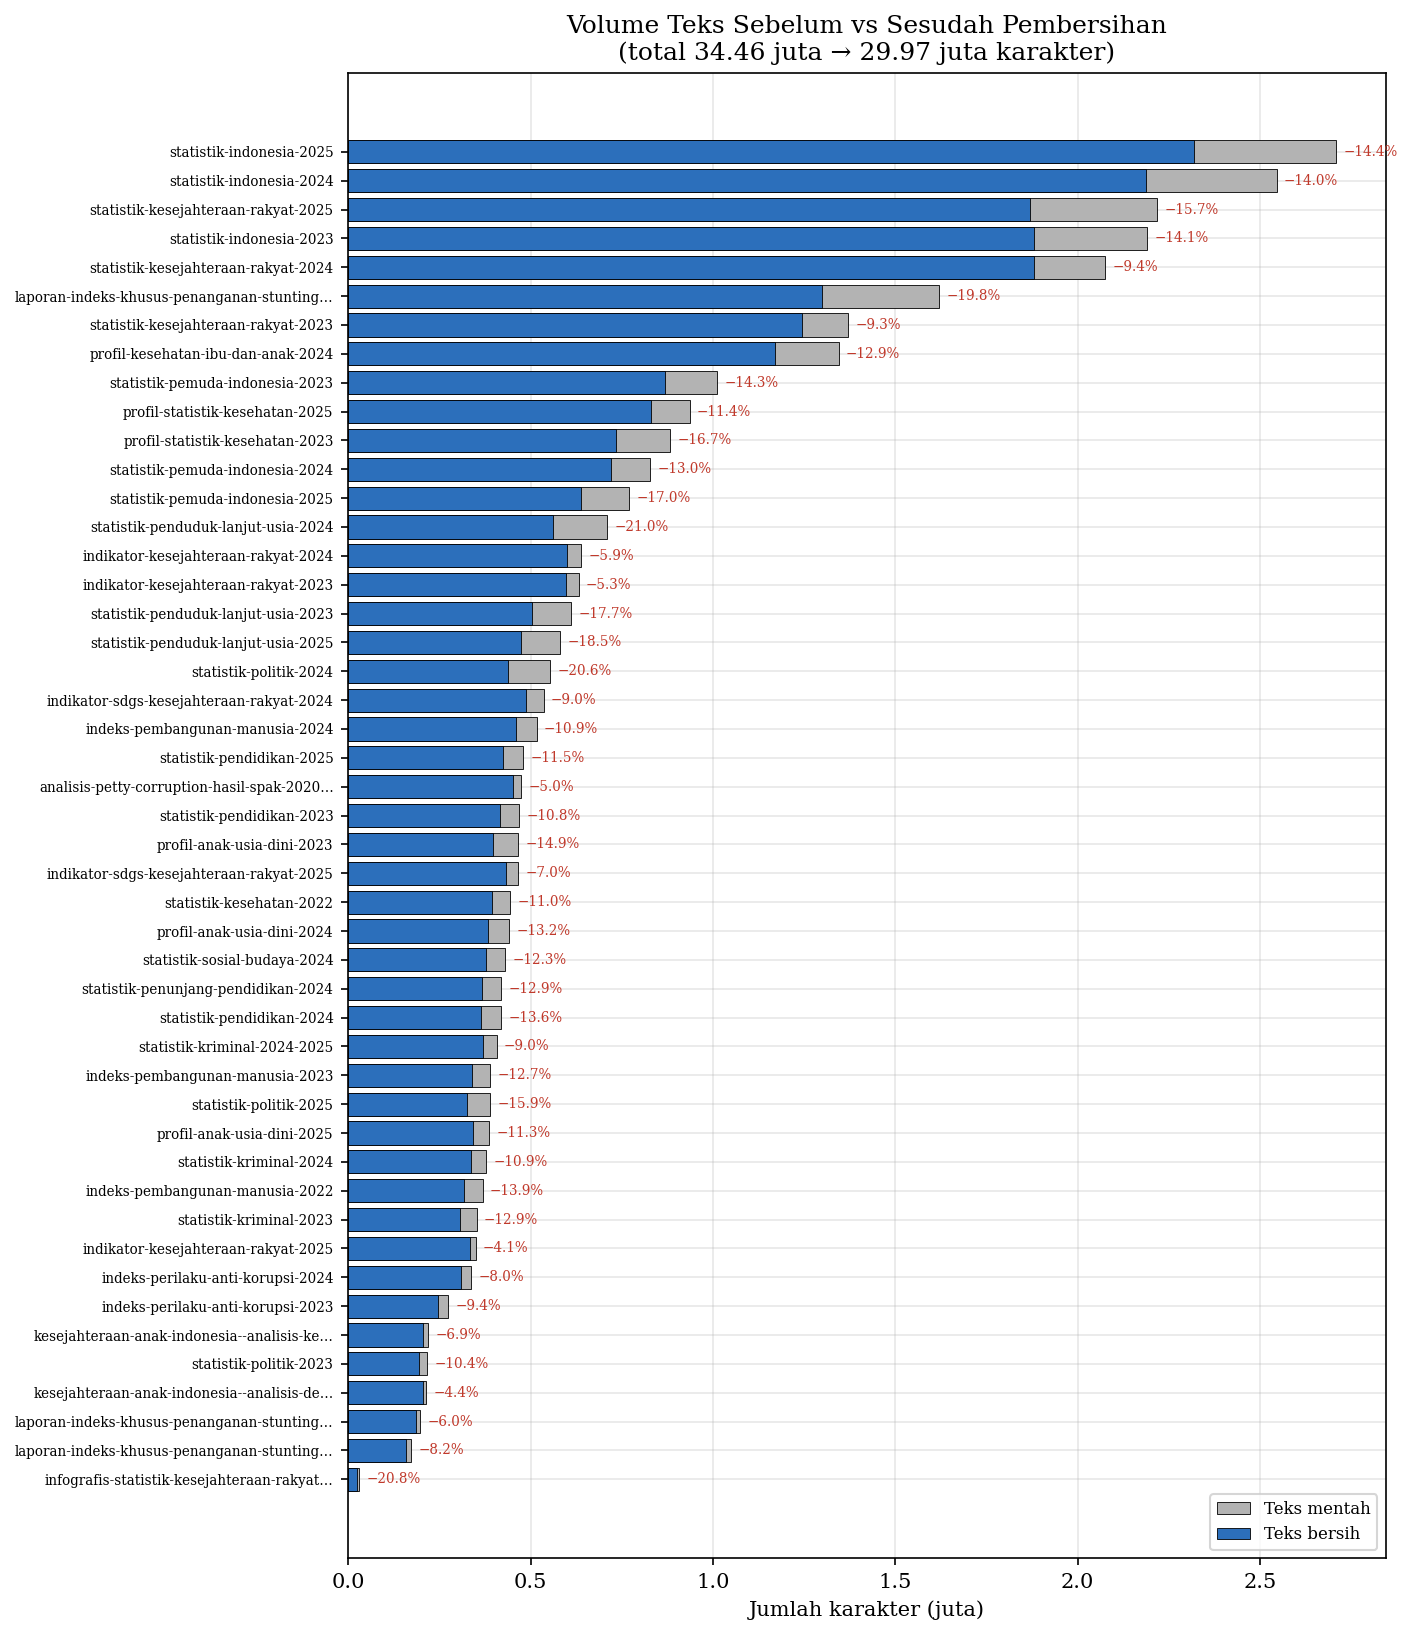

In [231]:
def fig03_volume_teks():
    d = df_clean.sort_values("chars_raw")
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(9.5, 11))
    ax.barh(y, d["chars_raw"] / 1e6, color=C_RAW, edgecolor="black", linewidth=.4, label="Teks mentah")
    ax.barh(y, d["chars_clean"] / 1e6, color=C_CLEAN, edgecolor="black", linewidth=.4, label="Teks bersih")
    ax.set_yticks(y); ax.set_yticklabels([label_pendek(n) for n in d["nama_file"]], fontsize=6.5)
    for yi, (raw, clean) in enumerate(zip(d["chars_raw"], d["chars_clean"])):
        ax.text(raw / 1e6 + .02, yi, f"−{100 * (raw - clean) / raw:.1f}%", va="center", fontsize=6.5, color=C_DROP)
    ax.set_xlabel("Jumlah karakter (juta)")
    ax.set_title(f"Volume Teks Sebelum vs Sesudah Pembersihan\n"
                 f"(total {df_clean['chars_raw'].sum() / 1e6:.2f} juta → "
                 f"{df_clean['chars_clean'].sum() / 1e6:.2f} juta karakter)")
    ax.legend(fontsize=8, loc="lower right")
    plt.tight_layout(); plt.savefig("fig03_volume_teks.png", bbox_inches="tight"); plt.show()

fig03_volume_teks()

### Gambar 4 — Tingkat reduksi pembersihan per dokumen

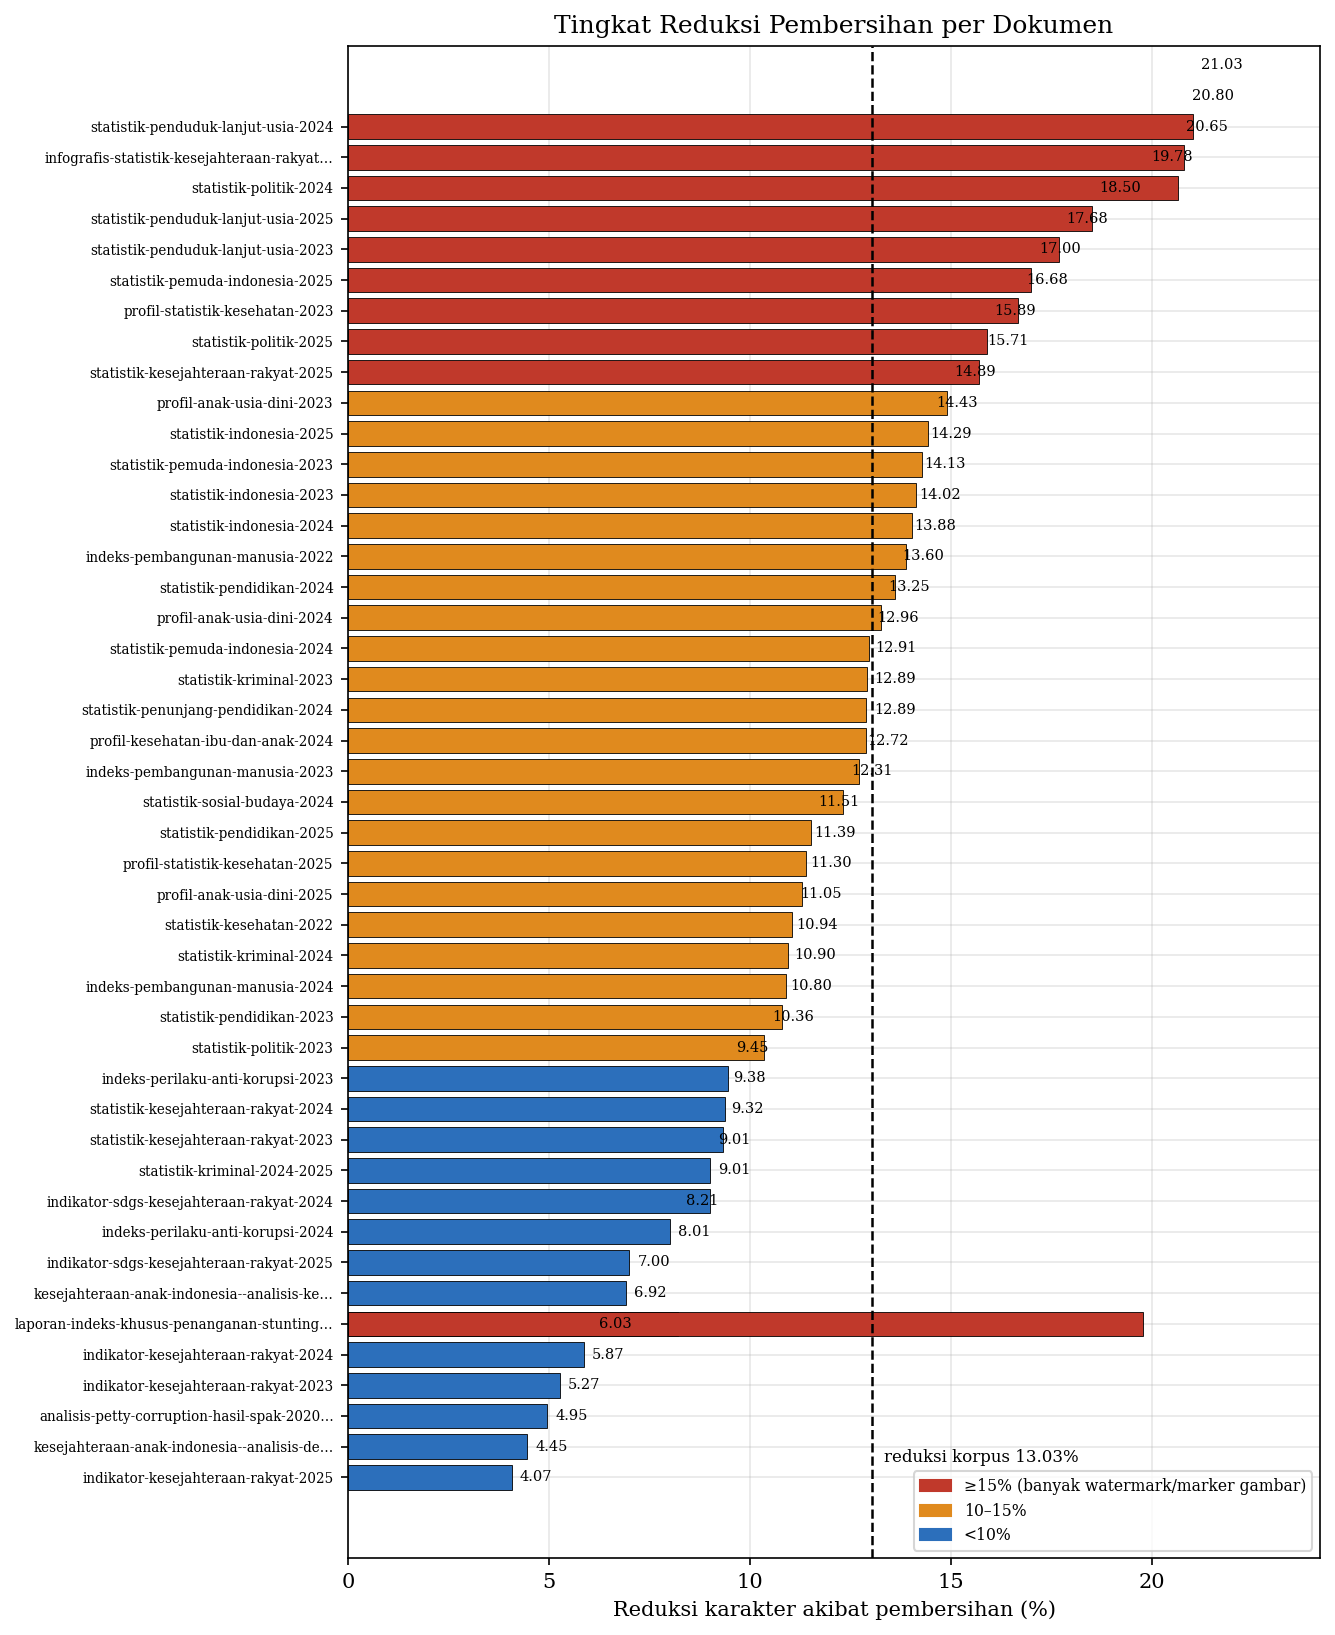

In [232]:
def fig04_reduksi_cleaning():
    d = df_clean.sort_values("reduction_pct")
    reduksi_korpus = 100 * df_clean["chars_removed"].sum() / df_clean["chars_raw"].sum()
    warna = [C_DROP if v >= 15 else (C_ACCENT if v >= 10 else C_CLEAN) for v in d["reduction_pct"]]
    fig, ax = plt.subplots(figsize=(9, 11))
    ax.barh([label_pendek(n) for n in d["nama_file"]], d["reduction_pct"],
            color=warna, edgecolor="black", linewidth=.4)
    for y, v in enumerate(d["reduction_pct"]):
        ax.text(v + .2, y, f"{v:.2f}", va="center", fontsize=7)
    ax.axvline(reduksi_korpus, ls="--", color="black", lw=1.2)
    ax.text(reduksi_korpus + .3, 0.5, f"reduksi korpus {reduksi_korpus:.2f}%", fontsize=8)
    ax.set_xlabel("Reduksi karakter akibat pembersihan (%)")
    ax.tick_params(axis="y", labelsize=6.5); ax.set_xlim(0, d["reduction_pct"].max() * 1.15)
    ax.set_title("Tingkat Reduksi Pembersihan per Dokumen")
    ax.legend(handles=[Patch(color=C_DROP, label="≥15% (banyak watermark/marker gambar)"),
                       Patch(color=C_ACCENT, label="10–15%"),
                       Patch(color=C_CLEAN, label="<10%")], fontsize=7.5, loc="lower right")
    plt.tight_layout(); plt.savefig("fig04_reduksi_cleaning.png", bbox_inches="tight"); plt.show()

fig04_reduksi_cleaning()

### Gambar 5 — Kepadatan teks: hubungan jumlah halaman dan volume karakter

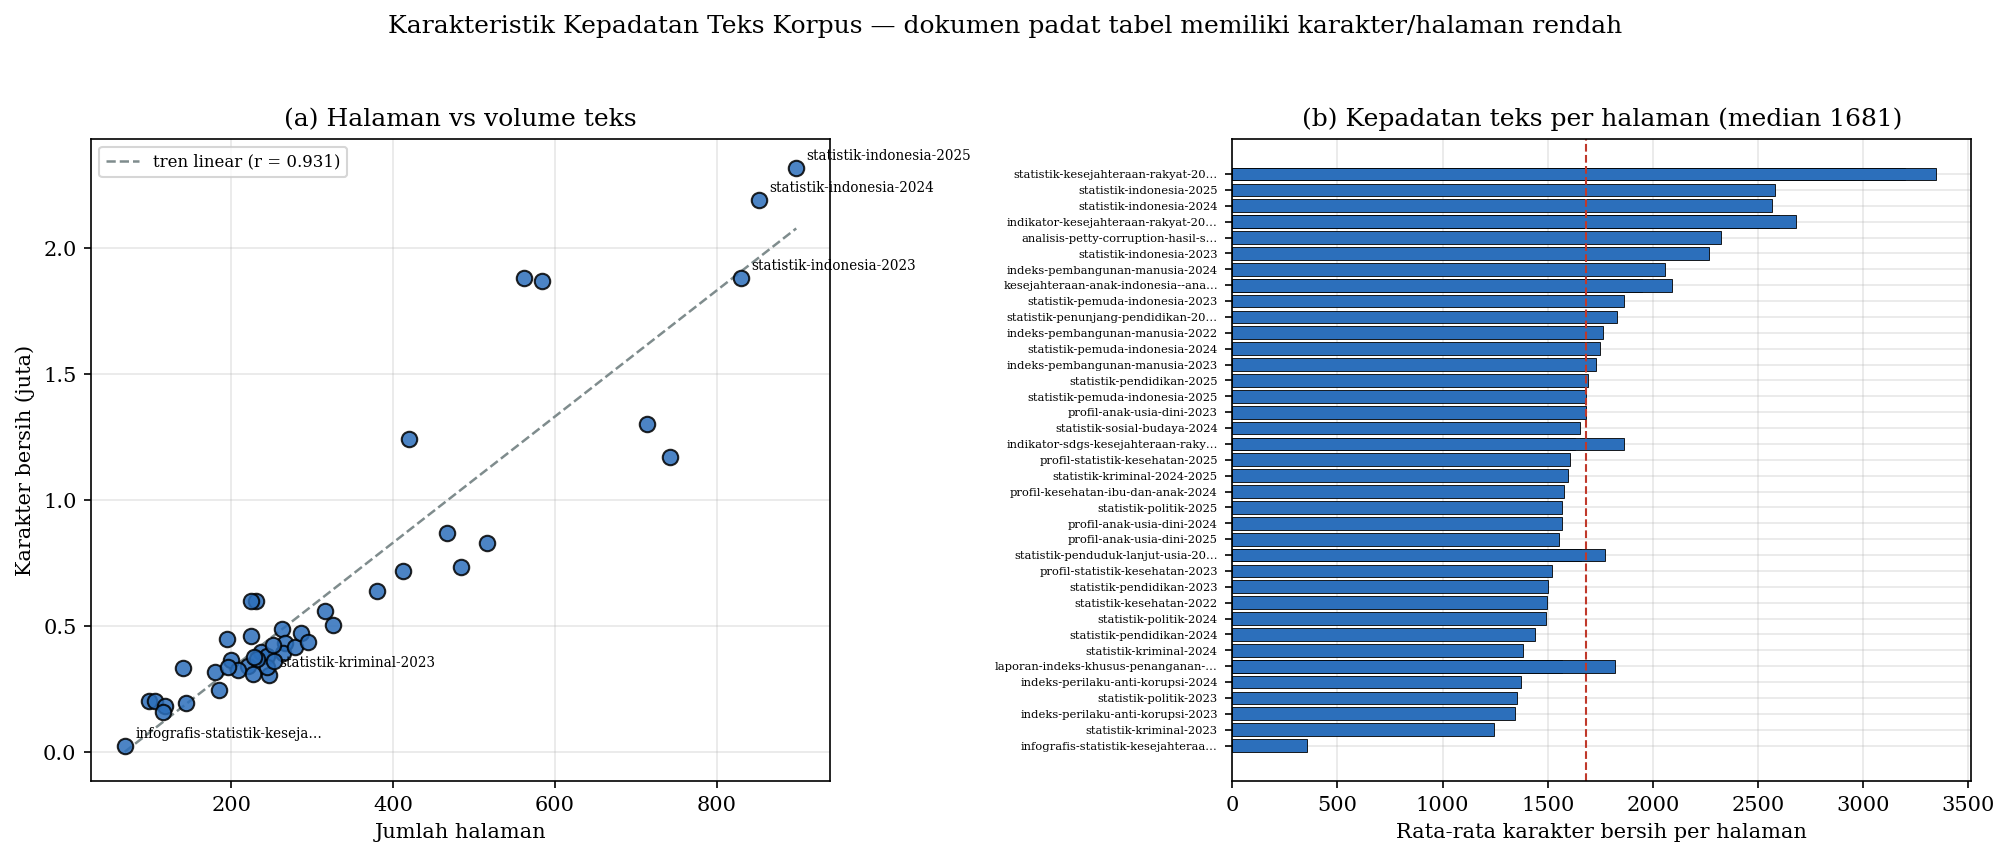

In [233]:
def fig05_kepadatan_teks():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

    ax = axes[0]
    ax.scatter(df_clean["halaman"], df_clean["chars_clean"] / 1e6, s=55,
               color=C_CLEAN, edgecolor="black", zorder=3, alpha=.85)
    koef = np.polyfit(df_clean["halaman"], df_clean["chars_clean"] / 1e6, 1)
    xg = np.linspace(df_clean["halaman"].min(), df_clean["halaman"].max(), 100)
    r = np.corrcoef(df_clean["halaman"], df_clean["chars_clean"])[0, 1]
    ax.plot(xg, np.polyval(koef, xg), ls="--", color=C_MUTED, lw=1.2, label=f"tren linear (r = {r:.3f})")
    ekstrem = pd.concat([df_clean.nlargest(3, "halaman"), df_clean.nsmallest(2, "chars_per_page")])
    for _, row in ekstrem.drop_duplicates("nama_file").iterrows():
        ax.annotate(label_pendek(row["nama_file"], 28), (row["halaman"], row["chars_clean"] / 1e6),
                    fontsize=6.5, xytext=(5, 4), textcoords="offset points")
    ax.set_xlabel("Jumlah halaman"); ax.set_ylabel("Karakter bersih (juta)")
    ax.set_title("(a) Halaman vs volume teks"); ax.legend(fontsize=8)

    ax = axes[1]
    d = df_clean.sort_values("chars_per_page")
    ax.barh([label_pendek(n, 34) for n in d["nama_file"]], d["chars_per_page"],
            color=C_CLEAN, edgecolor="black", linewidth=.4)
    ax.axvline(d["chars_per_page"].median(), ls="--", color=C_DROP, lw=1)
    ax.set_xlabel("Rata-rata karakter bersih per halaman")
    ax.tick_params(axis="y", labelsize=5.5)
    ax.set_title(f"(b) Kepadatan teks per halaman (median {d['chars_per_page'].median():.0f})")

    fig.suptitle("Karakteristik Kepadatan Teks Korpus — dokumen padat tabel memiliki karakter/halaman rendah", y=1.03)
    plt.tight_layout(); plt.savefig("fig05_kepadatan_teks.png", bbox_inches="tight"); plt.show()

fig05_kepadatan_teks()

### Gambar 6 — Elemen non-substantif yang dihapus: marker gambar dan watermark

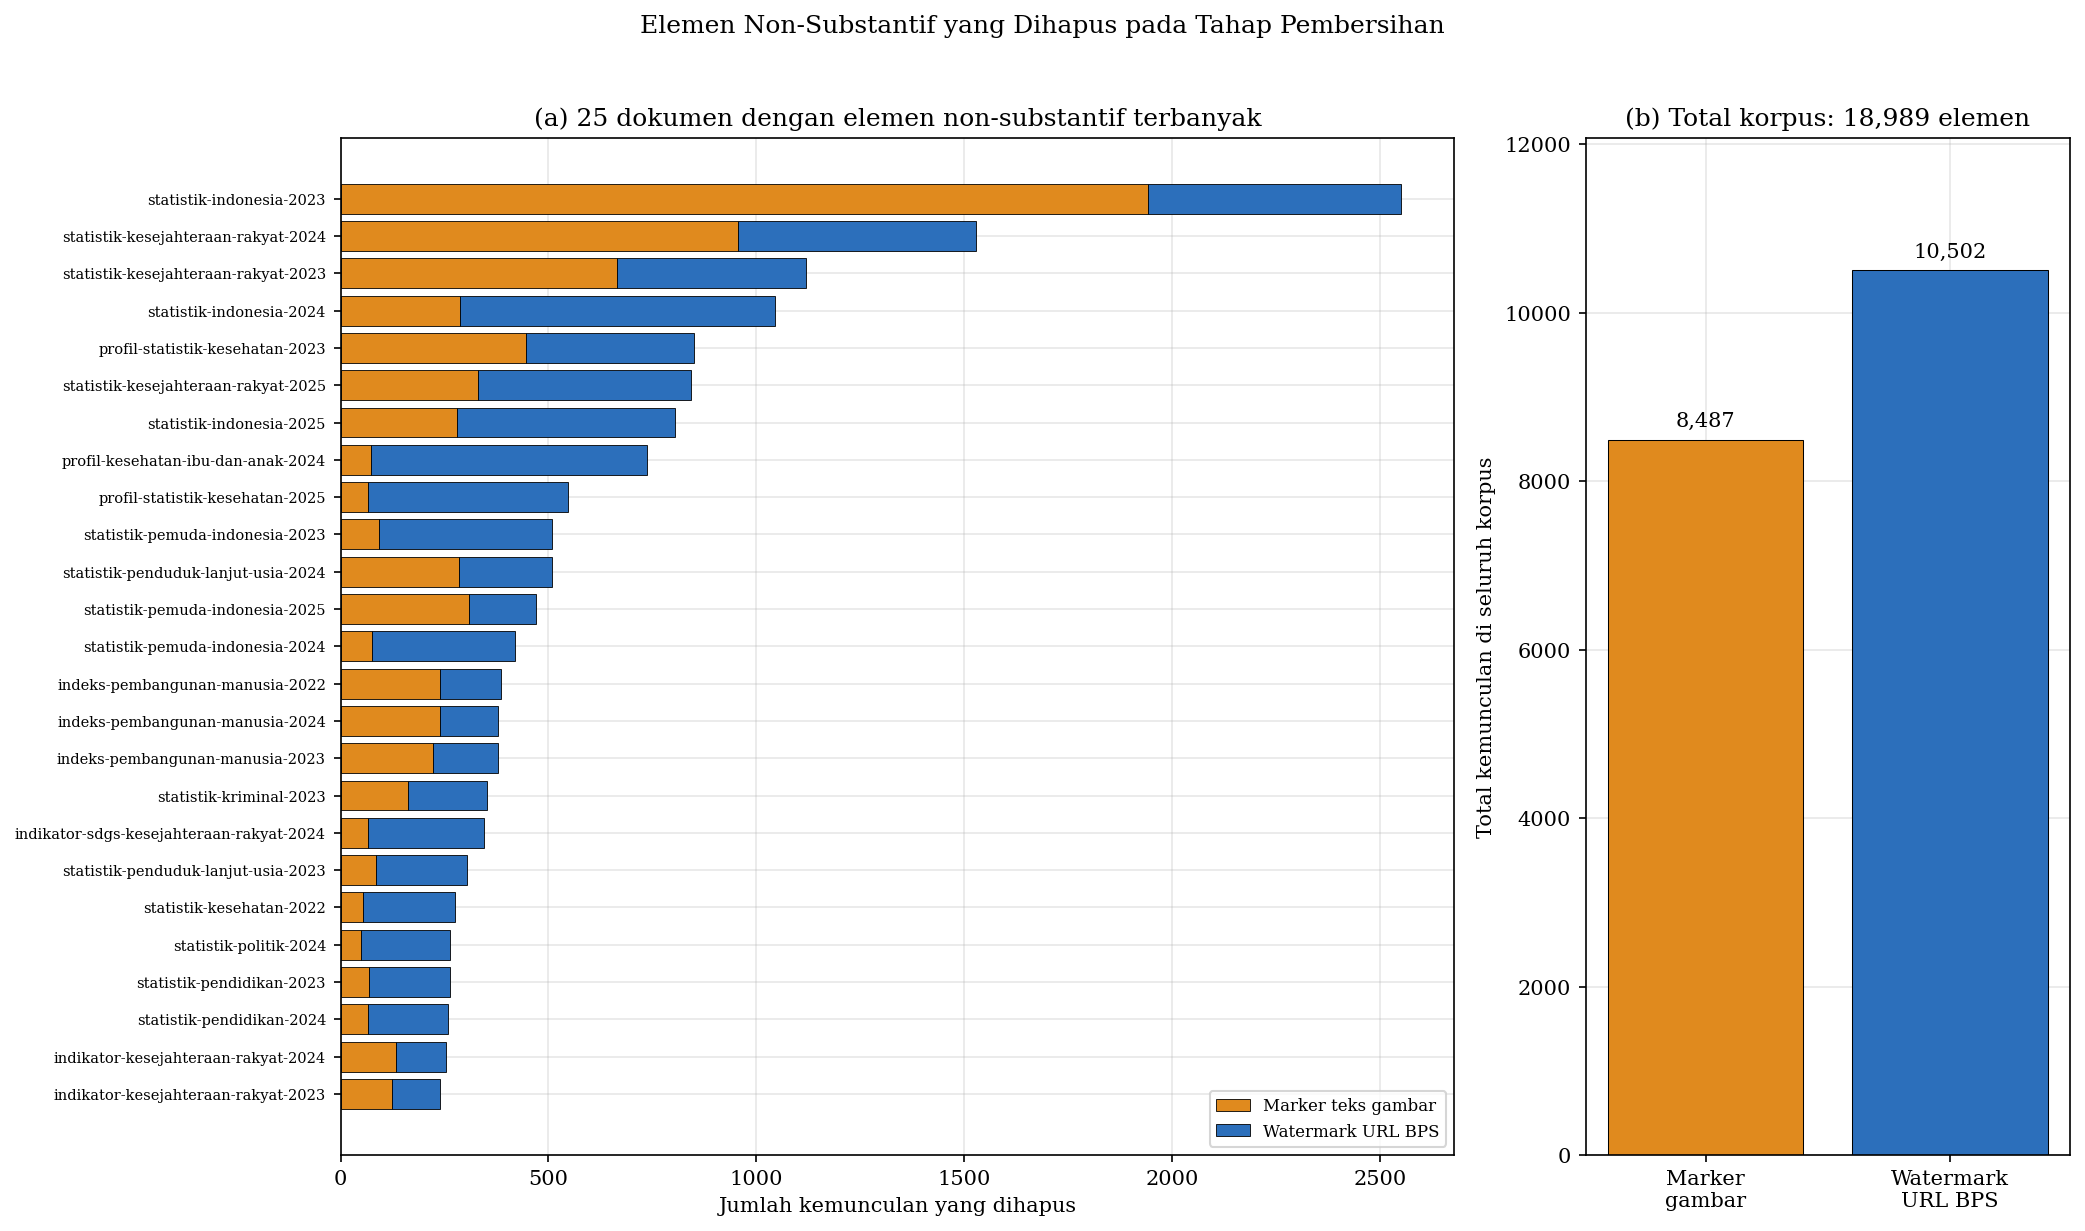

In [234]:
def fig06_elemen_dihapus():
    d = df_clean.copy()
    d["total_dihapus"] = d["picture_removed"] + d["watermark_removed"]
    d = d.sort_values("total_dihapus").tail(25)
    y = np.arange(len(d))
    fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [2.3, 1]})

    ax = axes[0]
    ax.barh(y, d["picture_removed"], color=C_ACCENT, edgecolor="black", linewidth=.4, label="Marker teks gambar")
    ax.barh(y, d["watermark_removed"], left=d["picture_removed"], color=C_CLEAN,
            edgecolor="black", linewidth=.4, label="Watermark URL BPS")
    ax.set_yticks(y); ax.set_yticklabels([label_pendek(n, 40) for n in d["nama_file"]], fontsize=7)
    ax.set_xlabel("Jumlah kemunculan yang dihapus")
    ax.set_title("(a) 25 dokumen dengan elemen non-substantif terbanyak")
    ax.legend(fontsize=8, loc="lower right")

    ax = axes[1]
    total = [df_clean["picture_removed"].sum(), df_clean["watermark_removed"].sum()]
    ax.bar(["Marker\ngambar", "Watermark\nURL BPS"], total,
           color=[C_ACCENT, C_CLEAN], edgecolor="black", linewidth=.5)
    for i, v in enumerate(total):
        ax.text(i, v + max(total) * .015, f"{v:,}", ha="center", fontsize=10)
    ax.set_ylabel("Total kemunculan di seluruh korpus")
    ax.set_title(f"(b) Total korpus: {sum(total):,} elemen")
    ax.set_ylim(0, max(total) * 1.15)

    fig.suptitle("Elemen Non-Substantif yang Dihapus pada Tahap Pembersihan", y=1.02)
    plt.tight_layout(); plt.savefig("fig06_elemen_dihapus.png", bbox_inches="tight"); plt.show()

fig06_elemen_dihapus()

### Gambar 7 — Kualitas hasil ekstraksi: halaman kosong dan halaman berteks minim
Halaman kosong (0 karakter) dan halaman berteks minim (0 < karakter < 100) menandakan halaman yang didominasi gambar/tabel hasil pindaian sehingga OCR tidak menghasilkan teks yang memadai. Proporsinya menjadi indikator batas kualitas ekstraksi.

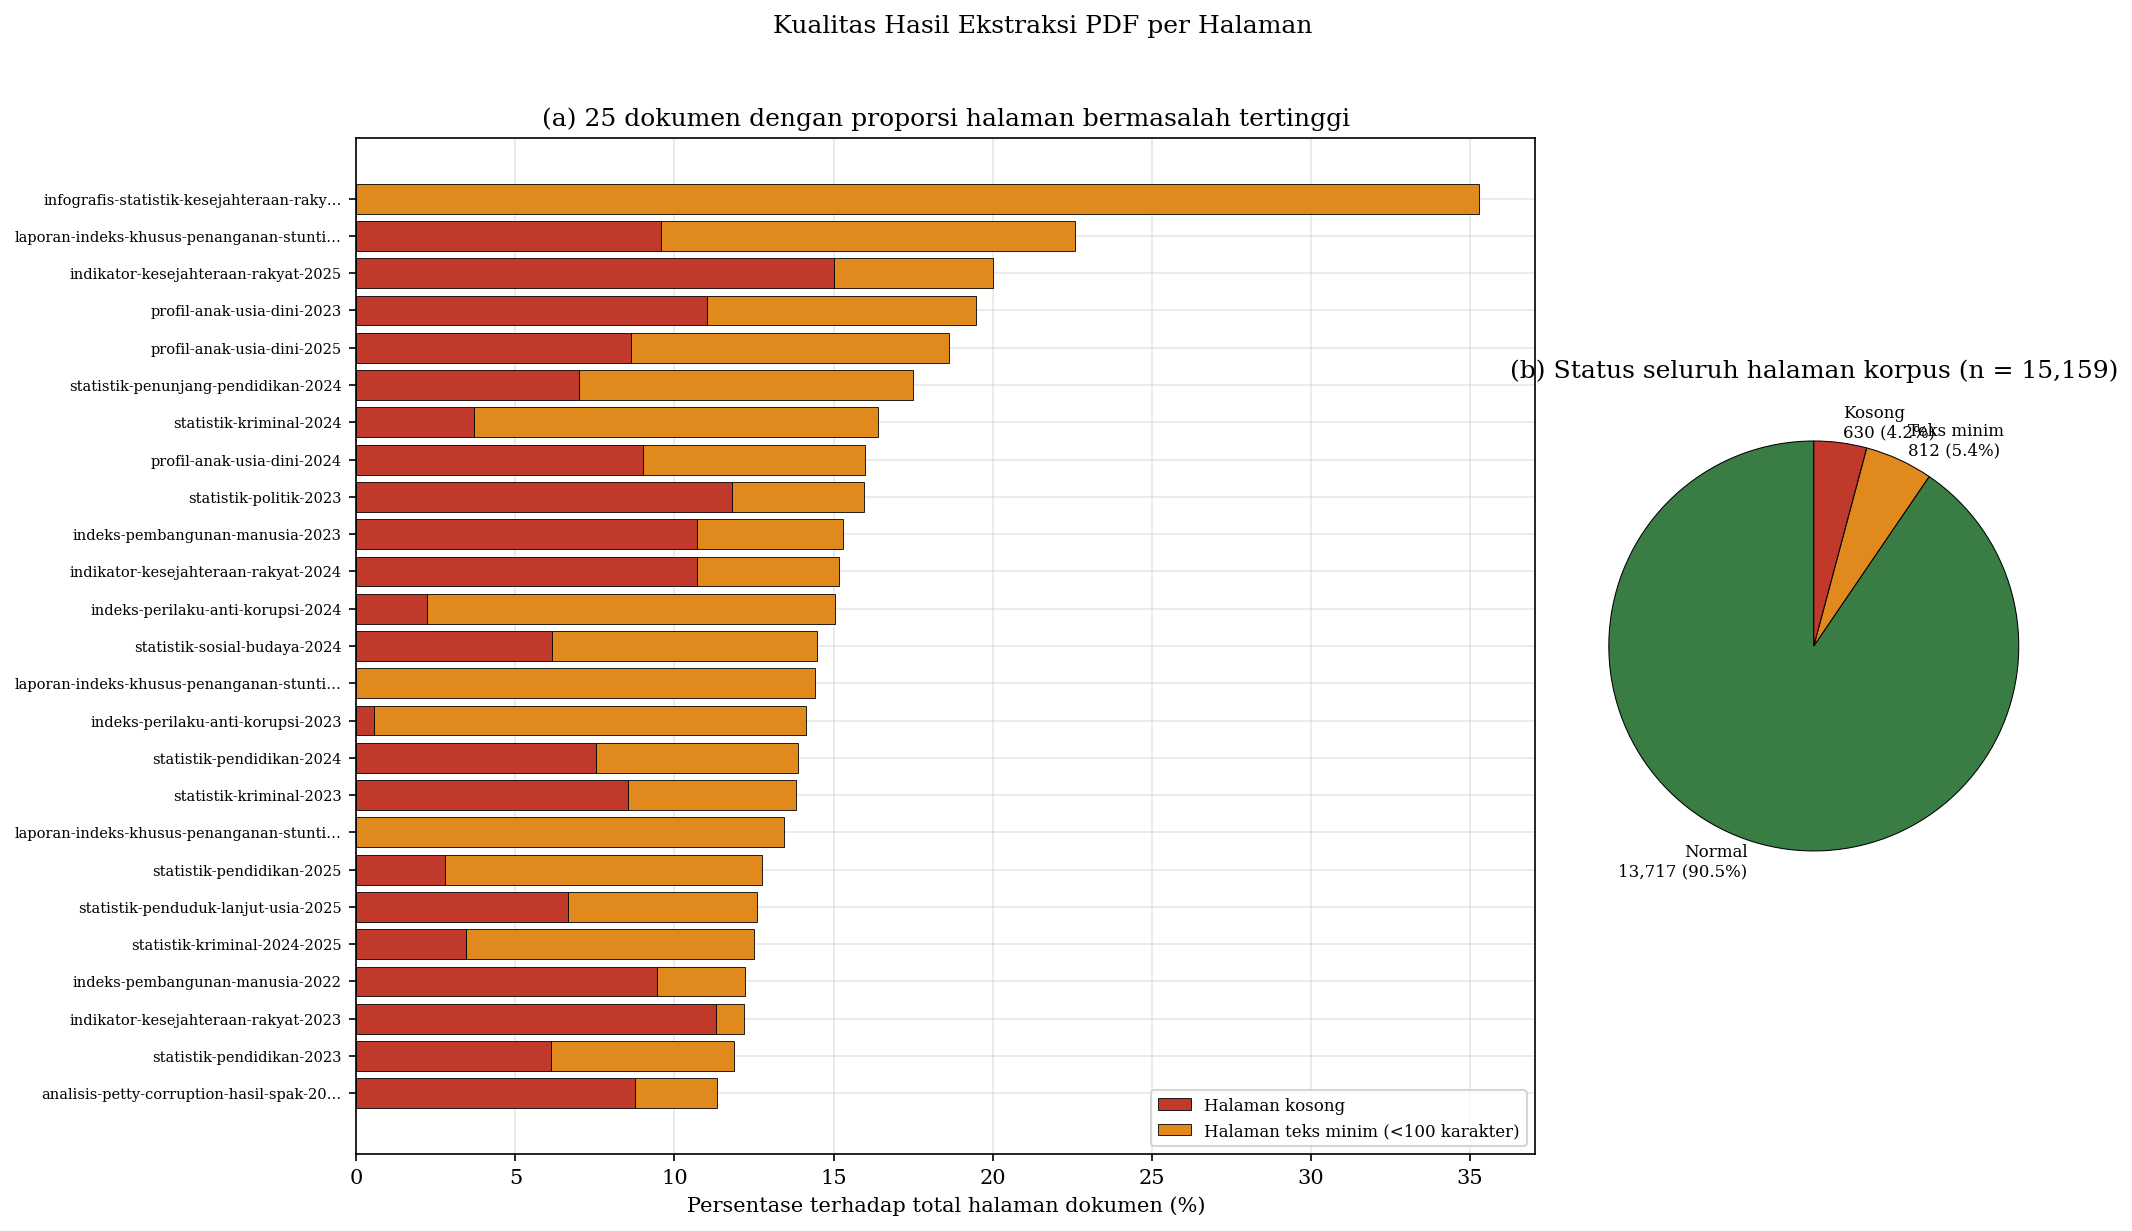

In [235]:
def fig07_kualitas_ekstraksi():
    d = df_clean.sort_values("problem_page_pct").tail(25)
    y = np.arange(len(d))
    fig, axes = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [2.3, 1]})

    ax = axes[0]
    ax.barh(y, 100 * d["empty_pages"] / d["halaman"], color=C_DROP,
            edgecolor="black", linewidth=.4, label="Halaman kosong")
    ax.barh(y, 100 * d["low_char_pages"] / d["halaman"], left=100 * d["empty_pages"] / d["halaman"],
            color=C_ACCENT, edgecolor="black", linewidth=.4, label="Halaman teks minim (<100 karakter)")
    ax.set_yticks(y); ax.set_yticklabels([label_pendek(n, 40) for n in d["nama_file"]], fontsize=7)
    ax.set_xlabel("Persentase terhadap total halaman dokumen (%)")
    ax.set_title("(a) 25 dokumen dengan proporsi halaman bermasalah tertinggi")
    ax.legend(fontsize=8, loc="lower right")

    ax = axes[1]
    total_hlm = df_clean["halaman"].sum()
    kosong, minim = df_clean["empty_pages"].sum(), df_clean["low_char_pages"].sum()
    normal = total_hlm - kosong - minim
    ax.pie([normal, minim, kosong],
           labels=[f"Normal\n{normal:,} ({100 * normal / total_hlm:.1f}%)",
                   f"Teks minim\n{minim:,} ({100 * minim / total_hlm:.1f}%)",
                   f"Kosong\n{kosong:,} ({100 * kosong / total_hlm:.1f}%)"],
           colors=[C_KEEP, C_ACCENT, C_DROP], startangle=90,
           wedgeprops={"edgecolor": "black", "linewidth": .5}, textprops={"fontsize": 8})
    ax.set_title(f"(b) Status seluruh halaman korpus (n = {total_hlm:,})")
    ax.grid(False)

    fig.suptitle("Kualitas Hasil Ekstraksi PDF per Halaman", y=1.02)
    plt.tight_layout(); plt.savefig("fig07_kualitas_ekstraksi.png", bbox_inches="tight"); plt.show()

fig07_kualitas_ekstraksi()

---
# Bagian 2 — Strukturisasi dan Chunking

Statistik section, chunk, jenis chunk, dan penyisihan dibaca dari `laporan_chunking_bab4.json`.


### Gambar 8 — Funnel penyusutan: dari section menjadi chunk siap-QA

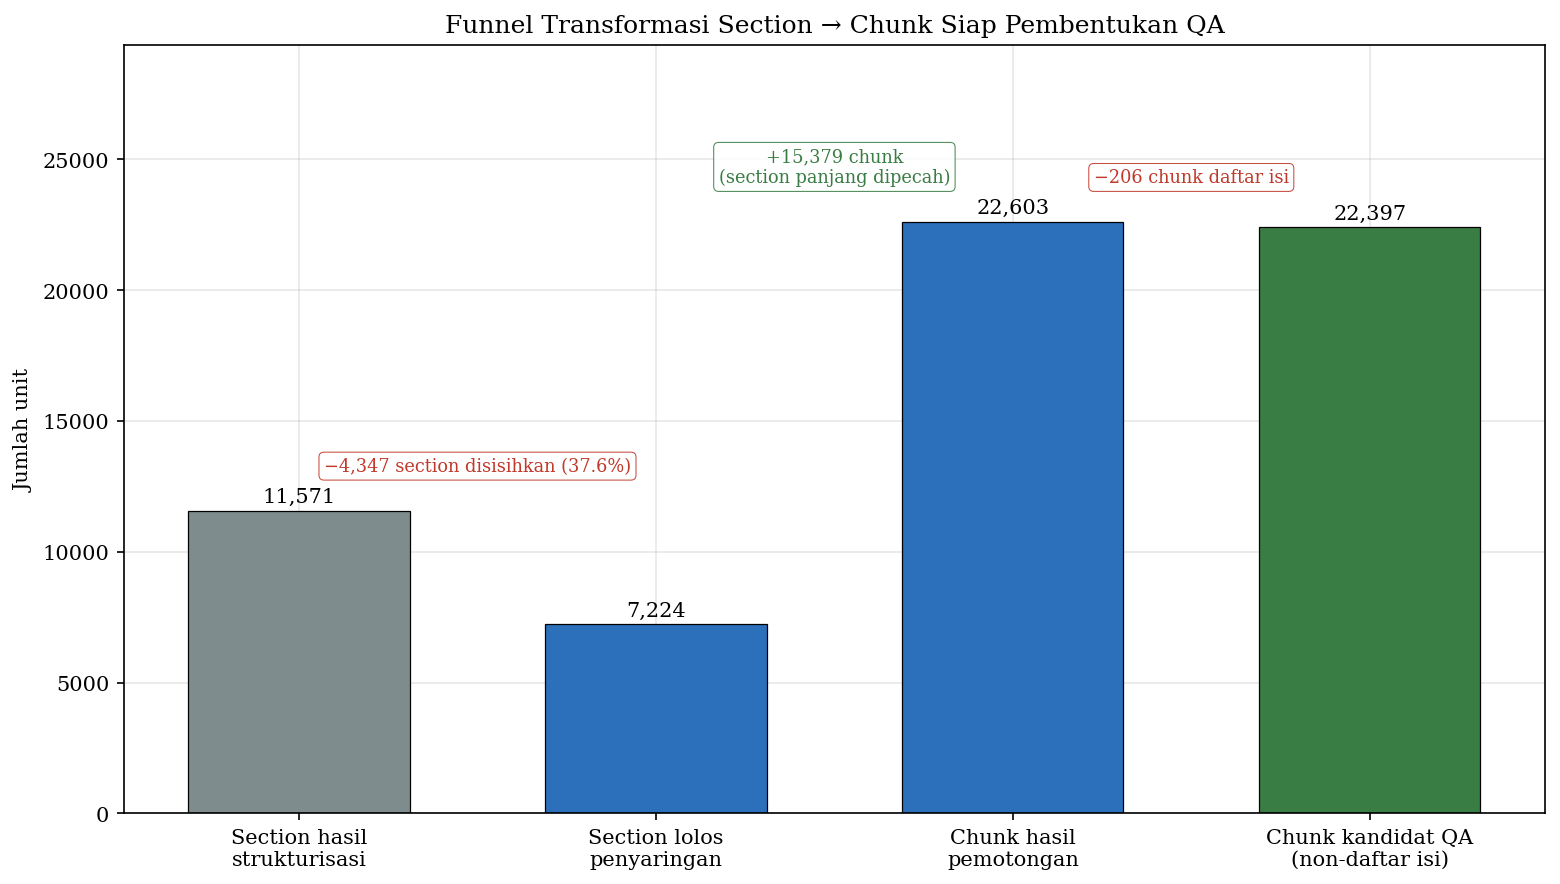

In [236]:
def fig08_funnel_chunking():
    total_section = int(df_chunk["n_sections"].sum())
    disisihkan = sum(EXCLUSION_DIST.values())
    chunk_qa = TOTAL_CHUNKS - CHUNK_TYPE_DIST["toc_table"] - CHUNK_TYPE_DIST["toc_figure"]

    tahap = ["Section hasil\nstrukturisasi", "Section lolos\npenyaringan",
             "Chunk hasil\npemotongan", "Chunk kandidat QA\n(non-daftar isi)"]
    nilai = [total_section, total_section - disisihkan, TOTAL_CHUNKS, chunk_qa]
    warna = [C_MUTED, C_CLEAN, C_CLEAN, C_KEEP]

    fig, ax = plt.subplots(figsize=(10.5, 6))
    bars = ax.bar(tahap, nilai, color=warna, edgecolor="black", linewidth=.6, width=.62)
    for b, v in zip(bars, nilai):
        ax.text(b.get_x() + b.get_width() / 2, v + max(nilai) * .015, f"{v:,}", ha="center", fontsize=10)

    anotasi_funnel(ax, nilai, [
        (f"−{disisihkan:,} section disisihkan ({100 * disisihkan / total_section:.1f}%)", C_DROP),
        (f"+{TOTAL_CHUNKS - nilai[1]:,} chunk\n(section panjang dipecah)", C_KEEP),
        (f"−{CHUNK_TYPE_DIST['toc_table'] + CHUNK_TYPE_DIST['toc_figure']:,} chunk daftar isi", C_DROP),
    ])

    ax.set_ylabel("Jumlah unit"); ax.set_ylim(0, max(nilai) * 1.3)
    ax.set_title("Funnel Transformasi Section → Chunk Siap Pembentukan QA")
    plt.tight_layout(); plt.savefig("fig08_funnel_chunking.png", bbox_inches="tight"); plt.show()

fig08_funnel_chunking()

### Gambar 9 — Alasan penyisihan section

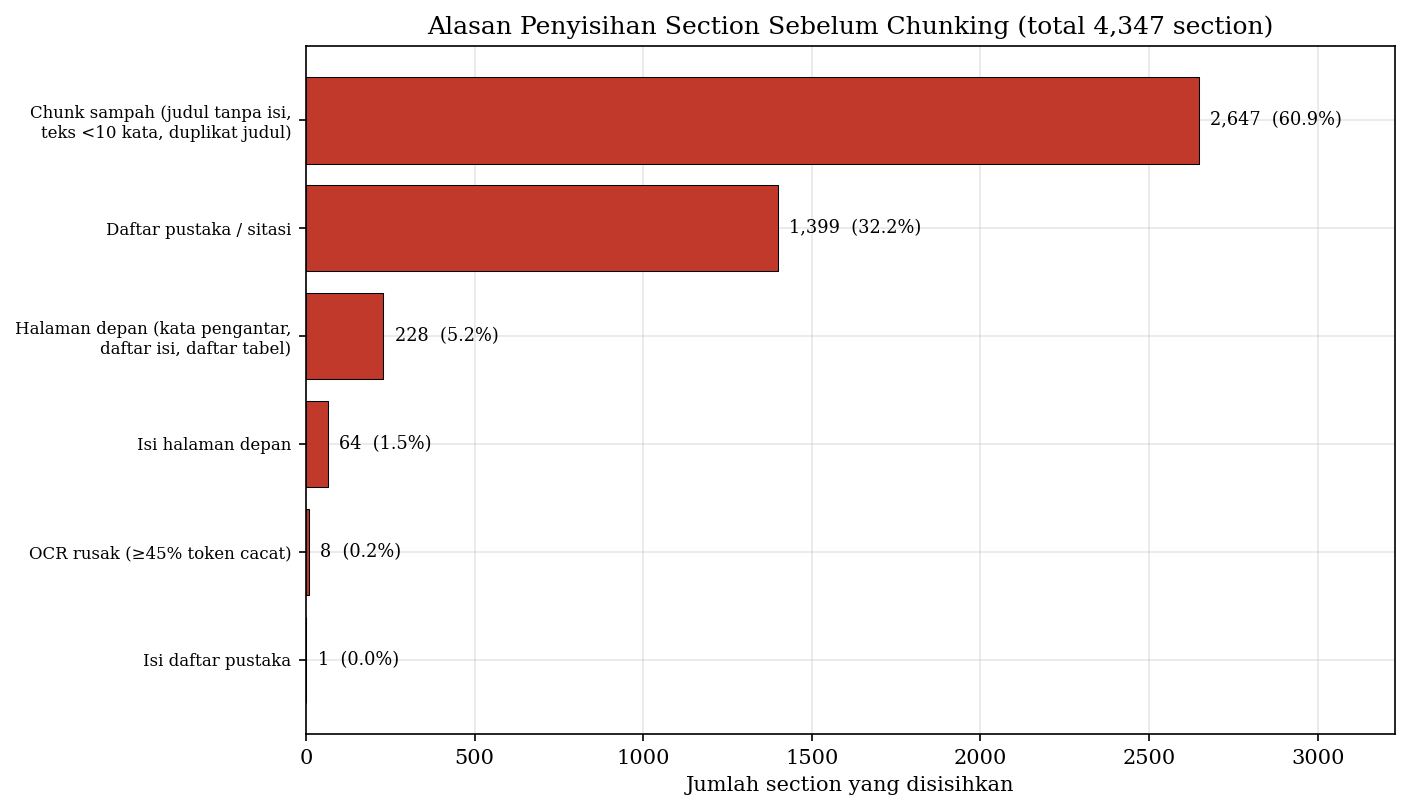

In [237]:
def fig09_alasan_penyisihan():
    ket = {
        "garbage_chunk": "Chunk sampah (judul tanpa isi,\nteks <10 kata, duplikat judul)",
        "reference": "Daftar pustaka / sitasi",
        "front_matter": "Halaman depan (kata pengantar,\ndaftar isi, daftar tabel)",
        "front_matter_content": "Isi halaman depan",
        "ocr_broken": "OCR rusak (≥45% token cacat)",
        "reference_content": "Isi daftar pustaka",
    }
    d = pd.Series(EXCLUSION_DIST).sort_values()
    total = d.sum()
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    ax.barh([ket[k] for k in d.index], d.values, color=C_DROP, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total * .008, y, f"{v:,}  ({100 * v / total:.1f}%)", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah section yang disisihkan")
    ax.set_xlim(0, d.max() * 1.22); ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"Alasan Penyisihan Section Sebelum Chunking (total {total:,} section)")
    plt.tight_layout(); plt.savefig("fig09_alasan_penyisihan.png", bbox_inches="tight"); plt.show()

fig09_alasan_penyisihan()

### Gambar 10 — Komposisi jenis chunk dan potensi tipe QA yang dihasilkan

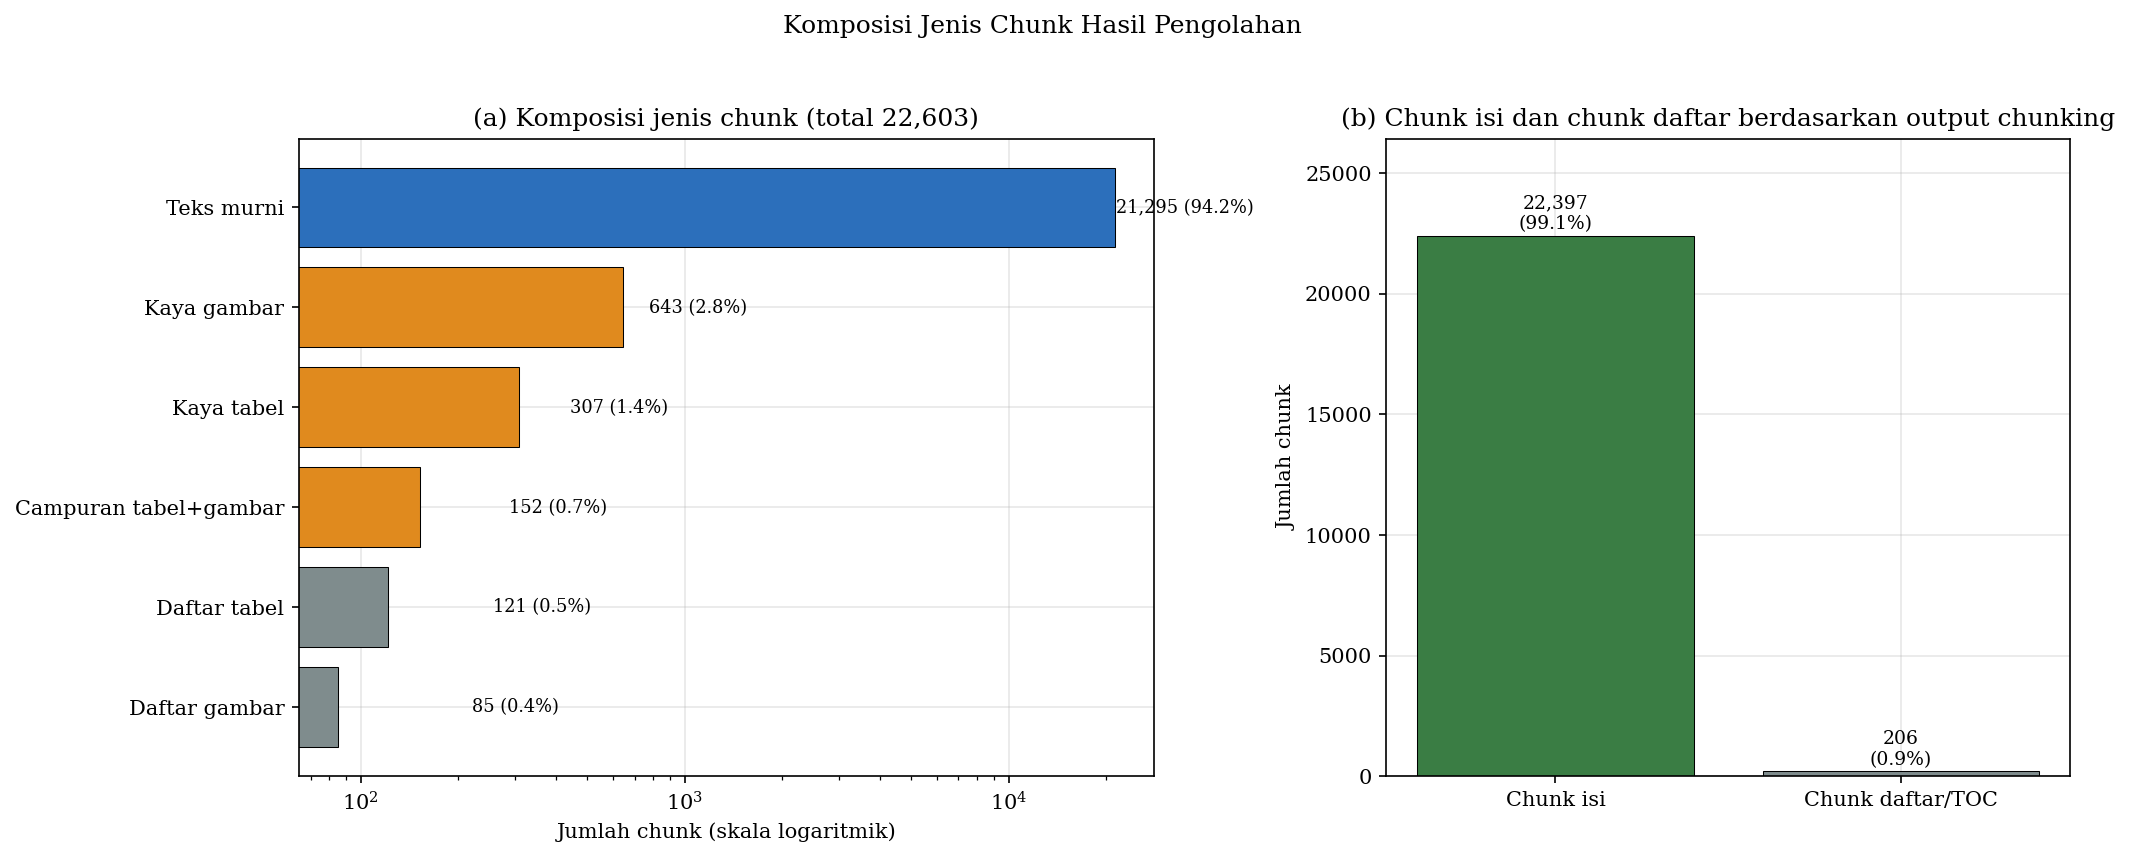

In [238]:
def fig10_jenis_chunk():
    ket = {"text_only": "Teks murni", "figure_rich": "Kaya gambar", "table_rich": "Kaya tabel",
           "mixed_rich": "Campuran tabel+gambar", "toc_table": "Daftar tabel", "toc_figure": "Daftar gambar"}
    d = pd.Series(CHUNK_TYPE_DIST).sort_values()
    total = d.sum()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.25, 1]})
    ax = axes[0]
    warna = [C_MUTED if k.startswith("toc") else (C_CLEAN if k == "text_only" else C_ACCENT) for k in d.index]
    ax.barh([ket.get(k, k) for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total * .006, y, f"{v:,} ({100 * v / total:.1f}%)", va="center", fontsize=8.5)
    ax.set_xscale("log"); ax.set_xlabel("Jumlah chunk (skala logaritmik)")
    ax.set_title(f"(a) Komposisi jenis chunk (total {total:,})")

    ax = axes[1]
    kelompok = pd.Series({"Chunk isi": sum(v for k, v in CHUNK_TYPE_DIST.items() if not k.startswith("toc")),
                          "Chunk daftar/TOC": sum(v for k, v in CHUNK_TYPE_DIST.items() if k.startswith("toc"))})
    ax.bar(kelompok.index, kelompok.values, color=[C_KEEP, C_MUTED], edgecolor="black", linewidth=.5)
    for x, v in enumerate(kelompok.values):
        ax.text(x, v + total * .012, f"{v:,}\n({100 * v / total:.1f}%)", ha="center", fontsize=9)
    ax.set_ylabel("Jumlah chunk"); ax.set_ylim(0, kelompok.max() * 1.18)
    ax.set_title("(b) Chunk isi dan chunk daftar berdasarkan output chunking")

    fig.suptitle("Komposisi Jenis Chunk Hasil Pengolahan", y=1.03)
    plt.tight_layout(); plt.savefig("fig10_jenis_chunk.png", bbox_inches="tight"); plt.show()

fig10_jenis_chunk()


### Gambar 11 — Rasio pemecahan: section terhadap chunk per dokumen

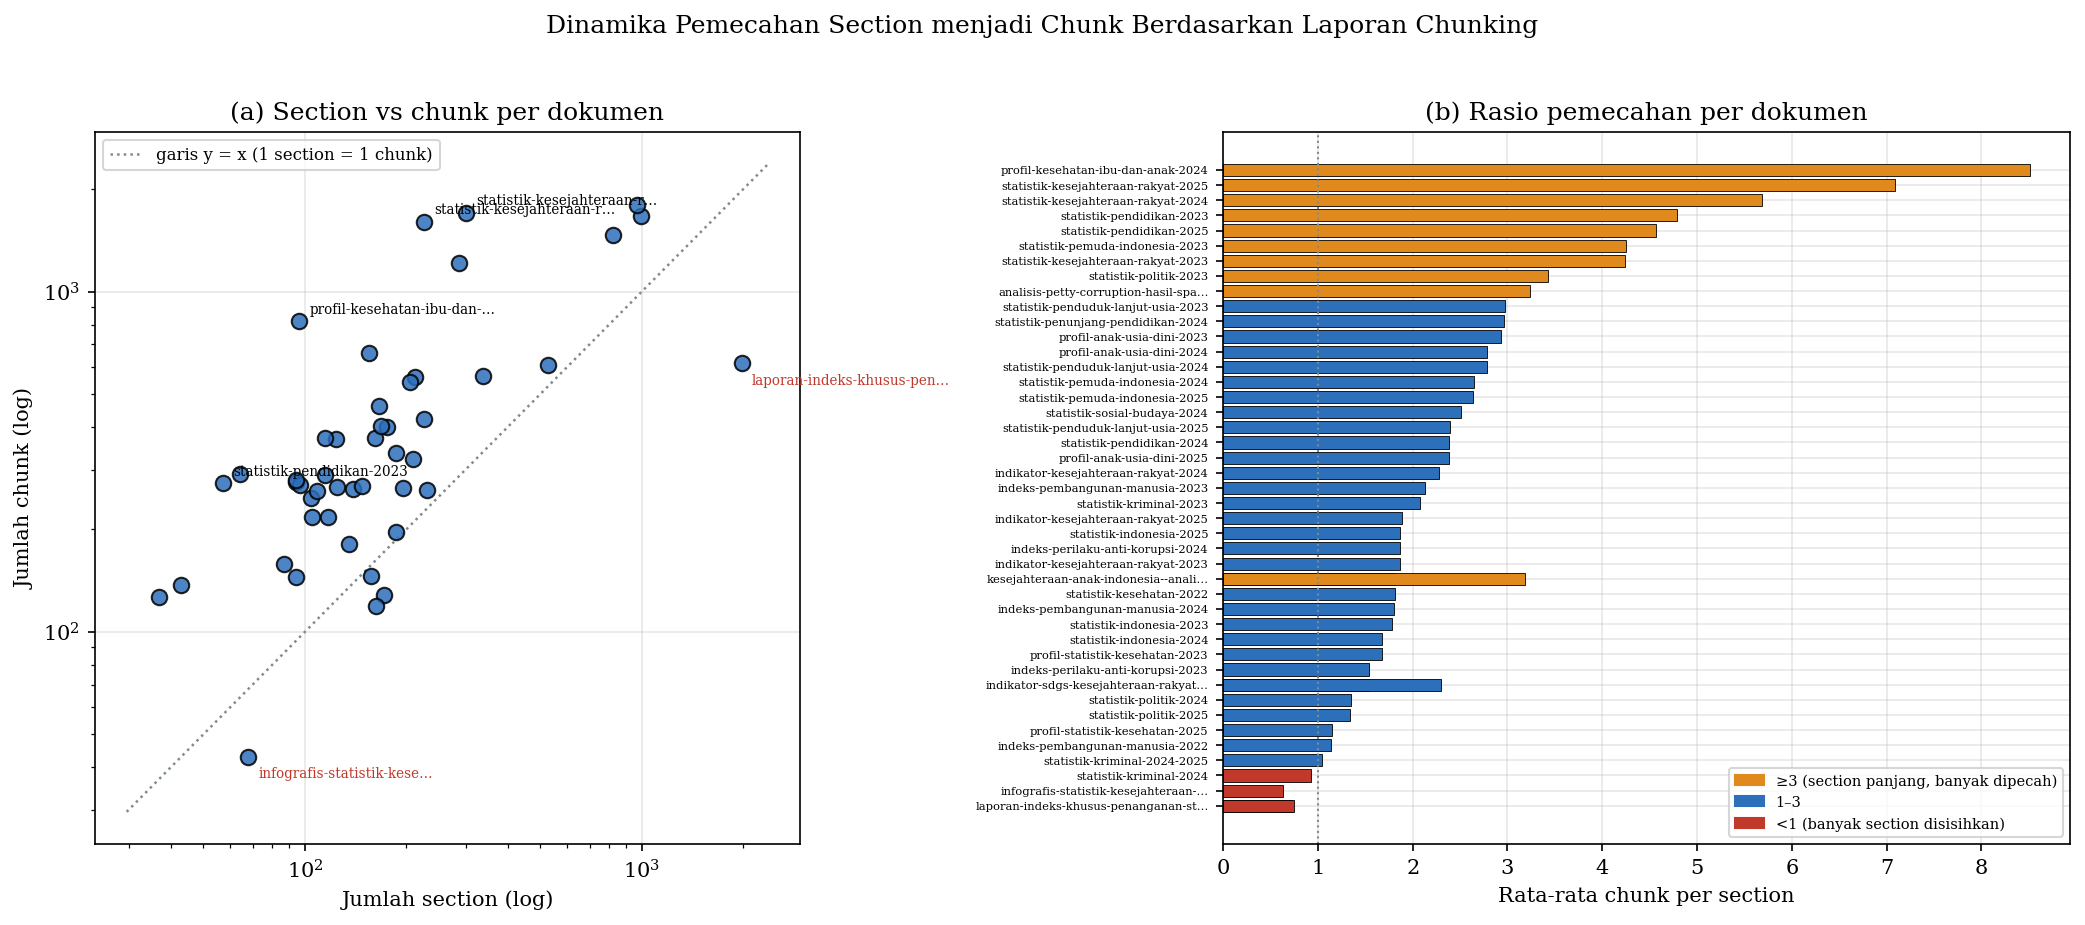

In [239]:
def fig11_rasio_section_chunk():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 1.2]})

    ax = axes[0]
    ax.scatter(df_korpus["n_sections"], df_korpus["n_chunks"], s=55,
               color=C_CLEAN, edgecolor="black", zorder=3, alpha=.85)
    batas_bawah = max(1, min(df_korpus['n_sections'].min(), df_korpus['n_chunks'].min()) * .8)
    batas_atas = max(df_korpus['n_sections'].max(), df_korpus['n_chunks'].max()) * 1.2
    lim = [batas_bawah, batas_atas]
    ax.plot(lim, lim, ls=":", color=C_MUTED, lw=1.2, label="garis y = x (1 section = 1 chunk)")
    for _, row in df_korpus.nlargest(4, "chunk_per_section").iterrows():
        ax.annotate(label_pendek(row["nama_file"], 26), (row["n_sections"], row["n_chunks"]),
                    fontsize=6.5, xytext=(5, 4), textcoords="offset points")
    ekstrem_rendah = df_korpus.nsmallest(2, "chunk_per_section")
    for _, row in ekstrem_rendah.iterrows():
        ax.annotate(label_pendek(row["nama_file"], 26), (row["n_sections"], row["n_chunks"]),
                    fontsize=6.5, xytext=(5, -10), textcoords="offset points", color=C_DROP)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Jumlah section (log)"); ax.set_ylabel("Jumlah chunk (log)")
    ax.set_title("(a) Section vs chunk per dokumen"); ax.legend(fontsize=8)

    ax = axes[1]
    d = df_korpus.sort_values("chunk_per_section")
    warna = [C_ACCENT if v >= 3 else (C_CLEAN if v >= 1 else C_DROP) for v in d["chunk_per_section"]]
    ax.barh([label_pendek(n, 36) for n in d["nama_file"]], d["chunk_per_section"],
            color=warna, edgecolor="black", linewidth=.4)
    ax.axvline(1, ls=":", color=C_MUTED, lw=1)
    ax.set_xlabel("Rata-rata chunk per section")
    ax.tick_params(axis="y", labelsize=5.5)
    ax.set_title("(b) Rasio pemecahan per dokumen")
    ax.legend(handles=[Patch(color=C_ACCENT, label="≥3 (section panjang, banyak dipecah)"),
                       Patch(color=C_CLEAN, label="1–3"),
                       Patch(color=C_DROP, label="<1 (banyak section disisihkan)")],
              fontsize=7, loc="lower right")

    fig.suptitle("Dinamika Pemecahan Section menjadi Chunk Berdasarkan Laporan Chunking", y=1.02)
    plt.tight_layout(); plt.savefig("fig11_rasio_section_chunk.png", bbox_inches="tight"); plt.show()

fig11_rasio_section_chunk()

### Gambar 12 — Kontribusi tiap dokumen terhadap total chunk korpus

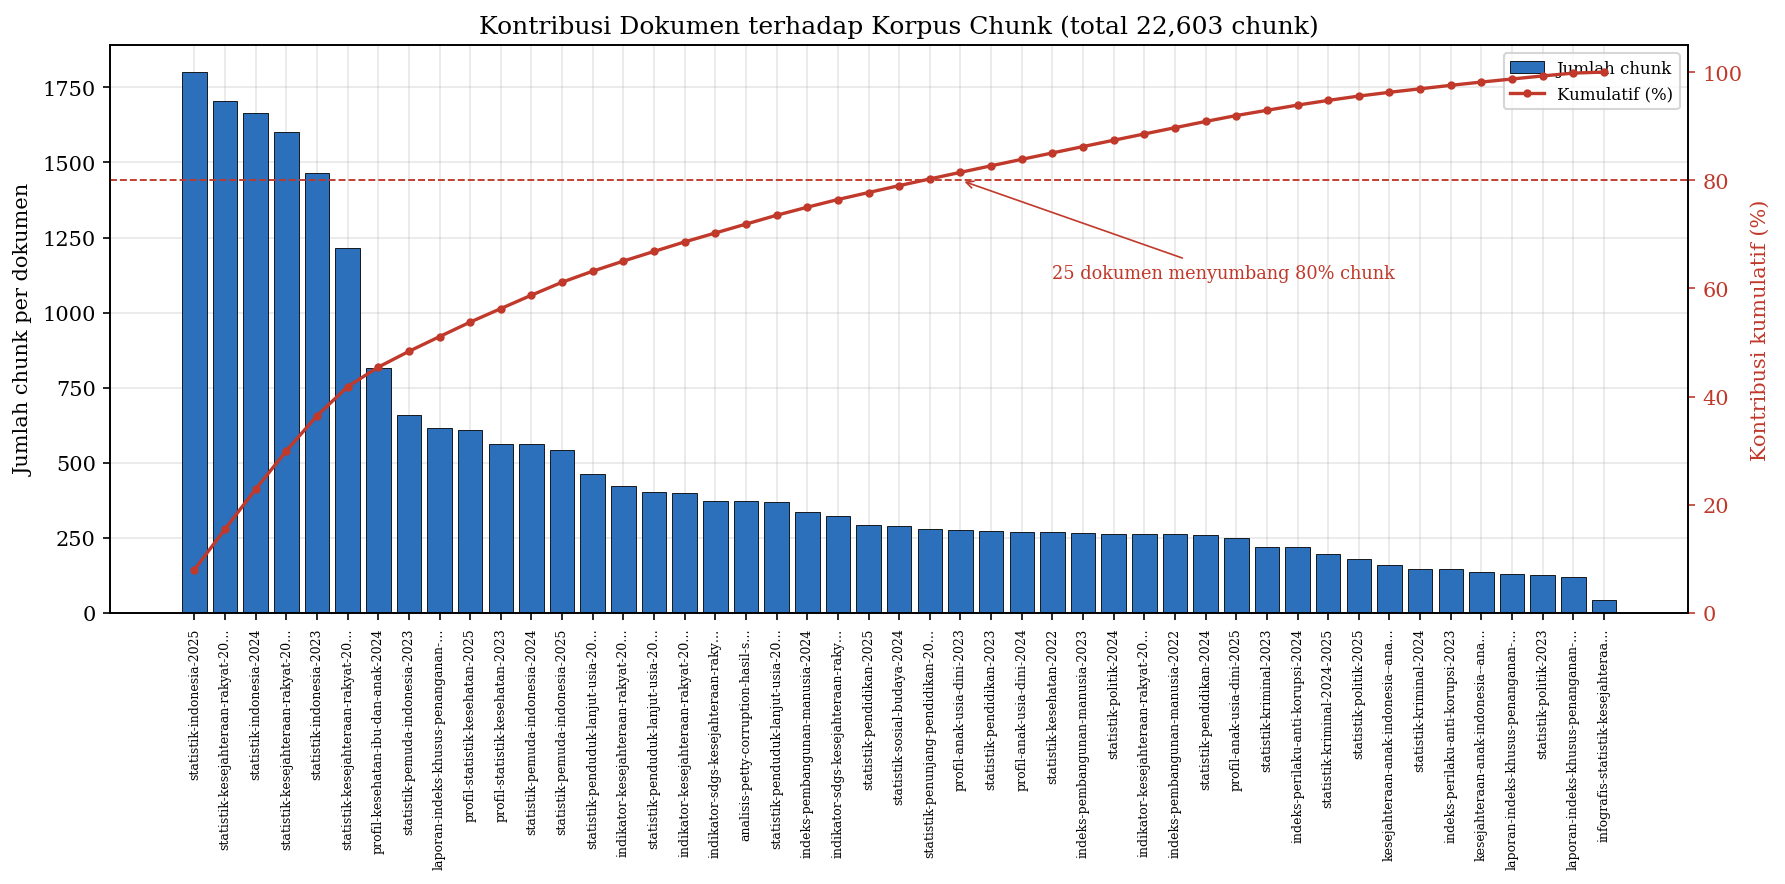

In [240]:
def fig12_kontribusi_chunk():
    d = df_korpus.sort_values("n_chunks", ascending=False).reset_index(drop=True)
    d["kumulatif_pct"] = 100 * d["n_chunks"].cumsum() / d["n_chunks"].sum()

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(d))
    ax.bar(x, d["n_chunks"], color=C_CLEAN, edgecolor="black", linewidth=.4, label="Jumlah chunk")
    ax.set_xticks(x); ax.set_xticklabels([label_pendek(n, 34) for n in d["nama_file"]],
                                         rotation=90, fontsize=6)
    ax.set_ylabel("Jumlah chunk per dokumen")

    ax2 = ax.twinx()
    ax2.plot(x, d["kumulatif_pct"], color=C_DROP, lw=1.6, marker="o", ms=3, label="Kumulatif (%)")
    ax2.set_ylabel("Kontribusi kumulatif (%)", color=C_DROP)
    ax2.tick_params(axis="y", colors=C_DROP); ax2.set_ylim(0, 105); ax2.grid(False)

    n80 = int((d["kumulatif_pct"] <= 80).sum()) + 1
    ax2.axhline(80, ls="--", color=C_DROP, lw=.9)
    ax2.annotate(f"{n80} dokumen menyumbang 80% chunk", xy=(n80, 80), xytext=(n80 + 3, 62),
                 fontsize=8.5, color=C_DROP, arrowprops=dict(arrowstyle="->", color=C_DROP, lw=.8))

    garis, label = ax.get_legend_handles_labels()
    garis2, label2 = ax2.get_legend_handles_labels()
    ax.legend(garis + garis2, label + label2, fontsize=8, loc="upper right")
    ax.set_title(f"Kontribusi Dokumen terhadap Korpus Chunk (total {TOTAL_CHUNKS:,} chunk)")
    plt.tight_layout(); plt.savefig("fig12_kontribusi_chunk.png", bbox_inches="tight"); plt.show()

fig12_kontribusi_chunk()

---
# Bagian 3 — Pembentukan dan Penyaringan Dataset QA

Semua distribusi, cakupan, hasil filtering, keragaman, dan kesesuaian semantik pada bagian ini
berasal dari artefak JSON, JSONL, dan CSV di `Hasil/tujuan2`.


In [241]:
print(f"QA mentah {RAW_RECORDS:,} → lolos pembersihan {FILTERED_RECORDS:,} "
      f"({100 * FILTERED_RECORDS / RAW_RECORDS:.1f}%) → train/val/test "
      f"{SPLIT_COUNTS['train']:,}/{SPLIT_COUNTS['val']:,}/{SPLIT_COUNTS['test']:,}")
print("Seluruh statistik Bagian 3 dimuat dari artefak hasil Tujuan 2.")


QA mentah 12,261 → lolos pembersihan 9,350 (76.3%) → train/val/test 6,516/1,043/1,791
Seluruh statistik Bagian 3 dimuat dari artefak hasil Tujuan 2.


### Gambar 13 — Funnel besar pembentukan dataset QA

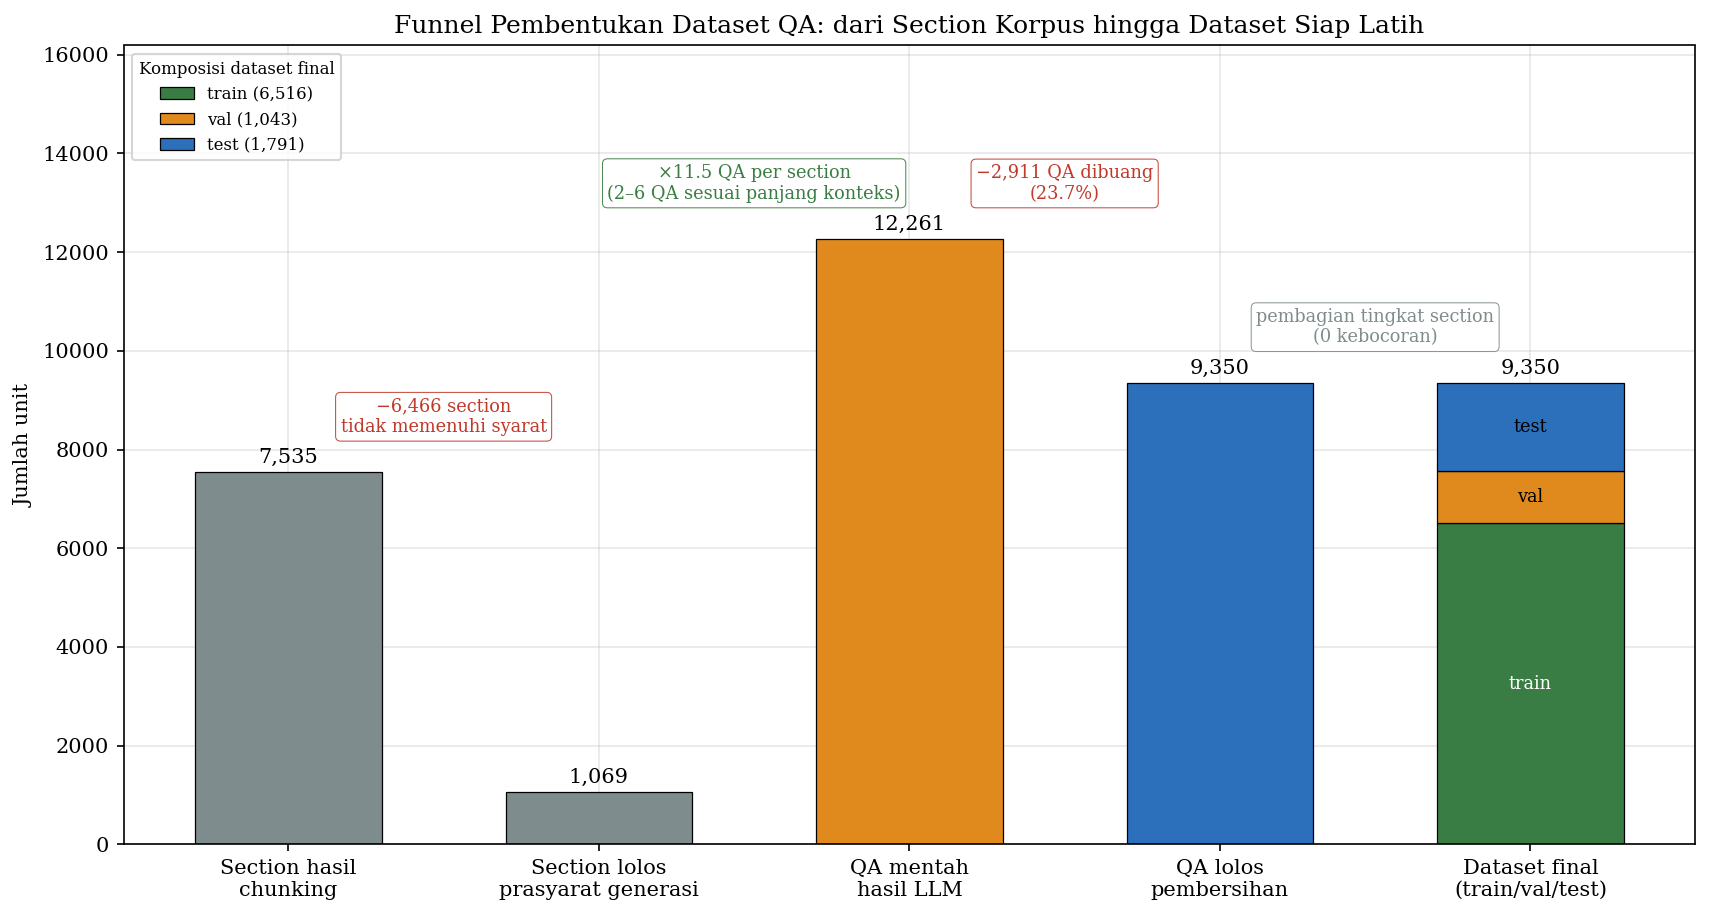

In [242]:
def fig13_funnel_dataset_qa():
    tahap = ["Section hasil\nchunking", "Section lolos\nprasyarat generasi", "QA mentah\nhasil LLM",
             "QA lolos\npembersihan", "Dataset final\n(train/val/test)"]
    nilai = [SECTIONS_RAW, SECTIONS_SELECTED, RAW_RECORDS, FILTERED_RECORDS, sum(SPLIT_COUNTS.values())]
    warna = [C_MUTED, C_MUTED, C_ACCENT, C_CLEAN, C_KEEP]
    x = np.arange(len(tahap))

    fig, ax = plt.subplots(figsize=(11.5, 6.2))
    ax.bar(x[:-1], nilai[:-1], color=warna[:-1], edgecolor="black", linewidth=.6, width=.6)
    bawah = 0
    for (nama_split, jumlah), warna_split in zip(SPLIT_COUNTS.items(), [C_KEEP, C_ACCENT, C_CLEAN]):
        ax.bar(x[-1], jumlah, bottom=bawah, color=warna_split, edgecolor="black",
               linewidth=.6, width=.6, label=f"{nama_split} ({jumlah:,})")
        ax.text(x[-1], bawah + jumlah / 2, nama_split, ha="center", va="center", fontsize=8.5,
                color="white" if nama_split == "train" else "black")
        bawah += jumlah
    for xi, v in zip(x, nilai):
        ax.text(xi, v + max(nilai) * .015, f"{v:,}", ha="center", fontsize=10)

    anotasi_funnel(ax, nilai, [
        (f"−{SECTIONS_RAW - SECTIONS_SELECTED:,} section\ntidak memenuhi syarat", C_DROP),
        (f"×{RAW_RECORDS / SECTIONS_SELECTED:.1f} QA per section\n(2–6 QA sesuai panjang konteks)", C_KEEP),
        (f"−{REMOVED_RECORDS:,} QA dibuang\n({100 * REMOVED_RECORDS / RAW_RECORDS:.1f}%)", C_DROP),
        (f"pembagian tingkat section\n({N_SECTION_BOCOR} kebocoran)", C_MUTED),
    ])

    ax.set_xticks(x); ax.set_xticklabels(tahap)
    ax.set_ylabel("Jumlah unit"); ax.set_ylim(0, max(nilai) * 1.32)
    ax.legend(fontsize=8, loc="upper left", title="Komposisi dataset final", title_fontsize=8)
    ax.set_title("Funnel Pembentukan Dataset QA: dari Section Korpus hingga Dataset Siap Latih")
    plt.tight_layout(); plt.savefig("fig13_funnel_dataset_qa.png", bbox_inches="tight"); plt.show()

fig13_funnel_dataset_qa()

### Gambar 14 — Penyaringan section sebelum generasi dan status parsing keluaran LLM

Kedua panel menggunakan `generation_statistics.json` dan distribusi record pada `raw_records.jsonl`.


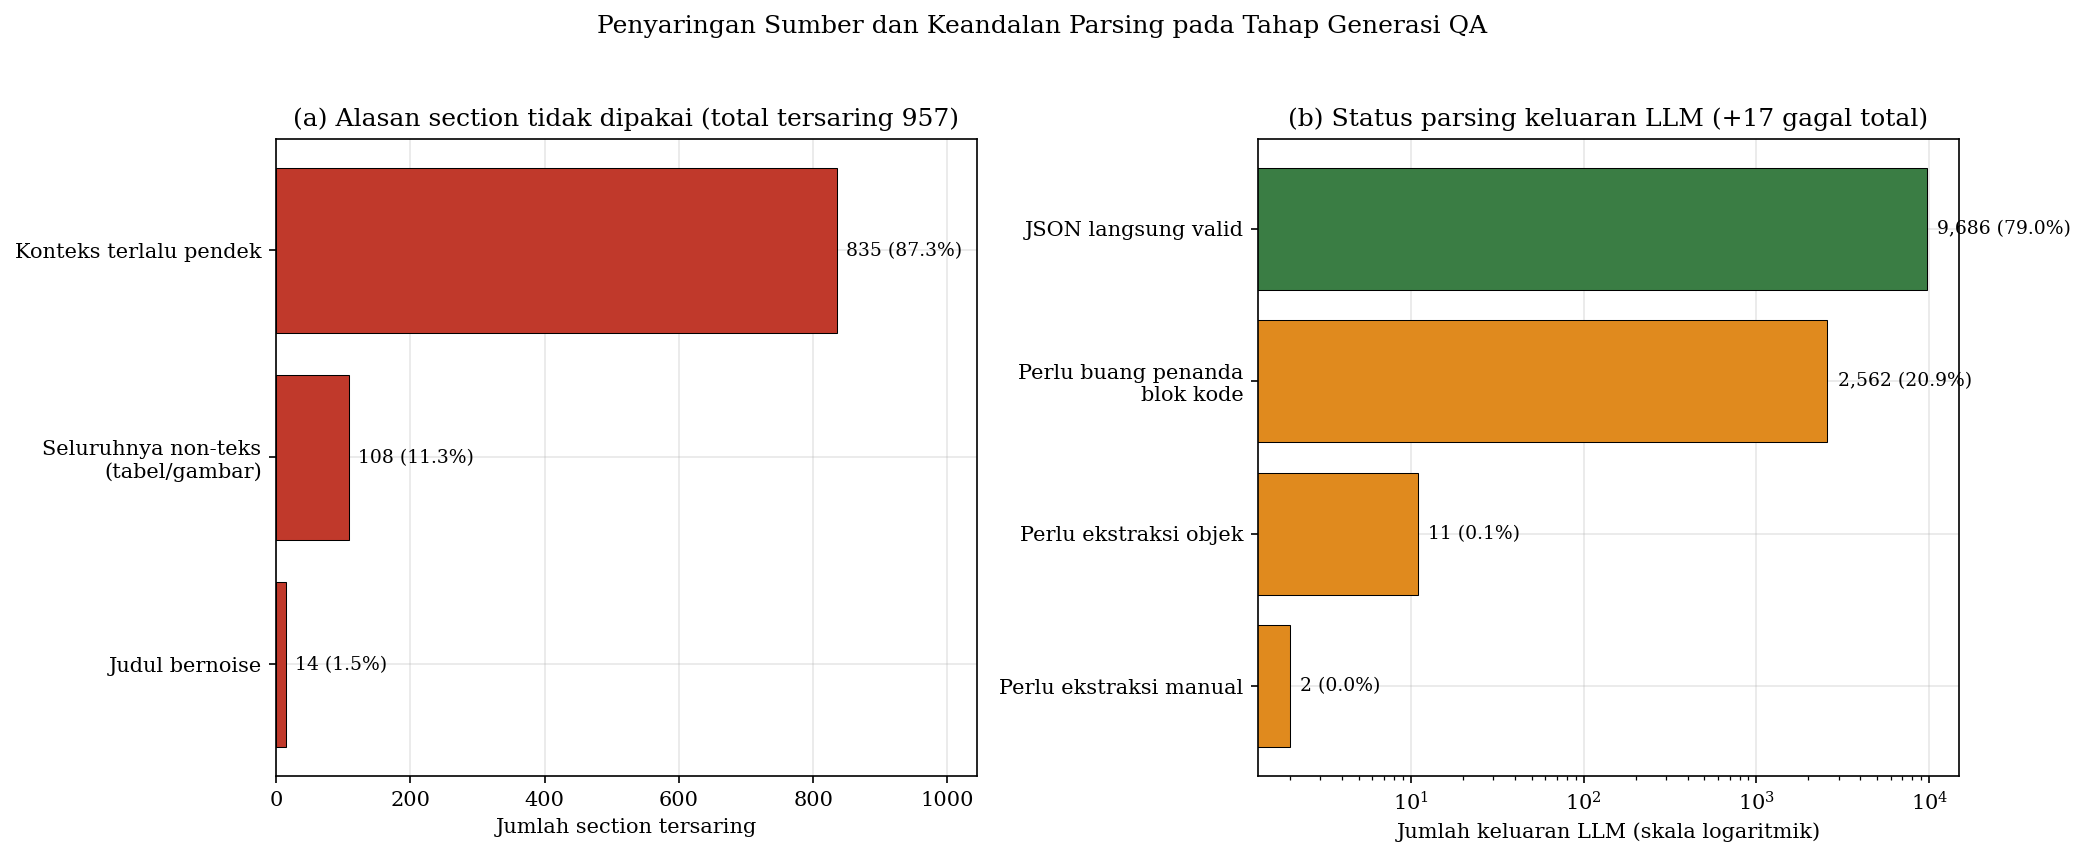

In [243]:
def fig14_penyaringan_dan_parsing():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    ax = axes[0]
    ket = {"too_short": "Konteks terlalu pendek", "all_non_text": "Seluruhnya non-teks\n(tabel/gambar)",
           "noise_title": "Judul bernoise"}
    d = pd.Series(GEN_FILTER_SECTION).sort_values()
    total_filter = d.sum()
    ax.barh([ket[k] for k in d.index], d.values, color=C_DROP, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total_filter * .015, y, f"{v:,} ({100 * v / total_filter:.1f}%)", va="center", fontsize=9)
    ax.set_xlabel("Jumlah section tersaring")
    ax.set_xlim(0, d.max() * 1.25)
    ax.set_title(f"(a) Alasan section tidak dipakai (total tersaring {total_filter:,})")

    ax = axes[1]
    ket2 = {"direct": "JSON langsung valid", "fence_stripped": "Perlu buang penanda\nblok kode",
            "extracted_object_wrapped": "Perlu ekstraksi objek", "extracted": "Perlu ekstraksi manual"}
    d2 = pd.Series(PARSE_STATUS).sort_values()
    total_parse = d2.sum()
    warna = [C_KEEP if k == "direct" else C_ACCENT for k in d2.index]
    ax.barh([ket2[k] for k in d2.index], d2.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d2.values):
        ax.text(v * 1.15, y, f"{v:,} ({100 * v / total_parse:.1f}%)", va="center", fontsize=9)
    ax.set_xscale("log"); ax.set_xlabel("Jumlah keluaran LLM (skala logaritmik)")
    ax.set_title(f"(b) Status parsing keluaran LLM (+{GEN_FAILURES} gagal total)")

    fig.suptitle("Penyaringan Sumber dan Keandalan Parsing pada Tahap Generasi QA", y=1.03)
    plt.tight_layout(); plt.savefig("fig14_penyaringan_dan_parsing.png", bbox_inches="tight"); plt.show()

fig14_penyaringan_dan_parsing()

### Gambar 15 — Komposisi tipe pertanyaan pada dataset QA mentah

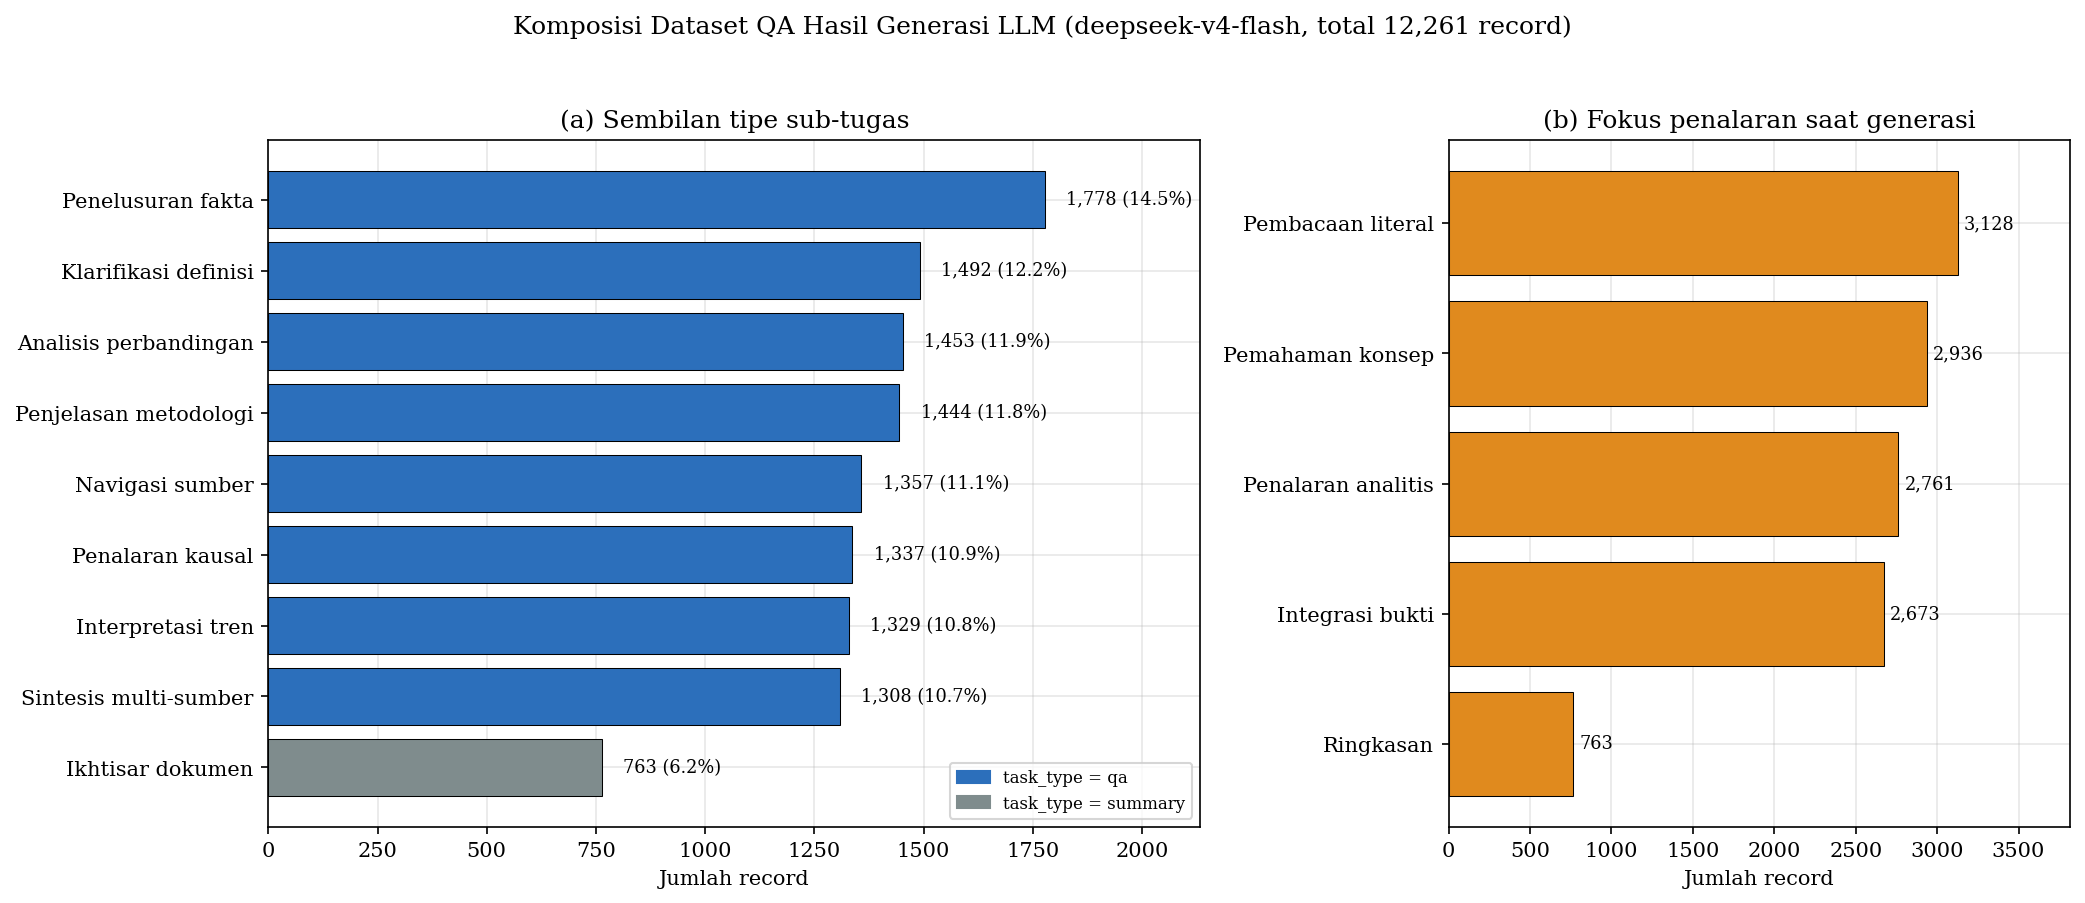

In [244]:
def fig15_komposisi_subtask():
    d = pd.Series(SUBTASK_RAW).sort_values()
    total = d.sum()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1.5, 1]})

    ax = axes[0]
    warna = [C_MUTED if k == "document_overview" else C_CLEAN for k in d.index]
    ax.barh([SUBTASK_LABEL[k] for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + total * .004, y, f"{v:,} ({100 * v / total:.1f}%)", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah record"); ax.set_xlim(0, d.max() * 1.2)
    ax.set_title("(a) Sembilan tipe sub-tugas")
    ax.legend(handles=[Patch(color=C_CLEAN, label="task_type = qa"),
                       Patch(color=C_MUTED, label="task_type = summary")], fontsize=8, loc="lower right")

    ax = axes[1]
    d2 = pd.Series(GENERATION_FOCUS).sort_values()
    ket = {"literal_reading": "Pembacaan literal", "concept_understanding": "Pemahaman konsep",
           "analytical_reasoning": "Penalaran analitis", "evidence_integration": "Integrasi bukti",
           "summary": "Ringkasan"}
    ax.barh([ket[k] for k in d2.index], d2.values, color=C_ACCENT, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d2.values):
        ax.text(v + d2.max() * .012, y, f"{v:,}", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah record"); ax.set_xlim(0, d2.max() * 1.22)
    ax.set_title("(b) Fokus penalaran saat generasi")

    fig.suptitle(f"Komposisi Dataset QA Hasil Generasi LLM ({GEN_LLM}, total {total:,} record)", y=1.03)
    plt.tight_layout(); plt.savefig("fig15_komposisi_subtask.png", bbox_inches="tight"); plt.show()

fig15_komposisi_subtask()

### Gambar 16 — Cakupan korpus oleh dataset QA

Cakupan dan konsentrasi record dihitung ulang dari `raw_records.jsonl`; tidak ada jumlah dokumen
atau record yang ditanam di deskripsi.


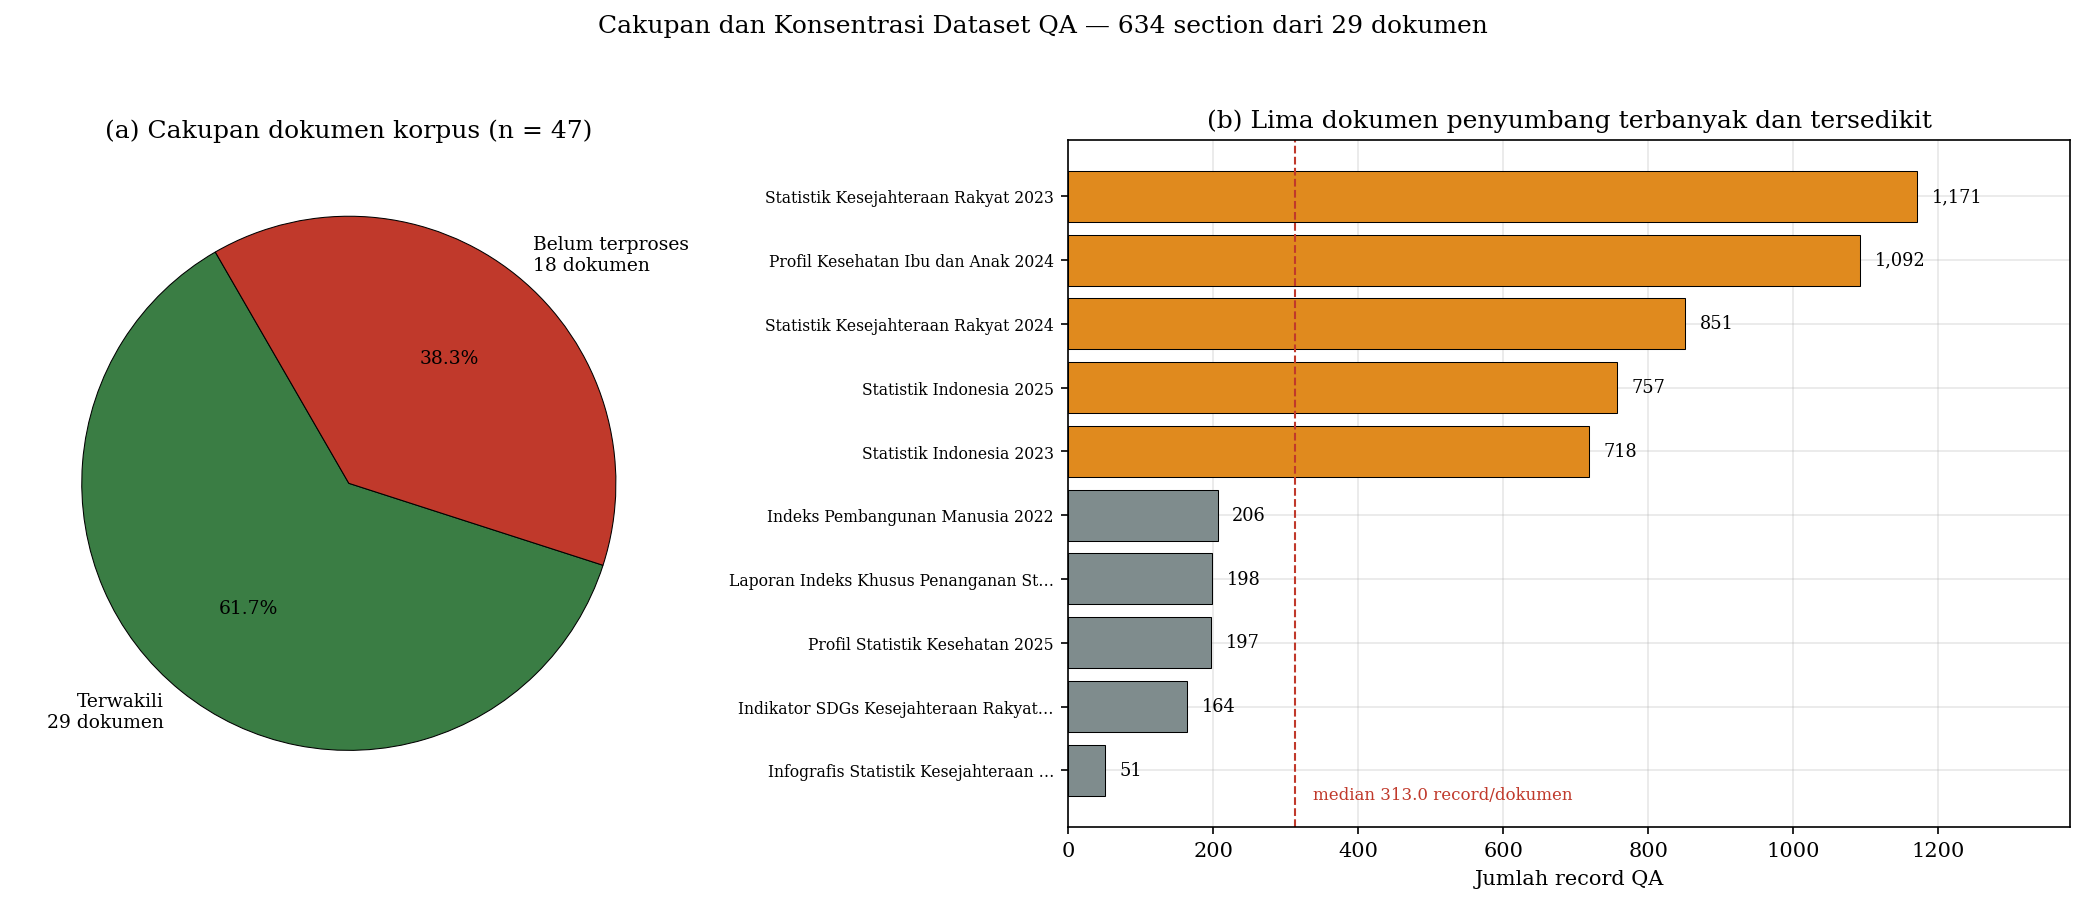

In [245]:
def fig16_cakupan_korpus():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1, 1.5]})

    ax = axes[0]
    n_total_dok = len(df_clean)
    terwakili, tidak = DOK_UNIK, n_total_dok - DOK_UNIK
    ax.pie([terwakili, tidak],
           labels=[f"Terwakili\n{terwakili} dokumen", f"Belum terproses\n{tidak} dokumen"],
           colors=[C_KEEP, C_DROP], startangle=120, autopct="%1.1f%%",
           wedgeprops={"edgecolor": "black", "linewidth": .5}, textprops={"fontsize": 9})
    ax.set_title(f"(a) Cakupan dokumen korpus (n = {n_total_dok})")
    ax.grid(False)

    ax = axes[1]
    gabungan = {**TOP_DOKUMEN, **BOTTOM_DOKUMEN}
    d = pd.Series(gabungan).sort_values()
    warna = [C_ACCENT if v >= REC_PER_DOK["median"] else C_MUTED for v in d.values]
    ax.barh([label_pendek(k, 36) for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + 20, y, f"{v:,}", va="center", fontsize=8.5)
    ax.axvline(REC_PER_DOK["median"], ls="--", color=C_DROP, lw=1)
    ax.text(REC_PER_DOK["median"] + 25, -0.45, f"median {REC_PER_DOK['median']} record/dokumen",
            color=C_DROP, fontsize=8)
    ax.set_xlabel("Jumlah record QA"); ax.tick_params(axis="y", labelsize=7.5)
    ax.set_xlim(0, d.max() * 1.18)
    ax.set_title("(b) Lima dokumen penyumbang terbanyak dan tersedikit")

    fig.suptitle(f"Cakupan dan Konsentrasi Dataset QA — {SECTION_UNIK} section dari {DOK_UNIK} dokumen", y=1.03)
    plt.tight_layout(); plt.savefig("fig16_cakupan_korpus.png", bbox_inches="tight"); plt.show()

fig16_cakupan_korpus()

### Gambar 17 — Biaya komputasi generasi: penggunaan token LLM

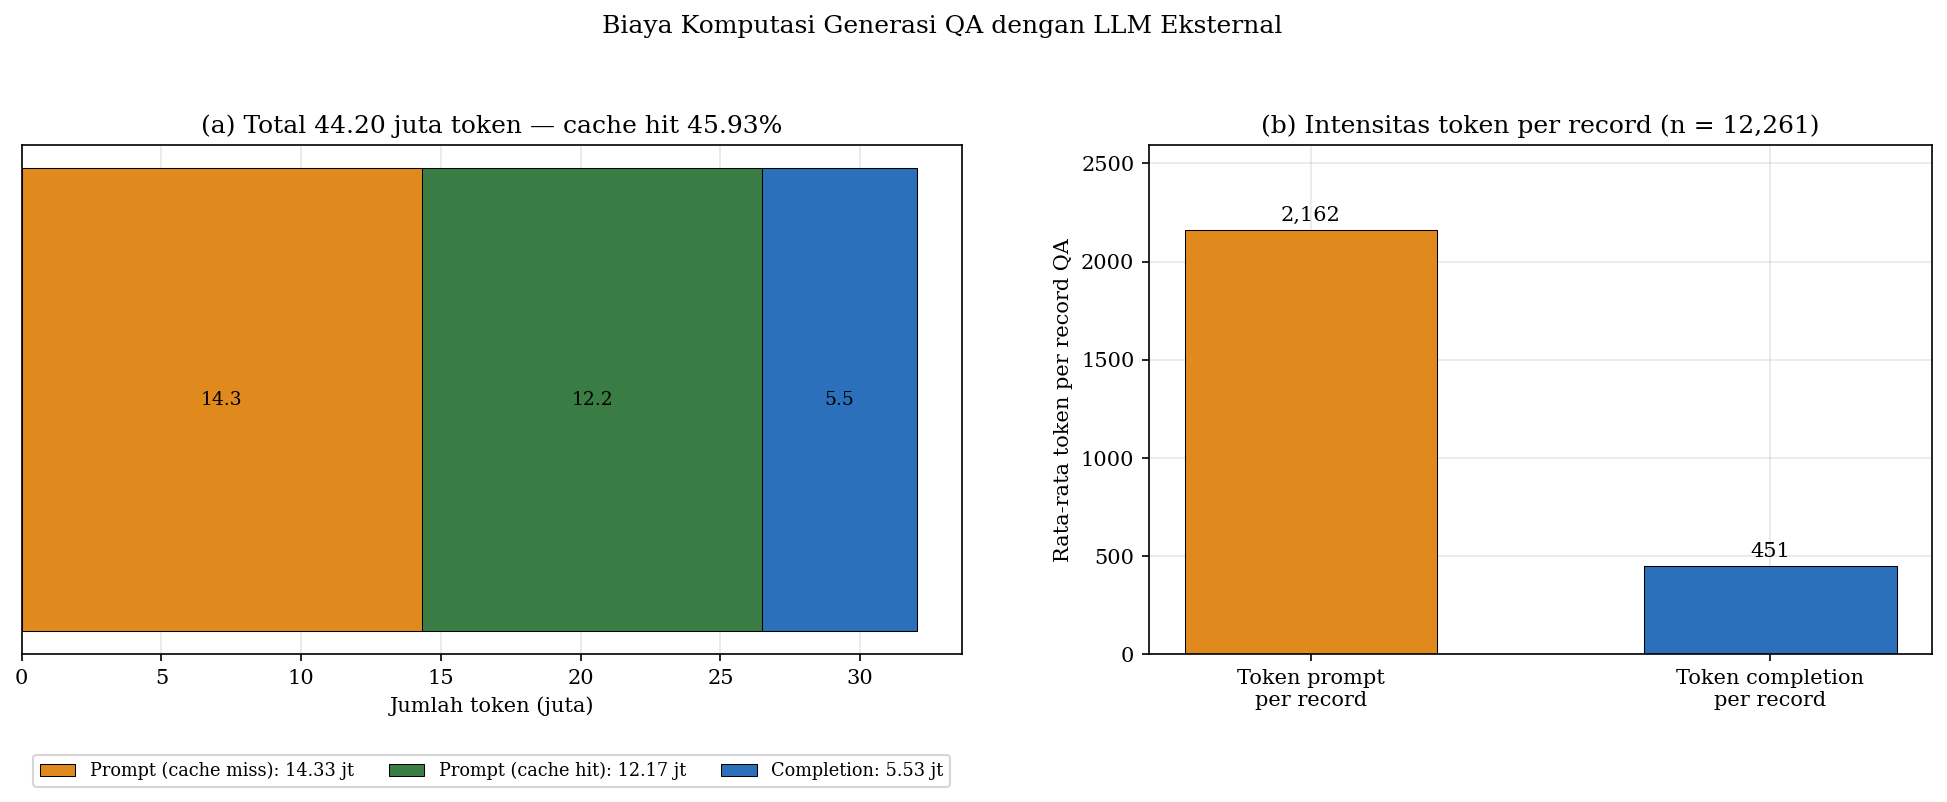

In [246]:
def fig17_biaya_token():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})

    ax = axes[0]
    prompt_baru = TOKEN_USAGE["prompt"] - TOKEN_USAGE["cached"]
    bagian = [("Prompt (cache miss)", prompt_baru, C_ACCENT),
              ("Prompt (cache hit)", TOKEN_USAGE["cached"], C_KEEP),
              ("Completion", TOKEN_USAGE["completion"], C_CLEAN)]
    kiri = 0
    for nama, nilai, warna in bagian:
        ax.barh([0], [nilai / 1e6], left=kiri / 1e6, color=warna, edgecolor="black",
                linewidth=.5, label=f"{nama}: {nilai / 1e6:.2f} jt")
        ax.text((kiri + nilai / 2) / 1e6, 0, f"{nilai / 1e6:.1f}", ha="center", va="center", fontsize=9)
        kiri += nilai
    ax.set_yticks([]); ax.set_xlabel("Jumlah token (juta)")
    ax.set_title(f"(a) Total {sum(TOKEN_USAGE.values()) / 1e6:.2f} juta token "
                 f"— cache hit {CACHE_HIT_RATE}%")
    ax.legend(fontsize=8.5, loc="upper center", bbox_to_anchor=(.5, -.18), ncol=3)

    ax = axes[1]
    rasio = {"Token prompt\nper record": TOKEN_USAGE["prompt"] / RAW_RECORDS,
             "Token completion\nper record": TOKEN_USAGE["completion"] / RAW_RECORDS}
    ax.bar(list(rasio.keys()), list(rasio.values()), color=[C_ACCENT, C_CLEAN],
           edgecolor="black", linewidth=.5, width=.55)
    for i, v in enumerate(rasio.values()):
        ax.text(i, v + 45, f"{v:,.0f}", ha="center", fontsize=10)
    ax.set_ylabel("Rata-rata token per record QA")
    ax.set_ylim(0, max(rasio.values()) * 1.2)
    ax.set_title(f"(b) Intensitas token per record (n = {RAW_RECORDS:,})")

    fig.suptitle("Biaya Komputasi Generasi QA dengan LLM Eksternal", y=1.04)
    plt.tight_layout(); plt.savefig("fig17_biaya_token.png", bbox_inches="tight"); plt.show()

fig17_biaya_token()

### Gambar 18 — Distribusi panjang pertanyaan, jawaban, dan rantai penalaran

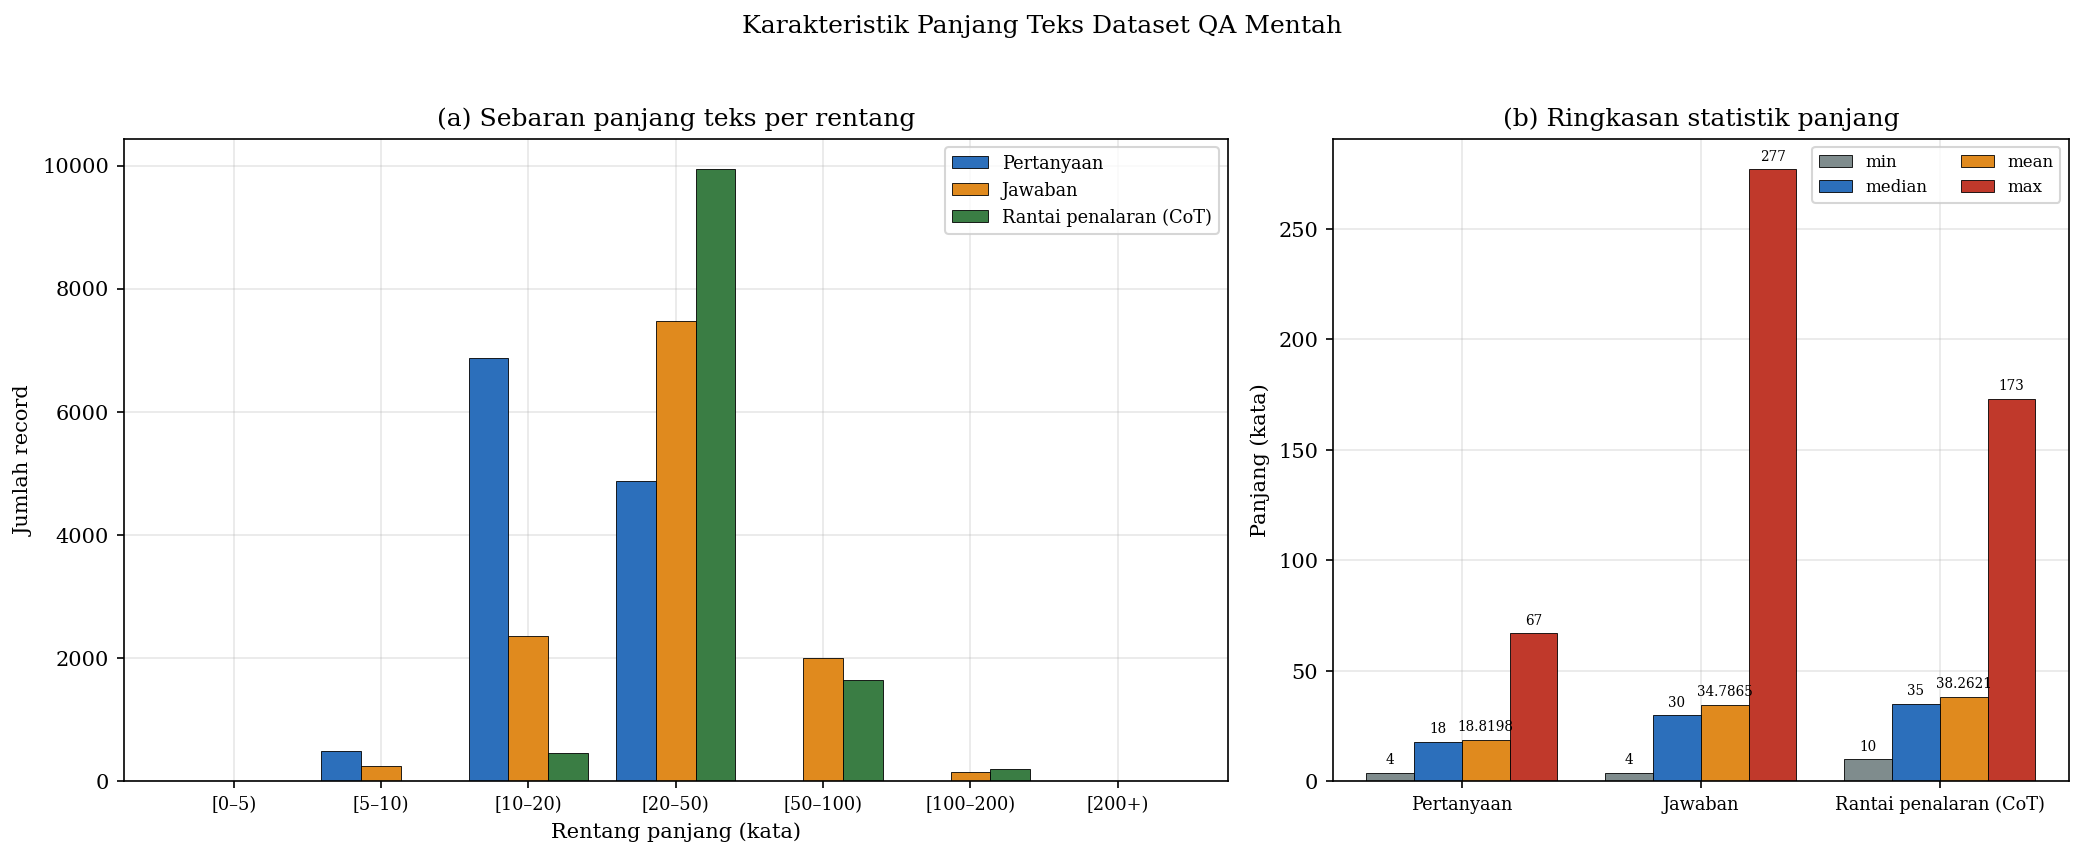

In [247]:
def fig18_panjang_teks():
    bucket_urut = ["[0–5)", "[5–10)", "[10–20)", "[20–50)", "[50–100)", "[100–200)", "[200+)"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})

    ax = axes[0]
    x = np.arange(len(bucket_urut)); w = 0.27
    warna_field = {"Instruction": C_CLEAN, "Response": C_ACCENT, "CoT": C_KEEP}
    label_field = {"Instruction": "Pertanyaan", "Response": "Jawaban", "CoT": "Rantai penalaran (CoT)"}
    for i, (field, warna) in enumerate(warna_field.items()):
        nilai = [BUCKET_PANJANG[field].get(b, 0) for b in bucket_urut]
        ax.bar(x + (i - 1) * w, nilai, w, color=warna, edgecolor="black",
               linewidth=.4, label=label_field[field])
    ax.set_xticks(x); ax.set_xticklabels(bucket_urut, fontsize=8.5)
    ax.set_xlabel("Rentang panjang (kata)"); ax.set_ylabel("Jumlah record")
    ax.set_title("(a) Sebaran panjang teks per rentang"); ax.legend(fontsize=8.5)

    ax = axes[1]
    x2 = np.arange(len(PANJANG_STAT)); w2 = 0.2
    for i, (kol, warna) in enumerate([("min", C_MUTED), ("median", C_CLEAN),
                                      ("mean", C_ACCENT), ("max", C_DROP)]):
        ax.bar(x2 + (i - 1.5) * w2, PANJANG_STAT[kol], w2, color=warna,
               edgecolor="black", linewidth=.4, label=kol)
        for xi, v in zip(x2 + (i - 1.5) * w2, PANJANG_STAT[kol]):
            ax.text(xi, v + 4, f"{v:g}", ha="center", fontsize=6.5)
    ax.set_xticks(x2); ax.set_xticklabels([label_field[f] for f in PANJANG_STAT.index], fontsize=8.5)
    ax.set_ylabel("Panjang (kata)"); ax.legend(fontsize=8, ncol=2)
    ax.set_title("(b) Ringkasan statistik panjang")

    fig.suptitle("Karakteristik Panjang Teks Dataset QA Mentah", y=1.03)
    plt.tight_layout(); plt.savefig("fig18_panjang_teks.png", bbox_inches="tight"); plt.show()

fig18_panjang_teks()

### Gambar 19 — Temuan masalah kualitas pada tahap eksplorasi
Tahap eksplorasi berfungsi mengidentifikasi seluruh potensi cacat sebelum menentukan aturan pembersihan. Sebagian temuan bersifat berat (mis. residu notasi tabel) dan dijadikan dasar pembuangan, sebagian lain bersifat penanda (mis. CoT tanpa kutipan literal) yang dicatat tetapi tidak otomatis menggugurkan record.

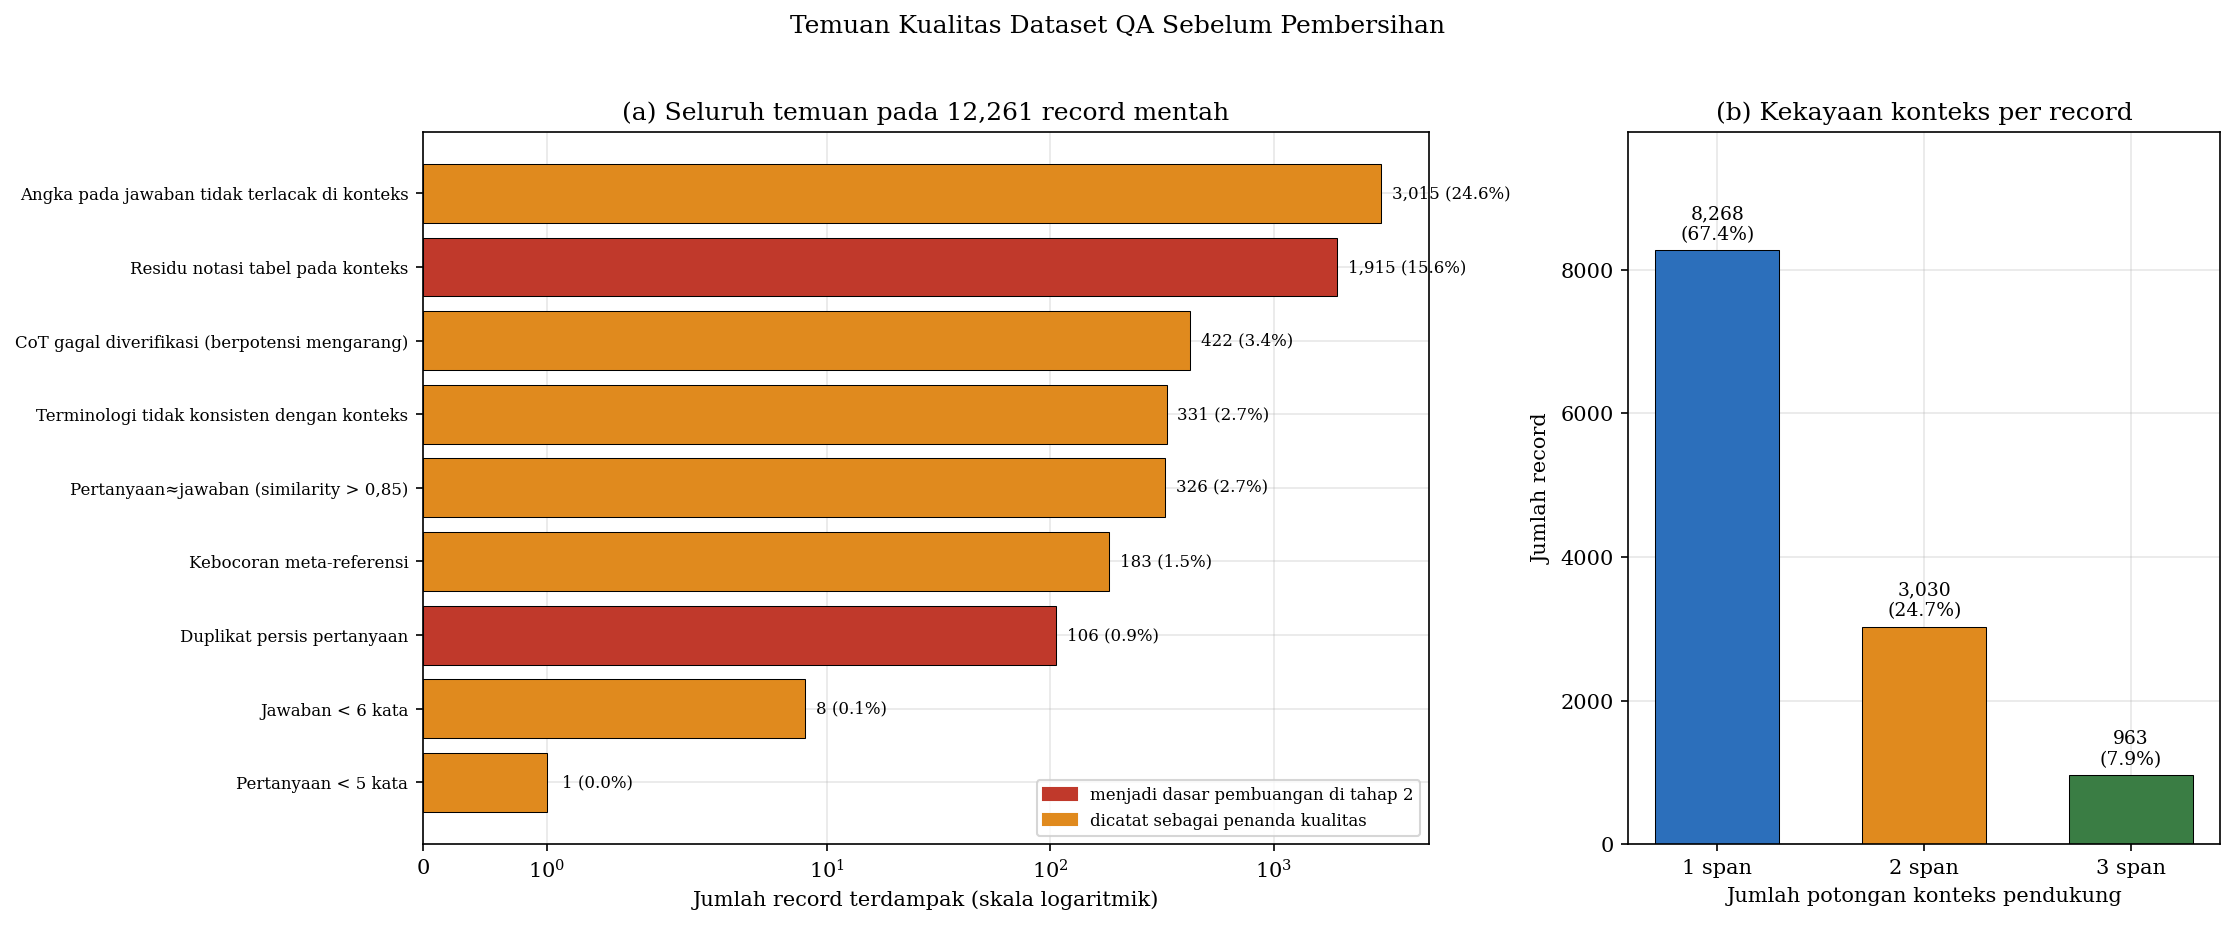

In [248]:
def fig19_temuan_kualitas():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.7, 1]})

    ax = axes[0]
    d = pd.Series(TEMUAN_KUALITAS).sort_values()
    jadi_gate = {"Residu notasi tabel pada konteks", "Duplikat persis pertanyaan"}
    warna = [C_DROP if k in jadi_gate else C_ACCENT for k in d.index]
    ax.barh(d.index, d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v * 1.12, y, f"{v:,} ({100 * v / RAW_RECORDS:.1f}%)", va="center", fontsize=8)
    ax.set_xscale("symlog"); ax.set_xlabel("Jumlah record terdampak (skala logaritmik)")
    ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"(a) Seluruh temuan pada {RAW_RECORDS:,} record mentah")
    ax.legend(handles=[Patch(color=C_DROP, label="menjadi dasar pembuangan di tahap 2"),
                       Patch(color=C_ACCENT, label="dicatat sebagai penanda kualitas")],
              fontsize=8, loc="lower right")

    ax = axes[1]
    d2 = pd.Series(CONTEXT_SPANS)
    ax.bar(d2.index, d2.values, color=[C_CLEAN, C_ACCENT, C_KEEP], edgecolor="black", linewidth=.5, width=.6)
    for i, v in enumerate(d2.values):
        ax.text(i, v + RAW_RECORDS * .012, f"{v:,}\n({100 * v / d2.sum():.1f}%)", ha="center", fontsize=9)
    ax.set_ylabel("Jumlah record"); ax.set_ylim(0, d2.max() * 1.2)
    ax.set_xlabel("Jumlah potongan konteks pendukung")
    ax.set_title("(b) Kekayaan konteks per record")

    fig.suptitle("Temuan Kualitas Dataset QA Sebelum Pembersihan", y=1.02)
    plt.tight_layout(); plt.savefig("fig19_temuan_kualitas.png", bbox_inches="tight"); plt.show()

fig19_temuan_kualitas()

### Gambar 20 — Pembersihan bertingkat: berapa yang terbuang dan mengapa

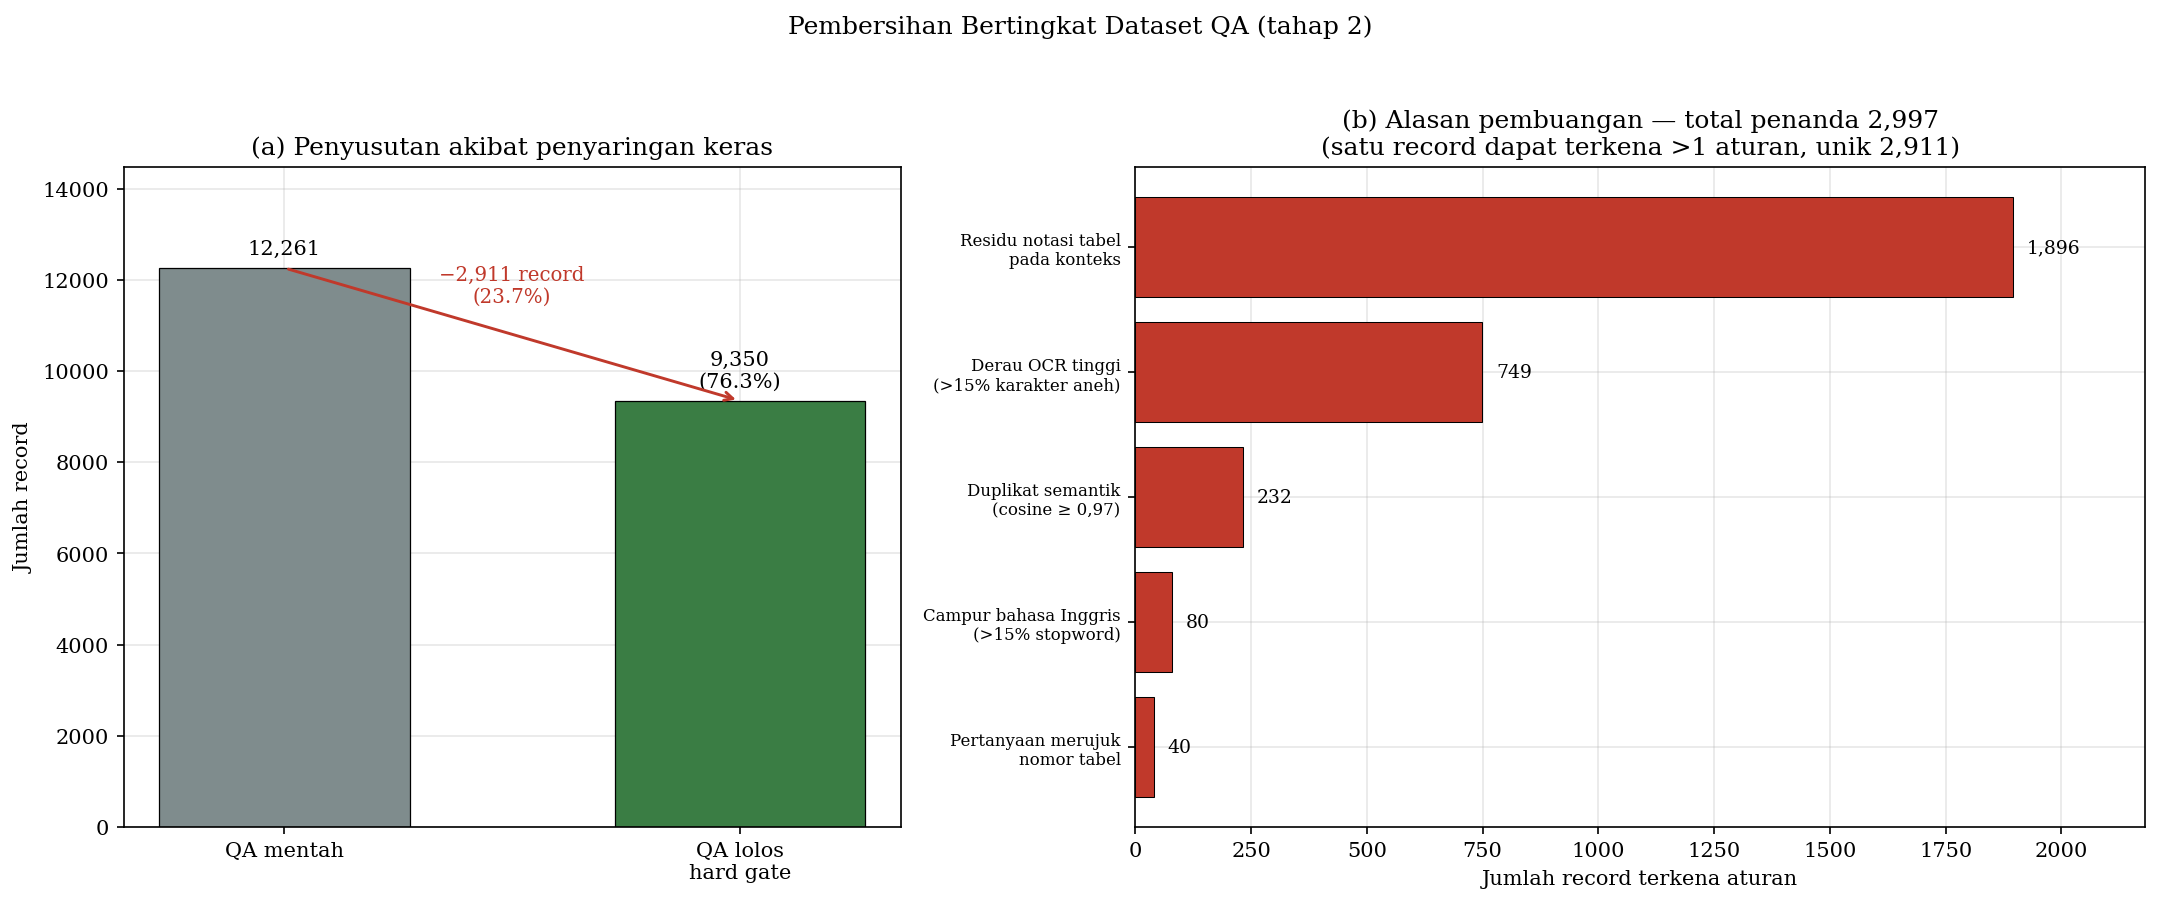

In [249]:
def fig20_funnel_pembersihan():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1, 1.3]})

    ax = axes[0]
    ax.bar(["QA mentah", "QA lolos\nhard gate"], [RAW_RECORDS, FILTERED_RECORDS],
           color=[C_MUTED, C_KEEP], edgecolor="black", linewidth=.6, width=.55)
    ax.text(0, RAW_RECORDS + 300, f"{RAW_RECORDS:,}", ha="center", fontsize=10)
    ax.text(1, FILTERED_RECORDS + 300, f"{FILTERED_RECORDS:,}\n({100 * FILTERED_RECORDS / RAW_RECORDS:.1f}%)",
            ha="center", fontsize=10)
    ax.annotate("", xy=(1, FILTERED_RECORDS), xytext=(0, RAW_RECORDS),
                arrowprops=dict(arrowstyle="->", color=C_DROP, lw=1.4))
    ax.text(.5, (RAW_RECORDS + FILTERED_RECORDS) / 2 + 700,
            f"−{REMOVED_RECORDS:,} record\n({100 * REMOVED_RECORDS / RAW_RECORDS:.1f}%)",
            ha="center", fontsize=9.5, color=C_DROP)
    ax.set_ylabel("Jumlah record"); ax.set_ylim(0, RAW_RECORDS * 1.18)
    ax.set_title("(a) Penyusutan akibat penyaringan keras")

    ax = axes[1]
    ket = {"table_residue": "Residu notasi tabel\npada konteks",
           "high_ocr_noise": "Derau OCR tinggi\n(>15% karakter aneh)",
           "near_duplicate": "Duplikat semantik\n(cosine ≥ 0,97)",
           "mixed_english_detected": "Campur bahasa Inggris\n(>15% stopword)",
           "table_ref_instruction": "Pertanyaan merujuk\nnomor tabel"}
    d = pd.Series(REMOVAL_REASONS).sort_values()
    ax.barh([ket[k] for k in d.index], d.values, color=C_DROP, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + 30, y, f"{v:,}", va="center", fontsize=9)
    ax.set_xlabel("Jumlah record terkena aturan")
    ax.set_xlim(0, d.max() * 1.15); ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"(b) Alasan pembuangan — total penanda {sum(REMOVAL_REASONS.values()):,}\n"
                 f"(satu record dapat terkena >1 aturan, unik {REMOVED_RECORDS:,})")

    fig.suptitle("Pembersihan Bertingkat Dataset QA (tahap 2)", y=1.03)
    plt.tight_layout(); plt.savefig("fig20_funnel_pembersihan.png", bbox_inches="tight"); plt.show()

fig20_funnel_pembersihan()

### Gambar 21 — Skor kualitas komposit (`track_a_score`) per tipe sub-tugas

Rata-rata dan minimum per sub-tugas berasal dari `qc_tahap1_report.json`, sedangkan distribusi
record lolos dihitung dari `filtered_records.jsonl`.


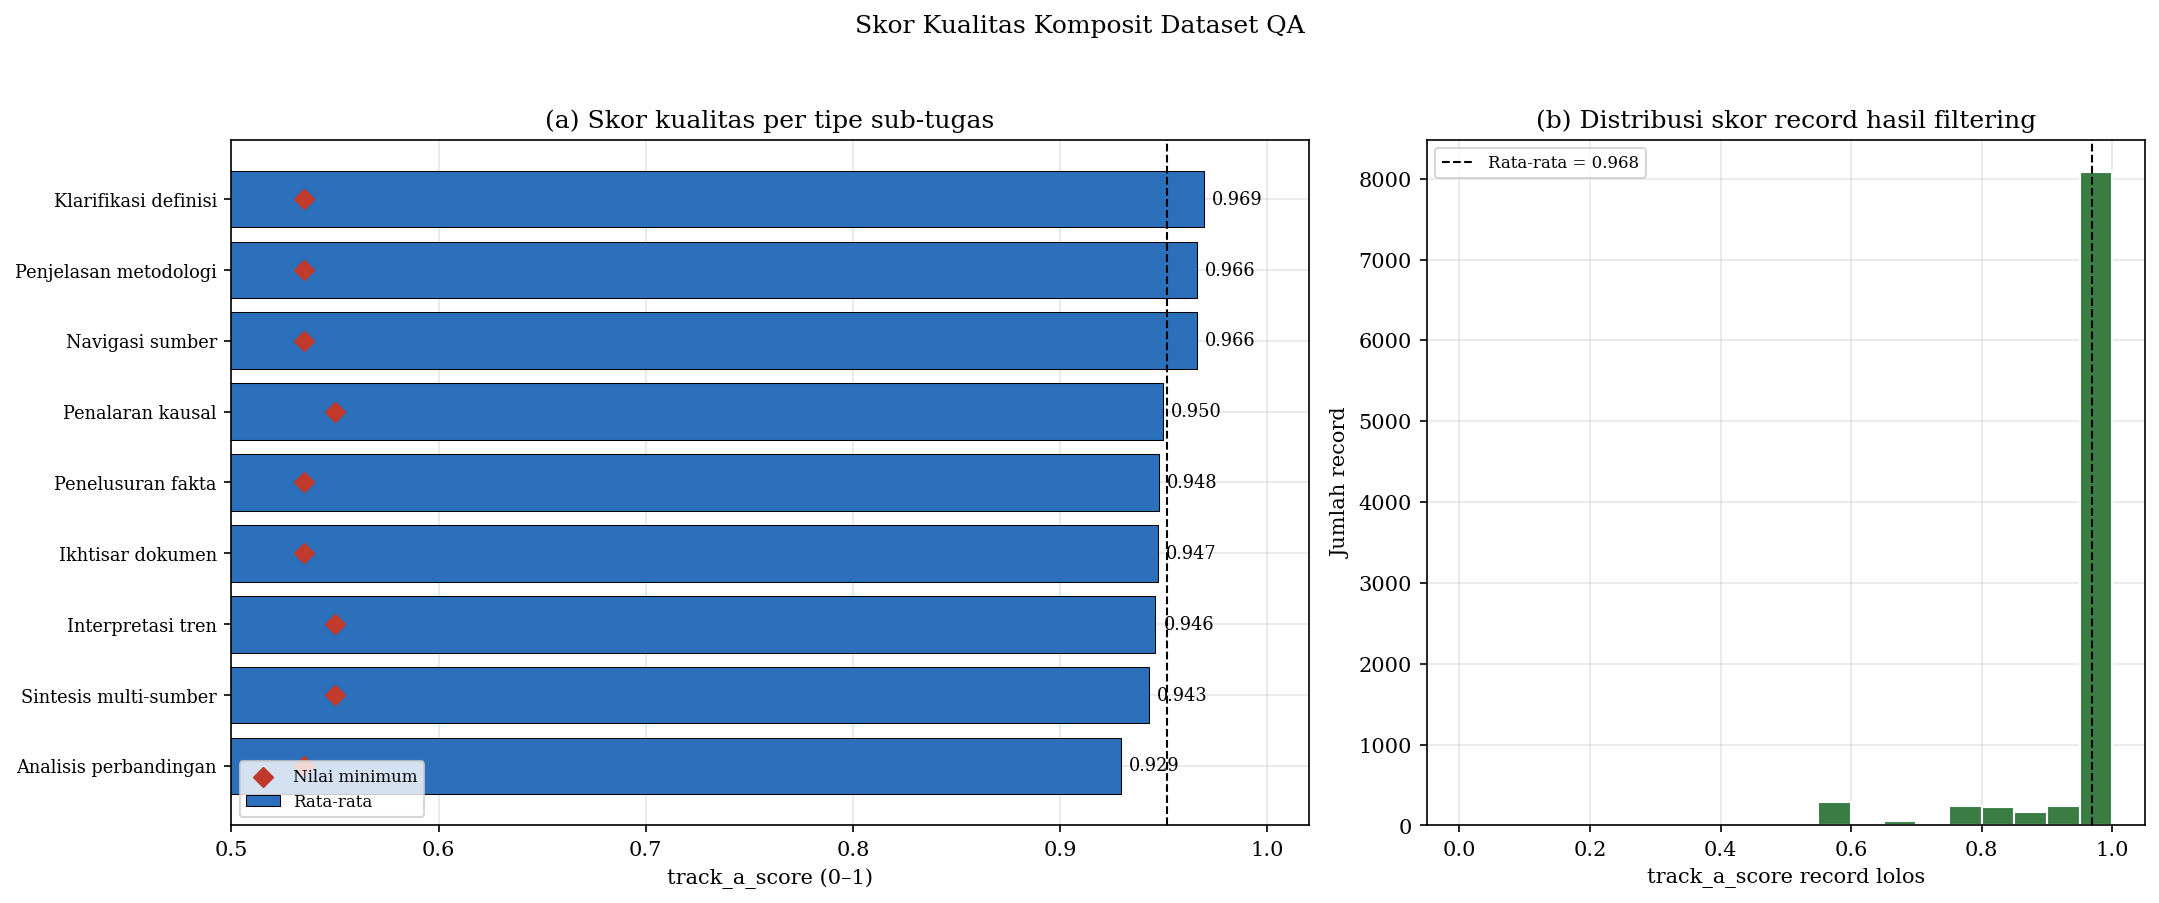

In [250]:
def fig21_skor_kualitas():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1.5, 1]})
    ax = axes[0]
    d = TRACK_A_SUBTASK.sort_values("mean")
    y = np.arange(len(d))
    ax.barh(y, d["mean"], color=C_CLEAN, edgecolor="black", linewidth=.5, label="Rata-rata")
    ax.scatter(d["min"], y, color=C_DROP, s=42, zorder=3, marker="D", label="Nilai minimum")
    for yi, v in zip(y, d["mean"]):
        ax.text(v + .004, yi, f"{v:.3f}", va="center", fontsize=8.5)
    ax.axvline(TRACK_A_MEAN_ALL, ls="--", color="black", lw=1)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL.get(k, k) for k in d.index], fontsize=8.5)
    ax.set_xlim(.5, 1.02); ax.set_xlabel("track_a_score (0–1)")
    ax.set_title("(a) Skor kualitas per tipe sub-tugas"); ax.legend(fontsize=8, loc="lower left")

    ax = axes[1]
    skor_lolos = [r["track_a_score"] for r in filtered_records if r.get("track_a_score") is not None]
    ax.hist(skor_lolos, bins=np.linspace(0, 1, 21), color=C_KEEP, edgecolor="white")
    ax.axvline(np.mean(skor_lolos), color="black", ls="--", lw=1,
               label=f"Rata-rata = {np.mean(skor_lolos):.3f}")
    ax.set_xlabel("track_a_score record lolos"); ax.set_ylabel("Jumlah record")
    ax.set_title("(b) Distribusi skor record hasil filtering"); ax.legend(fontsize=8)

    fig.suptitle("Skor Kualitas Komposit Dataset QA", y=1.03)
    plt.tight_layout(); plt.savefig("fig21_skor_kualitas.png", bbox_inches="tight"); plt.show()

fig21_skor_kualitas()


### Gambar 22 — Keragaman pertanyaan dan konsentrasi pola pembuka

Metrik keragaman dibaca dari `diversity_summary.json`; distribusi pembuka dibaca dari
`opener_distribution.csv`.


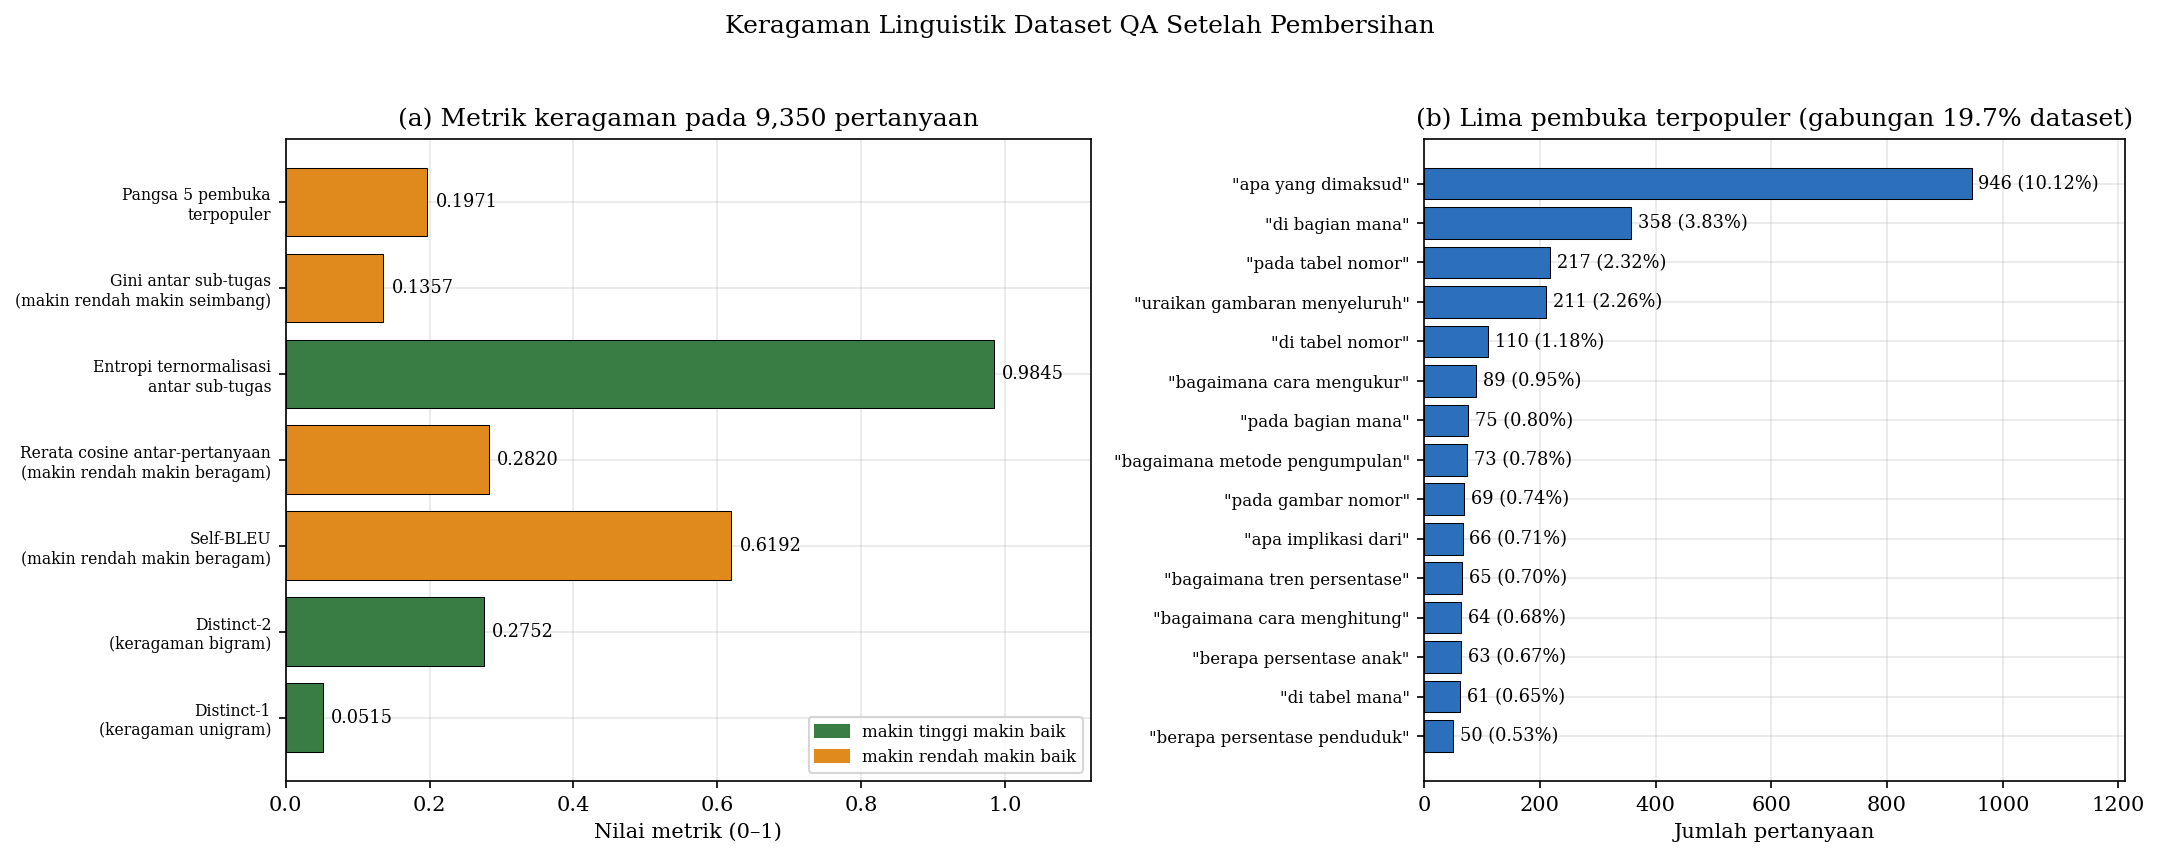

In [251]:
def fig22_keragaman():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5), gridspec_kw={"width_ratios": [1.15, 1]})

    ax = axes[0]
    ket = {"distinct_1": "Distinct-1\n(keragaman unigram)", "distinct_2": "Distinct-2\n(keragaman bigram)",
           "self_bleu": "Self-BLEU\n(makin rendah makin beragam)",
           "mean_pairwise_cosine": "Rerata cosine antar-pertanyaan\n(makin rendah makin beragam)",
           "stratum_normalized_entropy": "Entropi ternormalisasi\nantar sub-tugas",
           "stratum_gini": "Gini antar sub-tugas\n(makin rendah makin seimbang)",
           "top5_opener_share": "Pangsa 5 pembuka\nterpopuler"}
    makin_tinggi_makin_baik = {"distinct_1", "distinct_2", "stratum_normalized_entropy"}

    # Filter Series d agar hanya berisi kunci yang didefinisikan dalam ket
    d = pd.Series(DIVERSITY)
    d = d[d.index.isin(ket.keys())]

    warna = [C_KEEP if k in makin_tinggi_makin_baik else C_ACCENT for k in d.index]
    ax.barh([ket[k] for k in d.index], d.values, color=warna, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values):
        ax.text(v + .012, y, f"{v:.4f}", va="center", fontsize=8.5)
    ax.set_xlim(0, 1.12); ax.set_xlabel("Nilai metrik (0–1)")
    ax.tick_params(axis="y", labelsize=7.5)
    ax.set_title(f"(a) Metrik keragaman pada {FILTERED_RECORDS:,} pertanyaan")
    ax.legend(handles=[Patch(color=C_KEEP, label="makin tinggi makin baik"),
                       Patch(color=C_ACCENT, label="makin rendah makin baik")],
              fontsize=8, loc="lower right")

    ax = axes[1]
    d2 = pd.Series(TOP_OPENER).sort_values()
    ax.barh([f'"{k}"' for k in d2.index], d2.values, color=C_CLEAN, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d2.values):
        ax.text(v + 12, y, f"{v:,} ({100 * v / FILTERED_RECORDS:.2f}%)", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah pertanyaan"); ax.set_xlim(0, d2.max() * 1.28)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_title(f"(b) Lima pembuka terpopuler "
                 f"(gabungan {100 * DIVERSITY['top5_opener_share']:.1f}% dataset)")

    fig.suptitle("Keragaman Linguistik Dataset QA Setelah Pembersihan", y=1.03)
    plt.tight_layout(); plt.savefig("fig22_keragaman.png", bbox_inches="tight"); plt.show()

fig22_keragaman()

### Gambar 23 — Kesesuaian semantik jawaban terhadap konteks (IndoBERT)
Kemiripan semantik antara jawaban dan konteks sumber menjadi proksi *groundedness*. Tipe navigasi sumber memiliki kemiripan paling rendah karena jawabannya berupa penunjuk lokasi (nomor tabel/bagian), bukan kutipan isi — perbedaan yang bersifat struktural, bukan indikasi kesalahan.

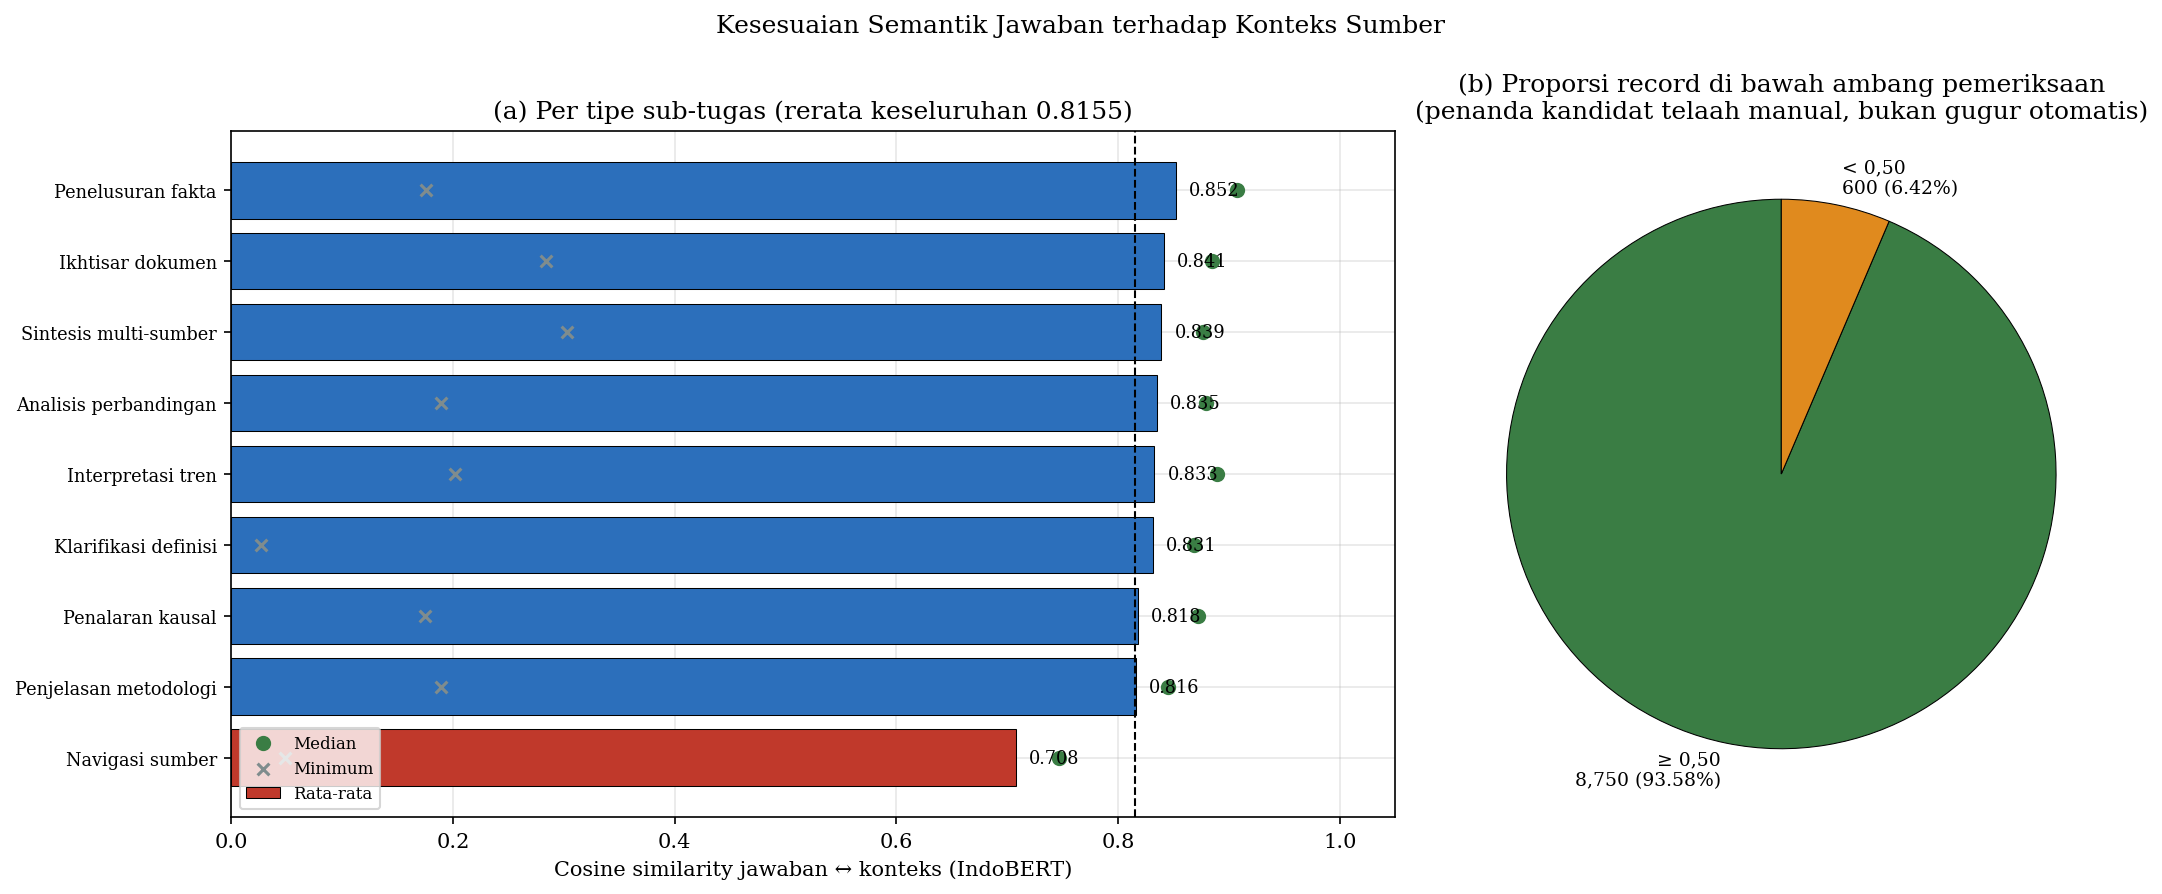

In [252]:
def fig23_similarity_semantik():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1.6, 1]})

    ax = axes[0]
    d = SIMILARITY_SUBTASK.sort_values("mean")
    y = np.arange(len(d))
    warna = [C_DROP if v < .75 else C_CLEAN for v in d["mean"]]
    ax.barh(y, d["mean"], color=warna, edgecolor="black", linewidth=.5, label="Rata-rata")
    ax.scatter(d["median"], y, color=C_KEEP, s=40, zorder=3, marker="o", label="Median")
    ax.scatter(d["min"], y, color=C_MUTED, s=32, zorder=3, marker="x", label="Minimum")
    for yi, v in zip(y, d["mean"]):
        ax.text(v + .012, yi, f"{v:.3f}", va="center", fontsize=8.5)
    ax.axvline(SIMILARITY_OVERALL["mean"], ls="--", color="black", lw=1)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL[k] for k in d.index], fontsize=8.5)
    ax.set_xlim(0, 1.05); ax.set_xlabel("Cosine similarity jawaban ↔ konteks (IndoBERT)")
    ax.set_title(f"(a) Per tipe sub-tugas (rerata keseluruhan {SIMILARITY_OVERALL['mean']:.4f})")
    ax.legend(fontsize=8, loc="lower left")

    ax = axes[1]
    rendah = SIMILARITY_OVERALL["di_bawah_0.5"]
    tinggi = SIMILARITY_OVERALL["n"] - rendah
    ax.pie([tinggi, rendah],
           labels=[f"≥ 0,50\n{tinggi:,} ({100 * tinggi / SIMILARITY_OVERALL['n']:.2f}%)",
                   f"< 0,50\n{rendah:,} ({100 * rendah / SIMILARITY_OVERALL['n']:.2f}%)"],
           colors=[C_KEEP, C_ACCENT], startangle=90,
           wedgeprops={"edgecolor": "black", "linewidth": .5}, textprops={"fontsize": 9})
    ax.set_title("(b) Proporsi record di bawah ambang pemeriksaan\n"
                 "(penanda kandidat telaah manual, bukan gugur otomatis)")
    ax.grid(False)

    fig.suptitle("Kesesuaian Semantik Jawaban terhadap Konteks Sumber", y=1.02)
    plt.tight_layout(); plt.savefig("fig23_similarity_semantik.png", bbox_inches="tight"); plt.show()

fig23_similarity_semantik()

### Gambar 24 — Dataset final: pembagian train/val/test tingkat section

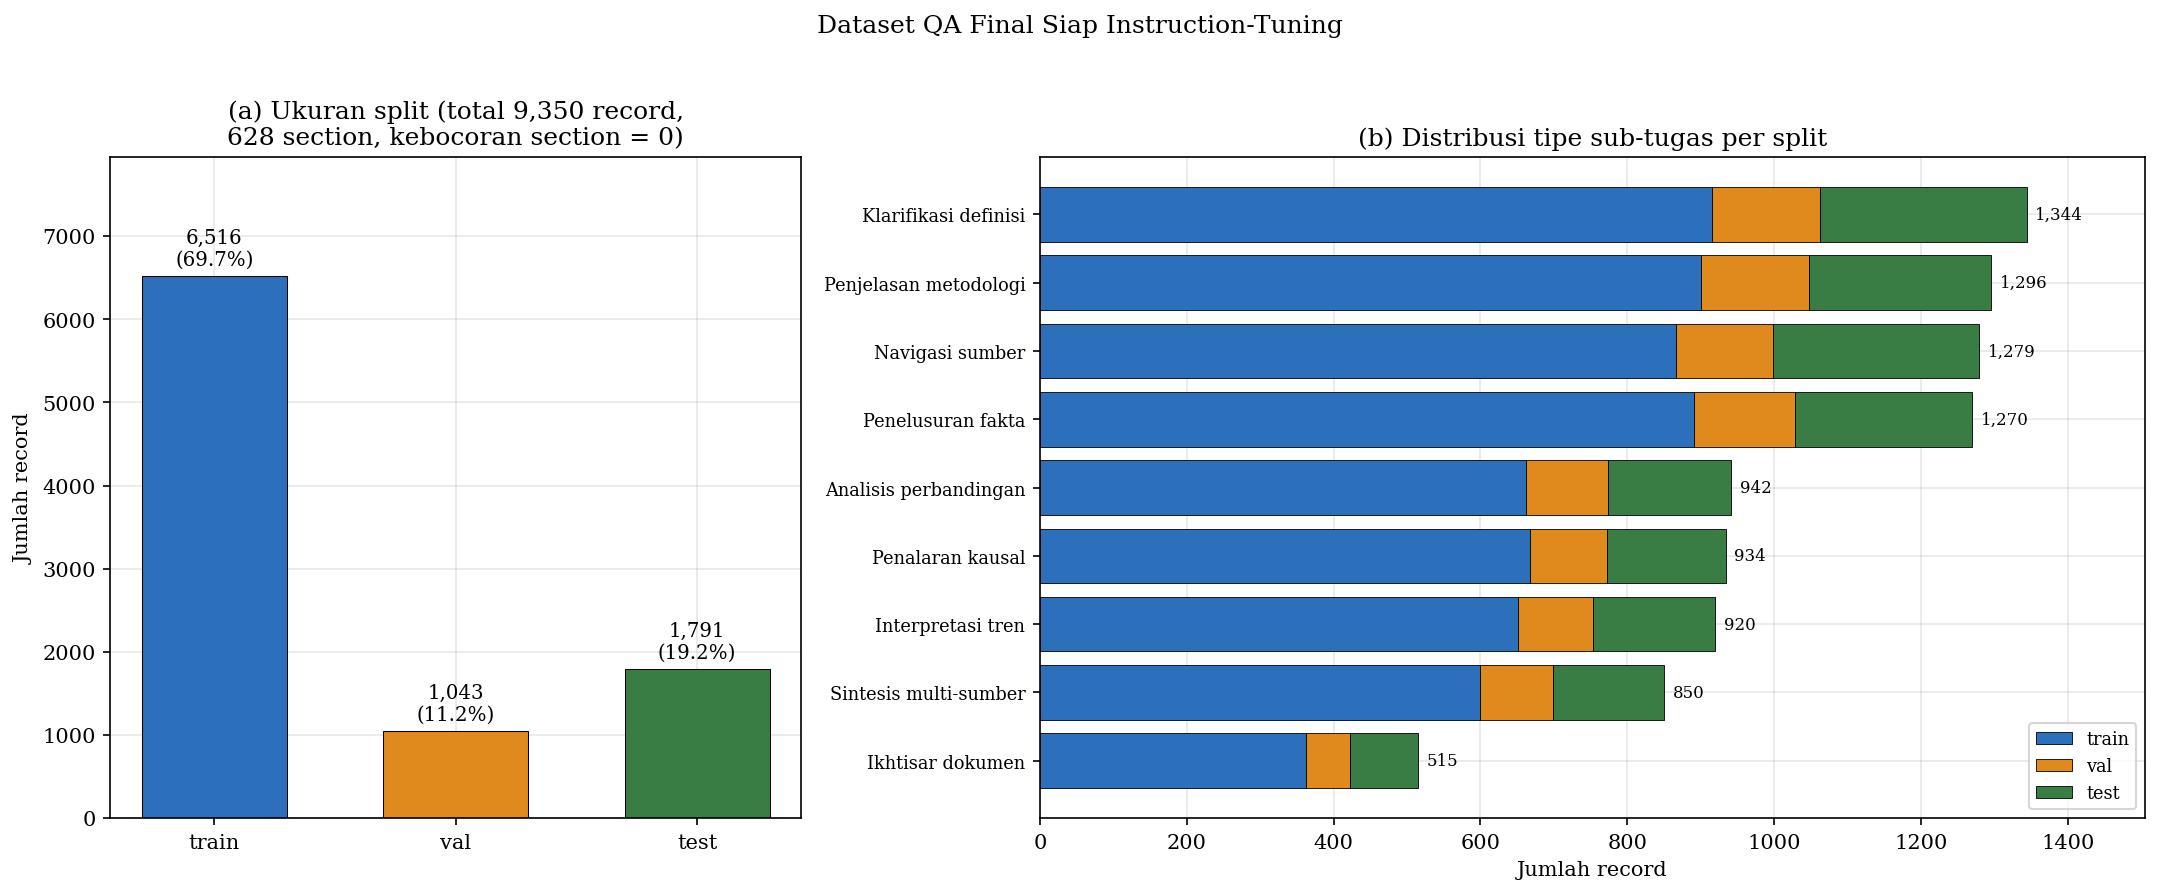

In [253]:
def fig24_dataset_final():
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), gridspec_kw={"width_ratios": [1, 1.6]})

    ax = axes[0]
    nama = list(SPLIT_COUNTS.keys()); nilai = list(SPLIT_COUNTS.values())
    total = sum(nilai)
    ax.bar(nama, nilai, color=[C_CLEAN, C_ACCENT, C_KEEP], edgecolor="black", linewidth=.5, width=.6)
    for i, v in enumerate(nilai):
        ax.text(i, v + total * .015, f"{v:,}\n({100 * v / total:.1f}%)", ha="center", fontsize=9.5)
    ax.set_ylabel("Jumlah record"); ax.set_ylim(0, max(nilai) * 1.22)
    ax.set_title(f"(a) Ukuran split (total {total:,} record,\n{N_SECTION_FINAL} section, "
                 f"kebocoran section = {N_SECTION_BOCOR})")

    ax = axes[1]
    d = SUBTASK_BY_SPLIT.loc[SUBTASK_BY_SPLIT.sum(axis=1).sort_values().index]
    y = np.arange(len(d)); kiri = np.zeros(len(d))
    for kol, warna in [("train", C_CLEAN), ("val", C_ACCENT), ("test", C_KEEP)]:
        ax.barh(y, d[kol], left=kiri, color=warna, edgecolor="black", linewidth=.4, label=kol)
        kiri += d[kol].values
    for yi, v in enumerate(kiri):
        ax.text(v + 12, yi, f"{int(v):,}", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL[k] for k in d.index], fontsize=8.5)
    ax.set_xlabel("Jumlah record"); ax.set_xlim(0, kiri.max() * 1.12)
    ax.set_title("(b) Distribusi tipe sub-tugas per split"); ax.legend(fontsize=8.5, loc="lower right")

    fig.suptitle("Dataset QA Final Siap Instruction-Tuning", y=1.02)
    plt.tight_layout(); plt.savefig("fig24_dataset_final.png", bbox_inches="tight"); plt.show()

fig24_dataset_final()

### Gambar 25 — Basis pengetahuan vektor

Konfigurasi indeks dibaca dari `index_manifest.json` dan komposisi vektor diturunkan dari laporan
chunking. Uji kueri tidak ditampilkan karena skornya tidak disimpan sebagai artefak hasil.


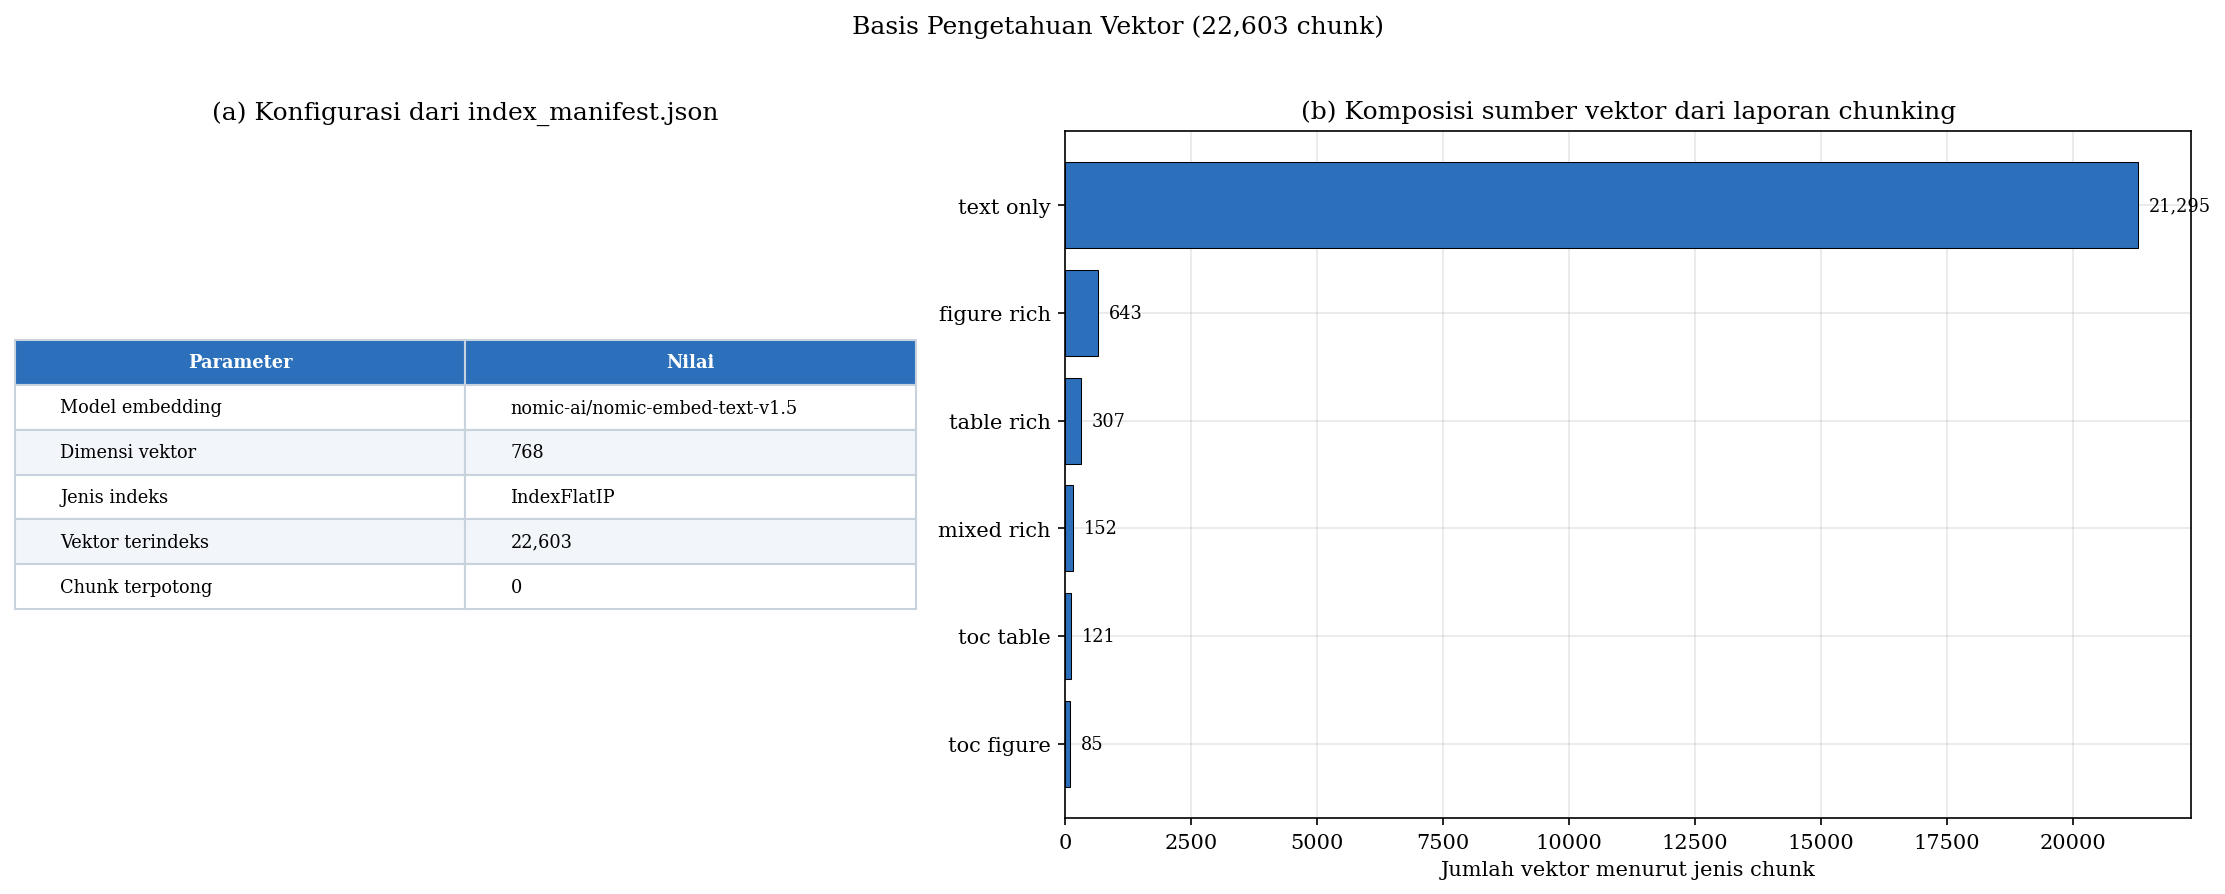

In [254]:
def fig25_basis_pengetahuan():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), gridspec_kw={"width_ratios": [1, 1.25]})
    ax = axes[0]
    ax.axis("off"); ax.grid(False)
    isi = [["Model embedding", EMBED_MODEL], ["Dimensi vektor", f"{EMBED_DIM}"],
           ["Jenis indeks", FAISS_INDEX], ["Vektor terindeks", f"{N_VEKTOR:,}"],
           ["Chunk terpotong", f"{N_TERPOTONG}"]]
    tabel = ax.table(cellText=isi, colLabels=["Parameter", "Nilai"], loc="center", cellLoc="left")
    tabel.auto_set_font_size(False); tabel.set_fontsize(8.5); tabel.scale(1, 1.75)
    for (baris, kolom), sel in tabel.get_celld().items():
        sel.set_edgecolor("#c8d2dc")
        if baris == 0: sel.set_facecolor(C_CLEAN); sel.set_text_props(color="white", fontweight="bold")
        elif baris % 2 == 0: sel.set_facecolor("#f2f6fa")
    ax.set_title("(a) Konfigurasi dari index_manifest.json")

    ax = axes[1]
    d = pd.Series(CHUNK_TYPE_DIST).sort_values()
    ax.barh([k.replace("_", " ") for k in d.index], d.values, color=C_CLEAN, edgecolor="black", linewidth=.5)
    for y, v in enumerate(d.values): ax.text(v + d.max() * .01, y, f"{v:,}", va="center", fontsize=8.5)
    ax.set_xlabel("Jumlah vektor menurut jenis chunk")
    ax.set_title("(b) Komposisi sumber vektor dari laporan chunking")

    fig.suptitle(f"Basis Pengetahuan Vektor ({N_VEKTOR:,} chunk)", y=1.02)
    plt.tight_layout(); plt.savefig("fig25_basis_pengetahuan.png", bbox_inches="tight"); plt.show()

fig25_basis_pengetahuan()


### Gambar 26 — Karakteristik dataset final dari berkas `train/val/test.csv` *(opsional)*
Grafik ini menghitung ulang distribusi langsung dari berkas dataset final, sehingga memberi resolusi penuh (bukan ringkasan) atas skor kualitas, panjang konteks, dan cakupan dokumen. Lewati jika berkas belum diunduh.

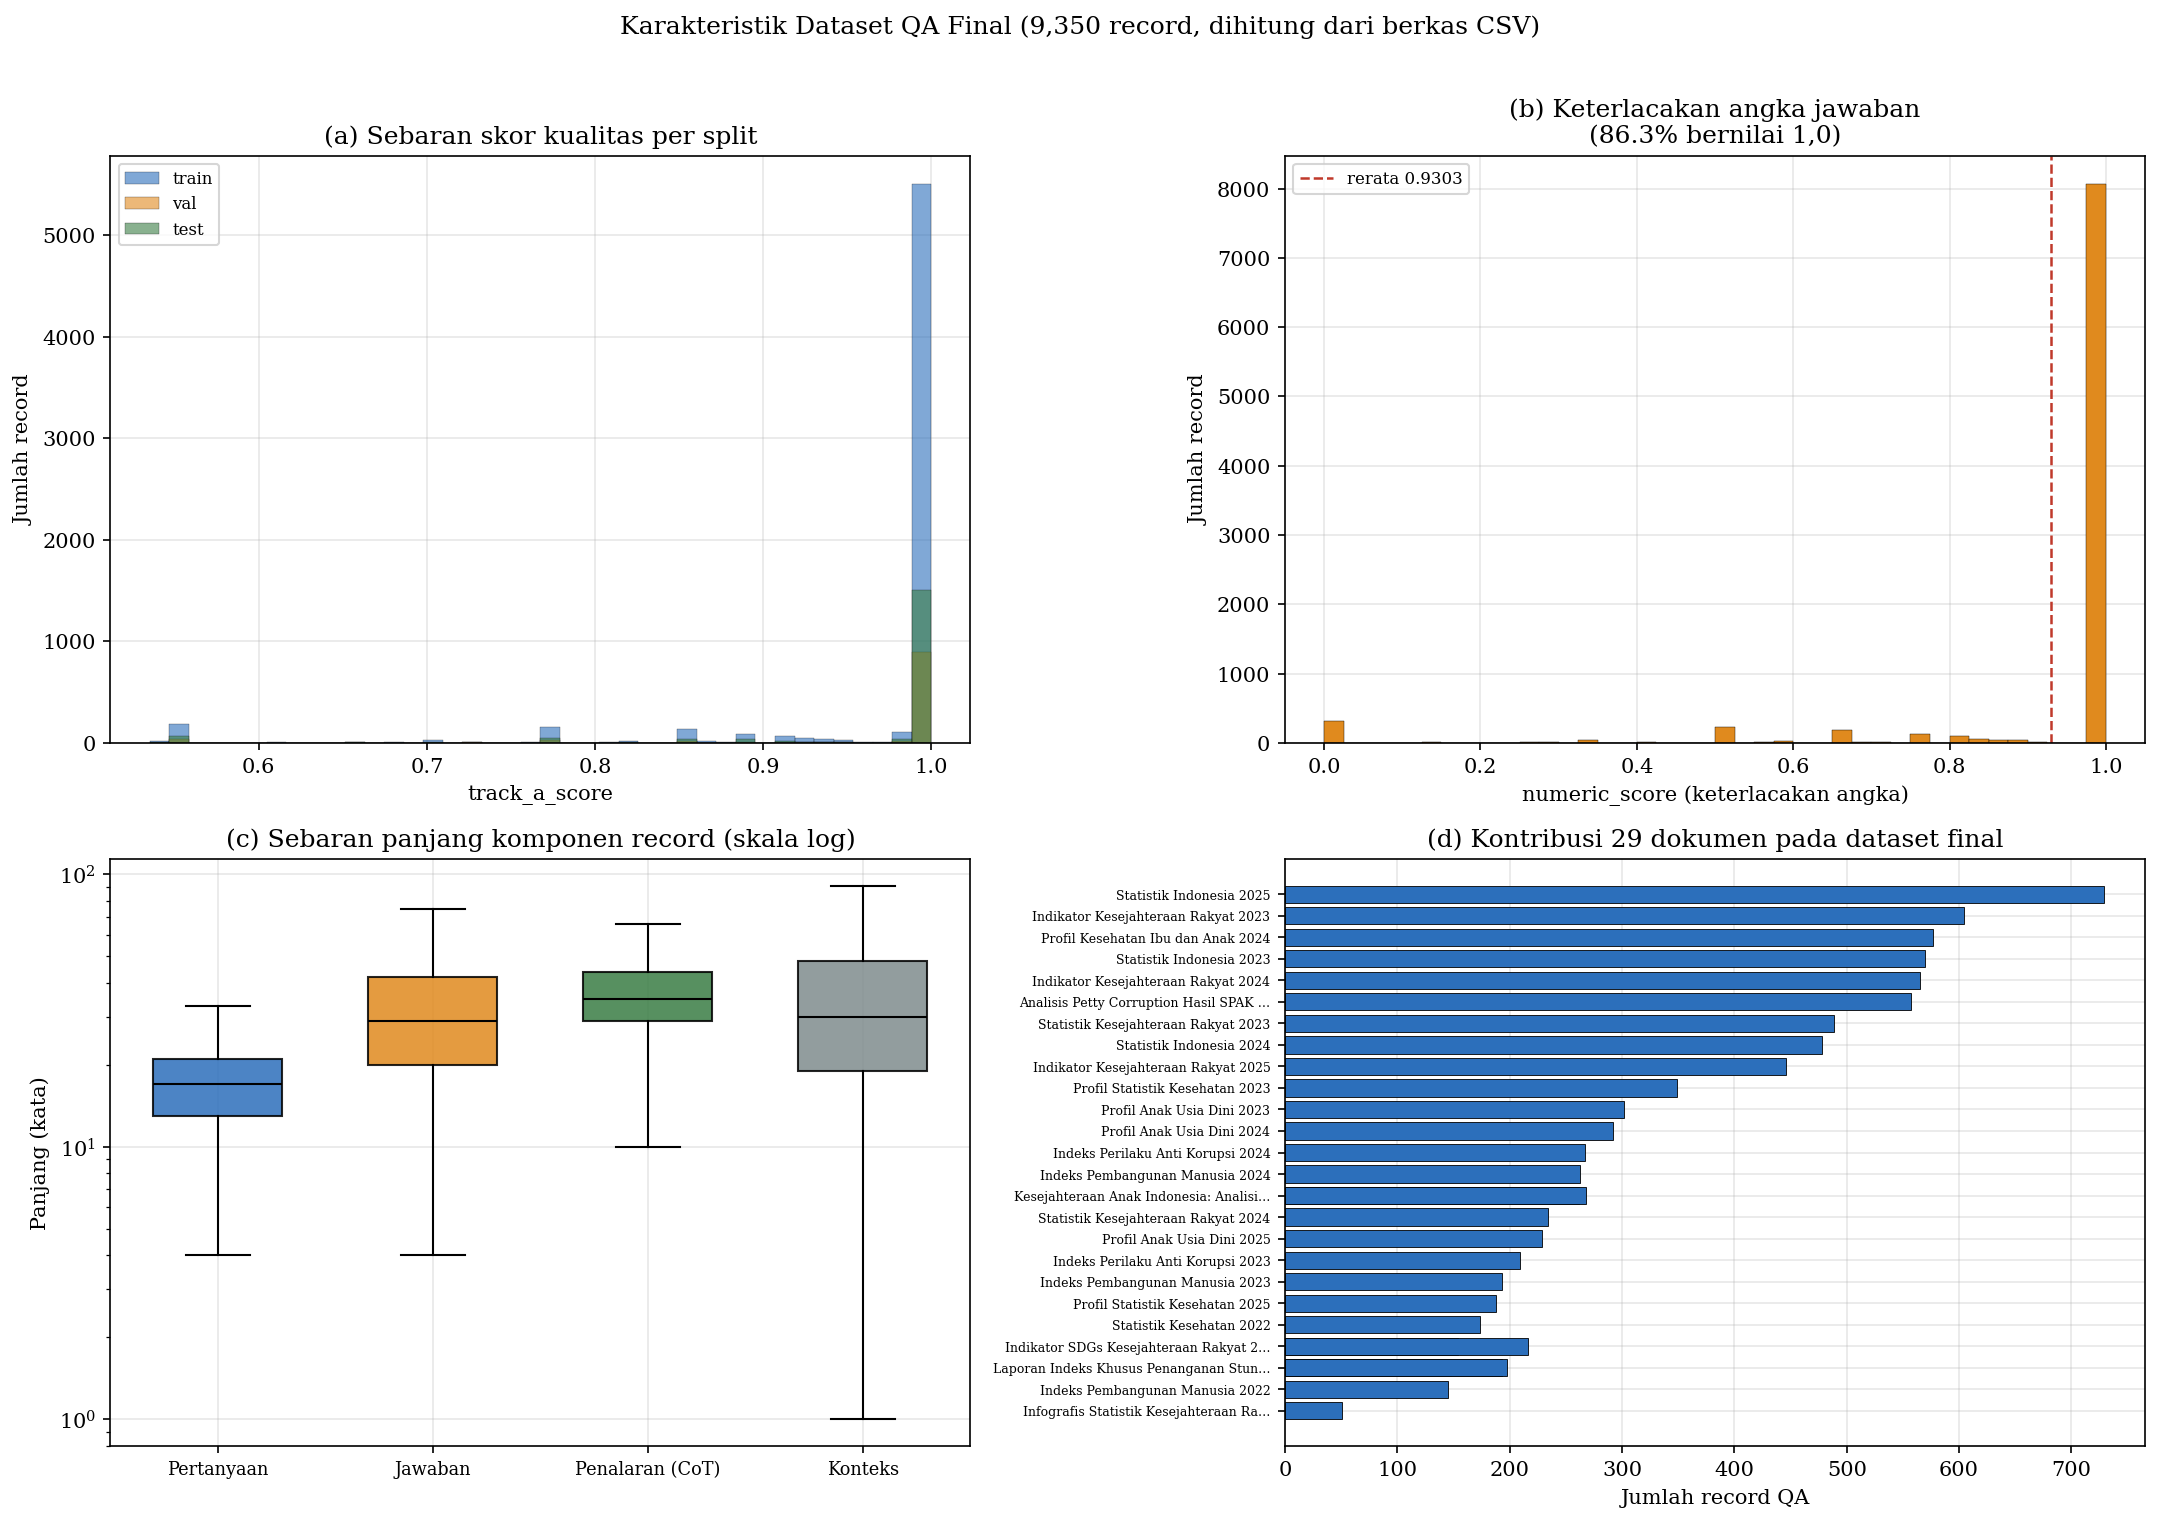

In [255]:
def fig26_karakteristik_dataset_csv():
    berkas = [hasil_t2(nama) for nama in ["train.csv", "val.csv", "test.csv"]]
    if not ada(*berkas):
        lewati("train.csv / val.csv / test.csv belum tersedia di direktori notebook.")
        return
    df = pd.concat([pd.read_csv(f).assign(split=f.stem) for f in berkas], ignore_index=True)

    fig, axes = plt.subplots(2, 2, figsize=(14.5, 10))

    ax = axes[0, 0]
    for split, warna in [("train", C_CLEAN), ("val", C_ACCENT), ("test", C_KEEP)]:
        ax.hist(df[df["split"] == split]["track_a_score"], bins=40, alpha=.6,
                color=warna, edgecolor="black", linewidth=.2, label=split)
    ax.set_xlabel("track_a_score"); ax.set_ylabel("Jumlah record")
    ax.set_title("(a) Sebaran skor kualitas per split"); ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.hist(df["numeric_score"], bins=40, color=C_ACCENT, edgecolor="black", linewidth=.2)
    prop_sempurna = (df["numeric_score"] >= .999).mean()
    ax.axvline(df["numeric_score"].mean(), ls="--", color=C_DROP, lw=1.2,
               label=f"rerata {df['numeric_score'].mean():.4f}")
    ax.set_xlabel("numeric_score (keterlacakan angka)"); ax.set_ylabel("Jumlah record")
    ax.set_title(f"(b) Keterlacakan angka jawaban\n({100 * prop_sempurna:.1f}% bernilai 1,0)")
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    panjang = pd.DataFrame({
        "Pertanyaan": df["instruction"].astype(str).str.split().str.len(),
        "Jawaban": df["response"].astype(str).str.split().str.len(),
        "Penalaran (CoT)": df["cot"].astype(str).str.split().str.len(),
        "Konteks": df["context_joined"].astype(str).str.split().str.len(),
    })
    bp = ax.boxplot([panjang[k].dropna() for k in panjang.columns], patch_artist=True,
                    widths=.6, showfliers=False)
    for patch, warna in zip(bp["boxes"], [C_CLEAN, C_ACCENT, C_KEEP, C_MUTED]):
        patch.set_facecolor(warna); patch.set_alpha(.85)
    for med in bp["medians"]: med.set_color("black")
    ax.set_xticklabels(panjang.columns, fontsize=8.5)
    ax.set_ylabel("Panjang (kata)"); ax.set_yscale("log")
    ax.set_title("(c) Sebaran panjang komponen record (skala log)")

    ax = axes[1, 1]
    per_dok = df["document_title"].value_counts().sort_values()
    ax.barh([label_pendek(str(k), 38) for k in per_dok.index], per_dok.values,
            color=C_CLEAN, edgecolor="black", linewidth=.4)
    ax.set_xlabel("Jumlah record QA"); ax.tick_params(axis="y", labelsize=6)
    ax.set_title(f"(d) Kontribusi {len(per_dok)} dokumen pada dataset final")

    fig.suptitle(f"Karakteristik Dataset QA Final ({len(df):,} record, dihitung dari berkas CSV)", y=1.01)
    plt.tight_layout(); plt.savefig("fig26_karakteristik_dataset_csv.png", bbox_inches="tight"); plt.show()

fig26_karakteristik_dataset_csv()

---
# Bagian 4 — Modelling: Persiapan dan Instruction-Tuning

Bagian ini menggunakan `training_config.json`, `index_manifest.json`, serta ringkasan training
masing-masing model yang ditempatkan di `Hasil/tujuan2`.


In [256]:
print("Konfigurasi dan riwayat training dimuat dari artefak JSON pada Hasil/tujuan2.")
display(TOKEN_STATS)
display(TRAIN_META)


Konfigurasi dan riwayat training dimuat dari artefak JSON pada Hasil/tujuan2.


,max_seq_length,max_batch_size_ok
llama3.2,1536,2
gemma2,1024,4


,train_runtime_sec,lora_r,lora_alpha,lora_dropout,learning_rate,epochs,per_device_batch_size,gradient_accumulation_steps,effective_batch_size
gemma2,14399.5336,16.0,32.0,0.1,0.00002,3.0,4.0,4.0,16.0
llama3.2,20697.9127,16.0,32.0,0.1,0.00002,3.0,2.0,8.0,16.0


### Gambar 27 — Konfigurasi panjang urutan dan hasil pemindaian batch

Panjang maksimum, kandidat batch, dan estimasi VRAM dibaca dari `training_config.json`.


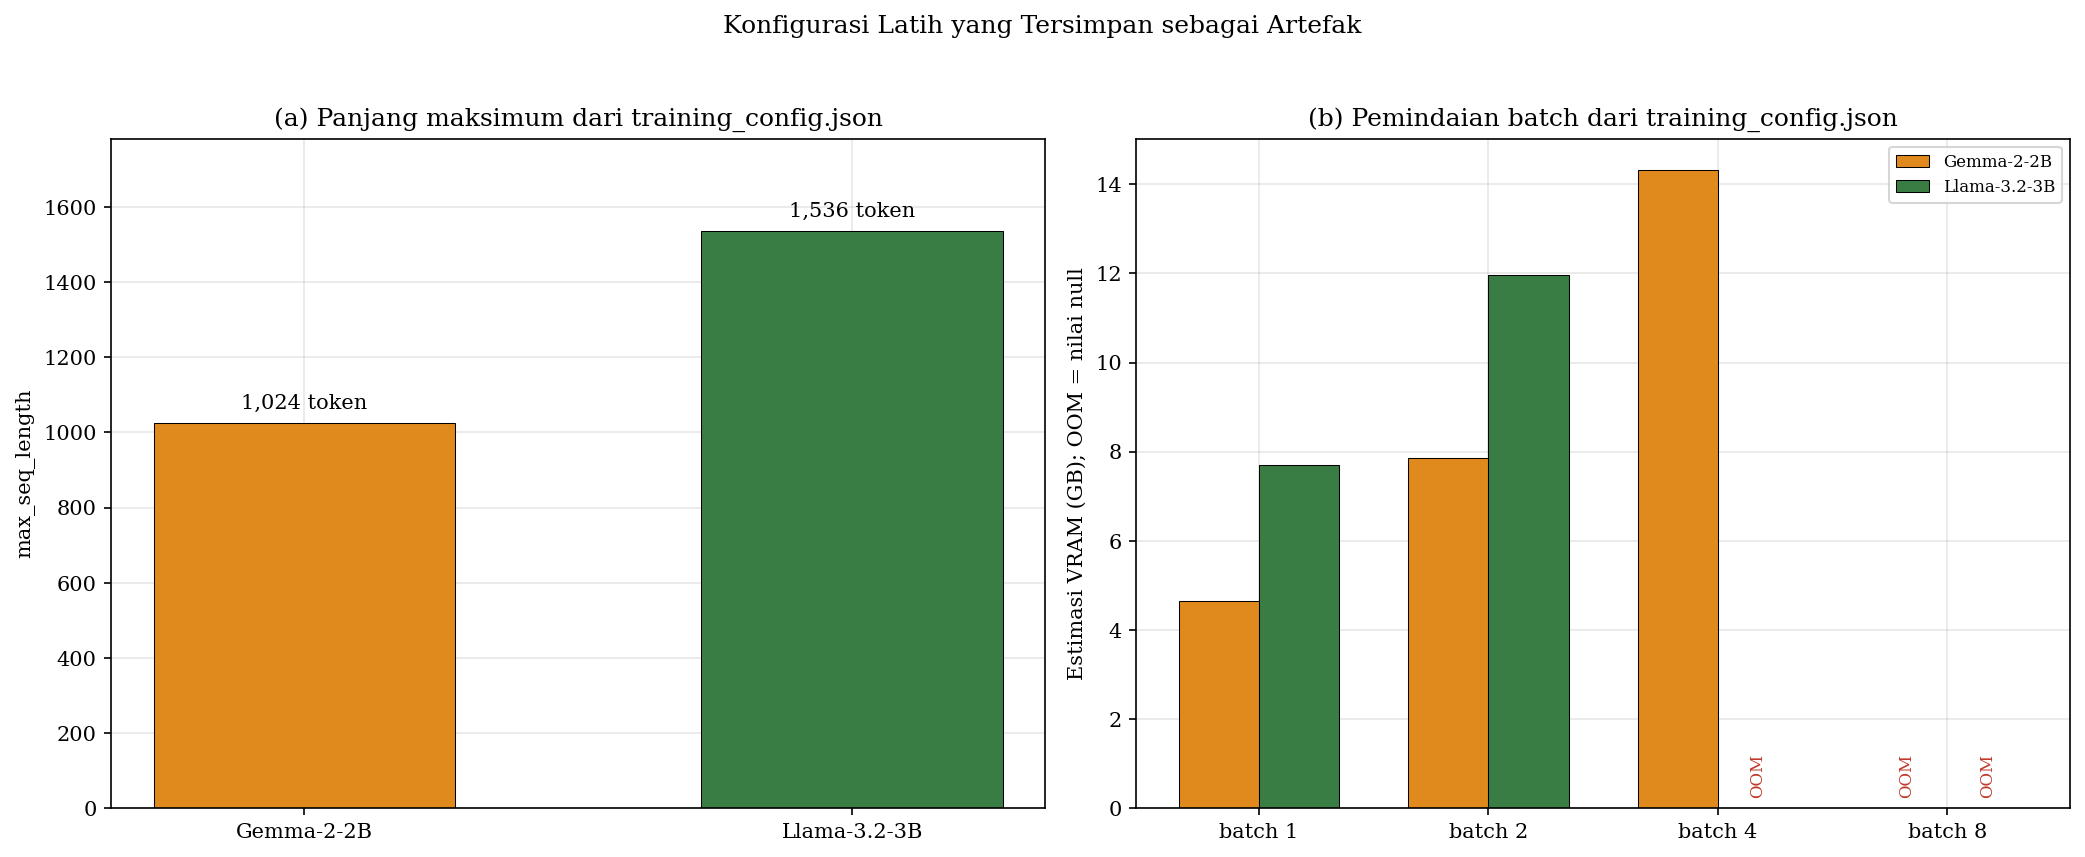

In [257]:
def fig27_panjang_token():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    labels = [MODEL_LABELS[m] for m in MODEL_KEYS]
    warna = [C_GEMMA, C_LLAMA]
    ax = axes[0]
    nilai = [TOKEN_STATS.loc[m, "max_seq_length"] for m in MODEL_KEYS]
    ax.bar(labels, nilai, color=warna, edgecolor="black", linewidth=.5, width=.55)
    for i, v in enumerate(nilai): ax.text(i, v + max(nilai) * .025, f"{int(v):,} token", ha="center")
    ax.set_ylabel("max_seq_length"); ax.set_ylim(0, max(nilai) * 1.16)
    ax.set_title("(a) Panjang maksimum dari training_config.json")

    ax = axes[1]
    for i, (mk, warna_m) in enumerate(zip(MODEL_KEYS, warna)):
        cfg = training_config[mk]["vram_estimate_gb"]
        vals = [cfg.get(str(b)) for b in BATCH_CANDIDATES]
        posisi = np.arange(len(BATCH_CANDIDATES)) + (i - .5) * .35
        ax.bar(posisi, [0 if v is None else v for v in vals], .35, color=warna_m,
               edgecolor="black", linewidth=.5, label=MODEL_LABELS[mk])
        for x, v in zip(posisi, vals):
            if v is None: ax.text(x, .25, "OOM", ha="center", va="bottom", rotation=90, fontsize=8, color=C_DROP)
    ax.set_xticks(np.arange(len(BATCH_CANDIDATES))); ax.set_xticklabels([f"batch {b}" for b in BATCH_CANDIDATES])
    ax.set_ylabel("Estimasi VRAM (GB); OOM = nilai null")
    ax.set_title("(b) Pemindaian batch dari training_config.json"); ax.legend(fontsize=8)

    fig.suptitle("Konfigurasi Latih yang Tersimpan sebagai Artefak", y=1.03)
    plt.tight_layout(); plt.savefig("fig27_panjang_token.png", bbox_inches="tight"); plt.show()

fig27_panjang_token()


### Gambar 28 — Estimasi kebutuhan VRAM per ukuran batch

Seluruh nilai berasal dari `training_config.json`; nilai `null` ditampilkan sebagai kegagalan/OOM.


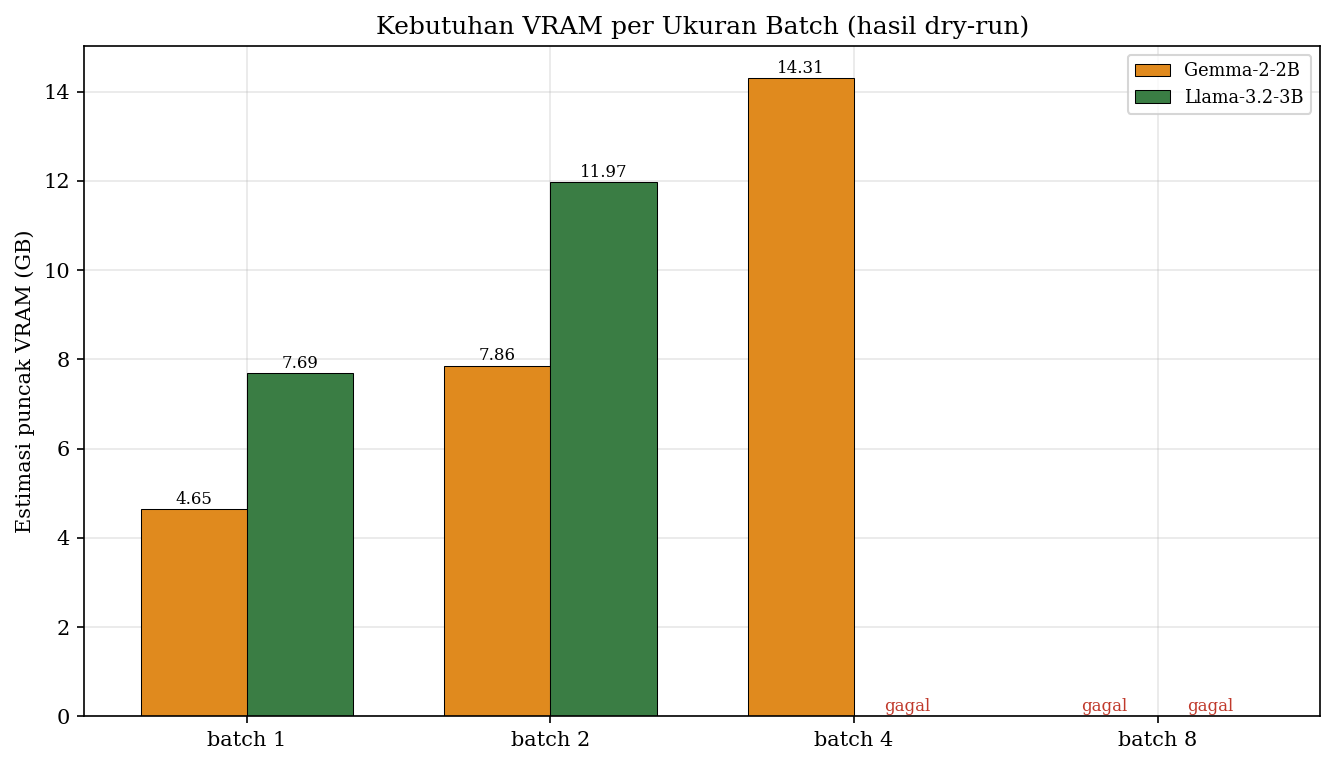

In [258]:
def fig28_vram():
    cfg_path = hasil_t2("training_config.json")
    if not ada(cfg_path):
        lewati("training_config.json belum tersedia — unduh dari HF repo untuk menampilkan estimasi VRAM.")
        return
    with cfg_path.open(encoding="utf-8") as f:
        cfg = json.load(f)

    baris = []
    for mk in MODEL_KEYS:
        est = (cfg.get(mk) or {}).get("vram_estimate_gb") or {}
        for bs, gb in est.items():
            baris.append({"model": mk, "batch_size": int(bs), "vram_gb": gb})
    if not baris:
        lewati("training_config.json tidak memuat kunci vram_estimate_gb.")
        return

    d = pd.DataFrame(baris)
    batch_list = sorted(d["batch_size"].unique())
    x = np.arange(len(batch_list)); w = .35
    fig, ax = plt.subplots(figsize=(9, 5.2))
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        sub = d[d["model"] == mk].set_index("batch_size").reindex(batch_list)
        nilai = [v if pd.notna(v) else 0 for v in sub["vram_gb"]]
        ax.bar(x + (i - .5) * w, nilai, w, color=warna, edgecolor="black",
               linewidth=.5, label=MODEL_LABELS[mk])
        for xi, (v, asli) in zip(x + (i - .5) * w, zip(nilai, sub["vram_gb"])):
            teks = f"{v:.2f}" if pd.notna(asli) else "gagal"
            ax.text(xi, v + .12, teks, ha="center", fontsize=8,
                    color="black" if pd.notna(asli) else C_DROP)
    ax.set_xticks(x); ax.set_xticklabels([f"batch {b}" for b in batch_list])
    ax.set_ylabel("Estimasi puncak VRAM (GB)")
    ax.set_title("Kebutuhan VRAM per Ukuran Batch (hasil dry-run)"); ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.savefig("fig28_vram.png", bbox_inches="tight"); plt.show()

fig28_vram()

### Gambar 29 — Kurva loss pelatihan dan validasi

Titik loss, langkah, dan jumlah epoch dibaca dari `*_training_summary.json`.


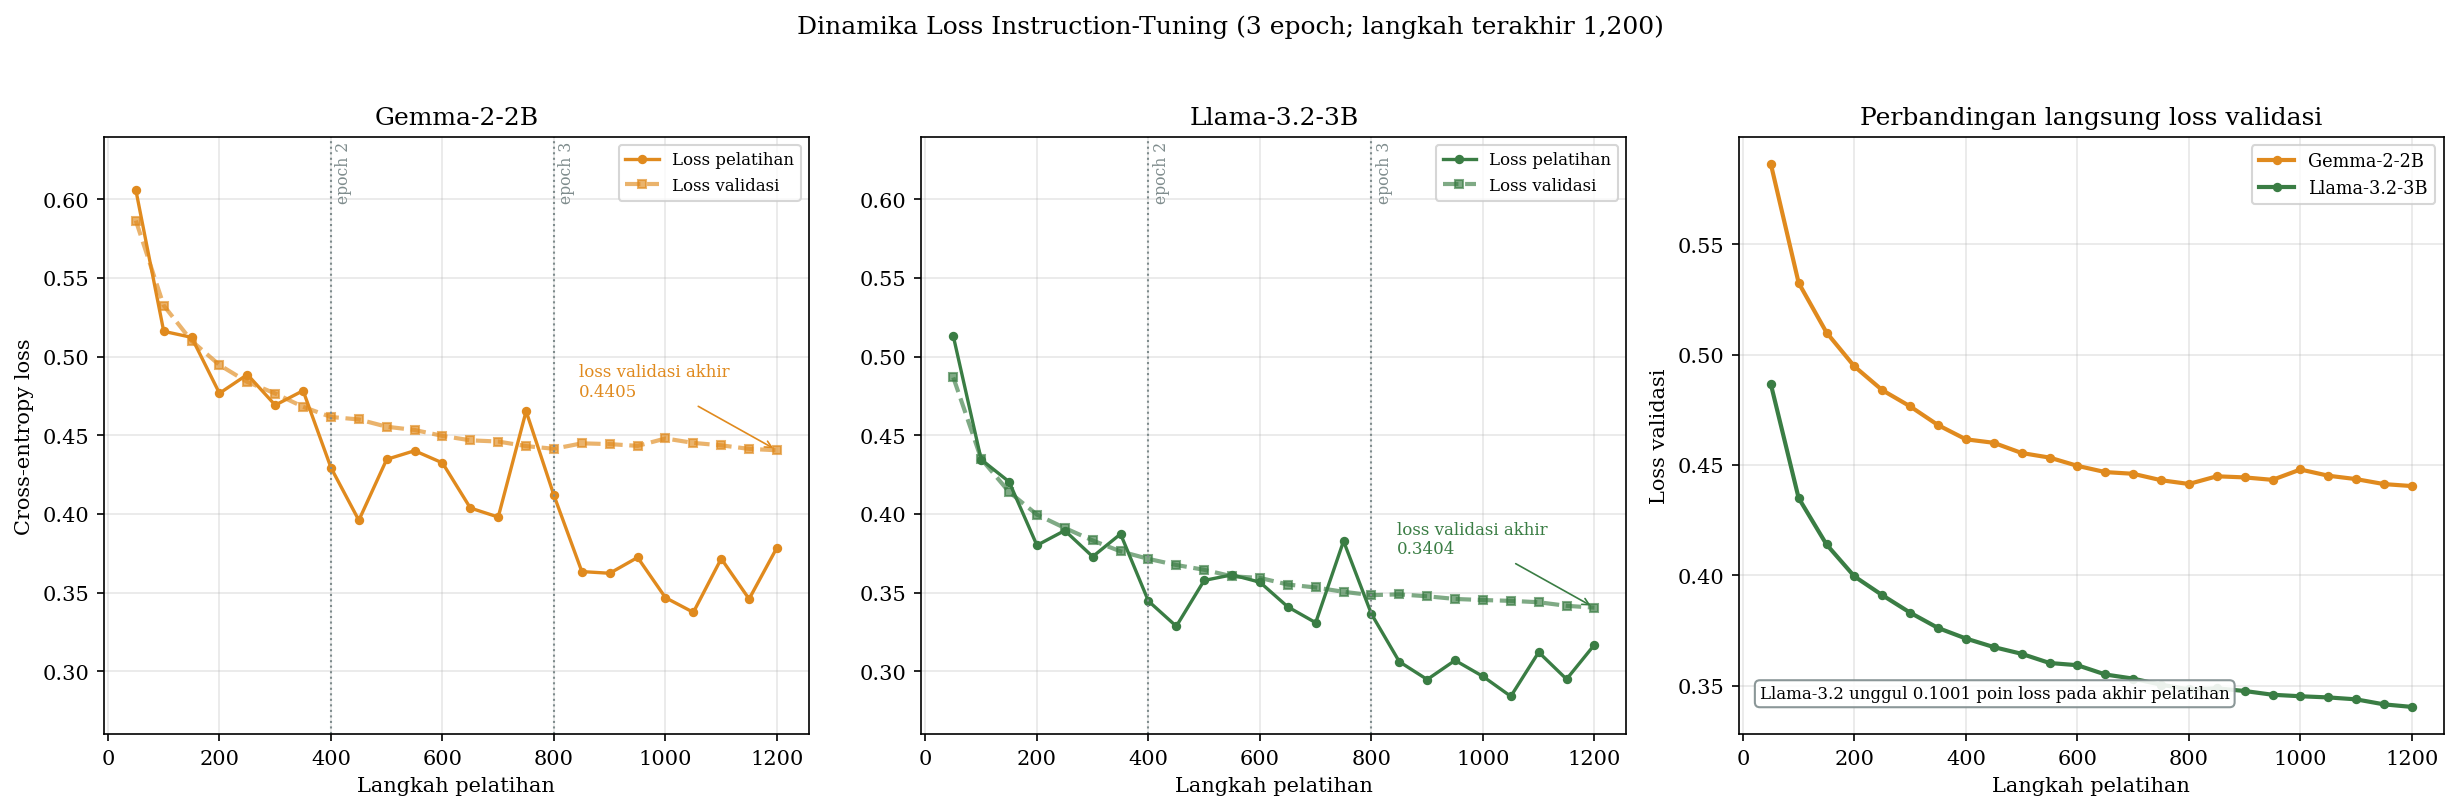

In [259]:
def fig29_kurva_loss():
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), gridspec_kw={"width_ratios": [1, 1, 1]})

    for ax, mk, warna in [(axes[0], "gemma2", C_GEMMA), (axes[1], "llama3.2", C_LLAMA)]:
        ax.plot(LOSS_STEPS, LOSS_HISTORY[mk]["train"], color=warna, lw=1.6, marker="o", ms=3.5,
                label="Loss pelatihan")
        ax.plot(LOSS_STEPS, LOSS_HISTORY[mk]["val"], color=warna, lw=2, ls="--", marker="s", ms=3.5,
                alpha=.65, label="Loss validasi")
        for e in range(1, int(round(epochs))):
            ax.axvline(e * STEP_PER_EPOCH, ls=":", color=C_MUTED, lw=1)
            ax.text(e * STEP_PER_EPOCH + 8, .60, f"epoch {e + 1}", fontsize=7.5, color=C_MUTED, rotation=90)
        akhir_val = LOSS_HISTORY[mk]["val"][-1]
        ax.annotate(f"loss validasi akhir\n{akhir_val:.4f}", xy=(LOSS_STEPS[-1], akhir_val),
                    xytext=(-95, 26), textcoords="offset points", fontsize=8, color=warna,
                    arrowprops=dict(arrowstyle="->", color=warna, lw=.8))
        ax.set_xlabel("Langkah pelatihan"); ax.set_ylim(.26, .64)
        ax.set_title(MODEL_LABELS[mk]); ax.legend(fontsize=8)
    axes[0].set_ylabel("Cross-entropy loss")

    ax = axes[2]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        ax.plot(LOSS_STEPS, LOSS_HISTORY[mk]["val"], color=warna, lw=2, marker="o", ms=3.5,
                label=f"{MODEL_LABELS[mk]}")
    ax.set_xlabel("Langkah pelatihan"); ax.set_ylabel("Loss validasi")
    ax.set_title("Perbandingan langsung loss validasi"); ax.legend(fontsize=8.5, loc="upper right")
    selisih = LOSS_HISTORY["gemma2"]["val"][-1] - LOSS_HISTORY["llama3.2"]["val"][-1]
    unggul = "Llama-3.2" if selisih > 0 else "Gemma-2"
    ax.text(.03, .06, f"{unggul} unggul {abs(selisih):.4f} poin loss pada akhir pelatihan",
            transform=ax.transAxes, ha="left", fontsize=8,
            bbox=dict(boxstyle="round,pad=.3", facecolor="white", edgecolor=C_MUTED, alpha=.9))

    fig.suptitle(f"Dinamika Loss Instruction-Tuning ({epochs:g} epoch; langkah terakhir {LOSS_STEPS[-1]:,})", y=1.03)
    plt.tight_layout(); plt.savefig("fig29_kurva_loss.png", bbox_inches="tight"); plt.show()

fig29_kurva_loss()

### Gambar 30 — Konvergensi dan indikasi overfitting
Panel (a) menunjukkan penurunan loss validasi relatif terhadap titik ukur pertama. Panel (b) memantau selisih loss validasi dikurangi loss pelatihan: nilai yang berubah dari negatif menjadi positif menandakan model mulai menghafal data latih, sehingga menjadi dasar pertimbangan untuk tidak menambah epoch.

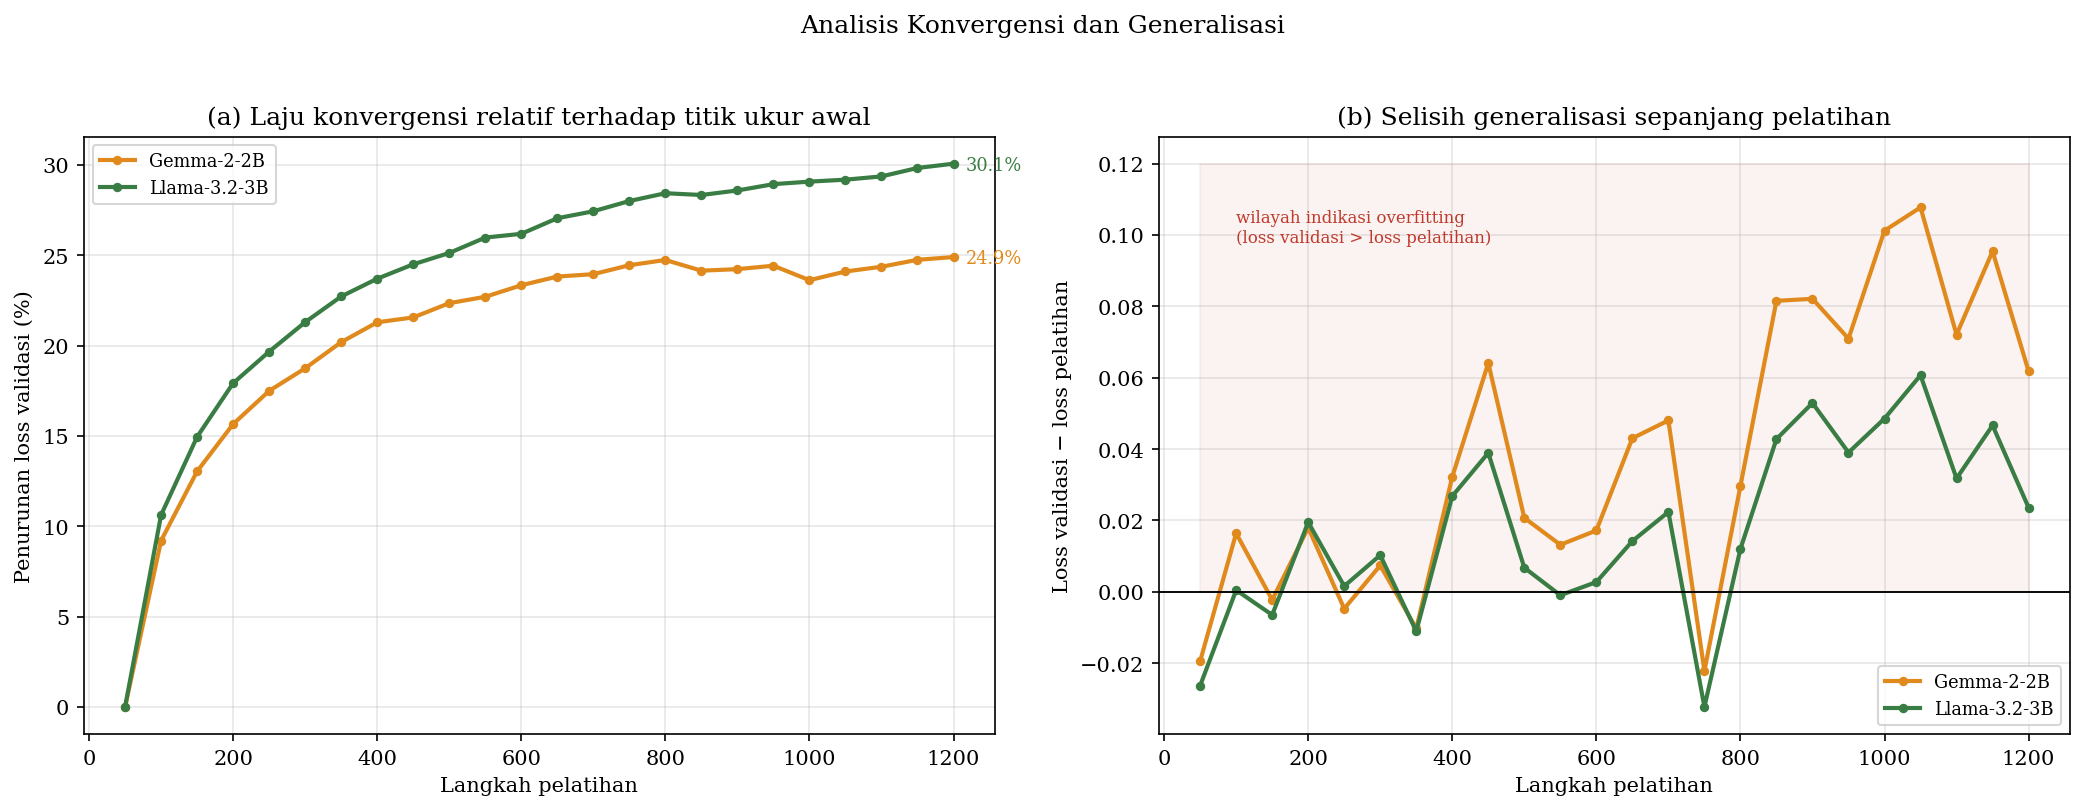

In [260]:
def fig30_konvergensi():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

    ax = axes[0]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        val = np.array(LOSS_HISTORY[mk]["val"])
        turun = 100 * (val[0] - val) / val[0]
        ax.plot(LOSS_STEPS, turun, color=warna, lw=2, marker="o", ms=3.5, label=MODEL_LABELS[mk])
        ax.annotate(f"{turun[-1]:.1f}%", xy=(LOSS_STEPS[-1], turun[-1]), xytext=(6, -3),
                    textcoords="offset points", fontsize=8.5, color=warna)
    ax.set_xlabel("Langkah pelatihan"); ax.set_ylabel("Penurunan loss validasi (%)")
    ax.set_title("(a) Laju konvergensi relatif terhadap titik ukur awal"); ax.legend(fontsize=8.5)

    ax = axes[1]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        gap = np.array(LOSS_HISTORY[mk]["val"]) - np.array(LOSS_HISTORY[mk]["train"])
        ax.plot(LOSS_STEPS, gap, color=warna, lw=2, marker="o", ms=3.5, label=MODEL_LABELS[mk])
    ax.axhline(0, color="black", lw=.9)
    ax.fill_between(LOSS_STEPS, 0, .12, color=C_DROP, alpha=.06)
    ax.text(LOSS_STEPS[1], .098, "wilayah indikasi overfitting\n(loss validasi > loss pelatihan)",
            fontsize=8, color=C_DROP)
    ax.set_xlabel("Langkah pelatihan"); ax.set_ylabel("Loss validasi − loss pelatihan")
    ax.set_title("(b) Selisih generalisasi sepanjang pelatihan"); ax.legend(fontsize=8.5, loc="lower right")

    fig.suptitle("Analisis Konvergensi dan Generalisasi", y=1.03)
    plt.tight_layout(); plt.savefig("fig30_konvergensi.png", bbox_inches="tight"); plt.show()

fig30_konvergensi()

### Gambar 31 — Durasi, konfigurasi batch, dan loss akhir training


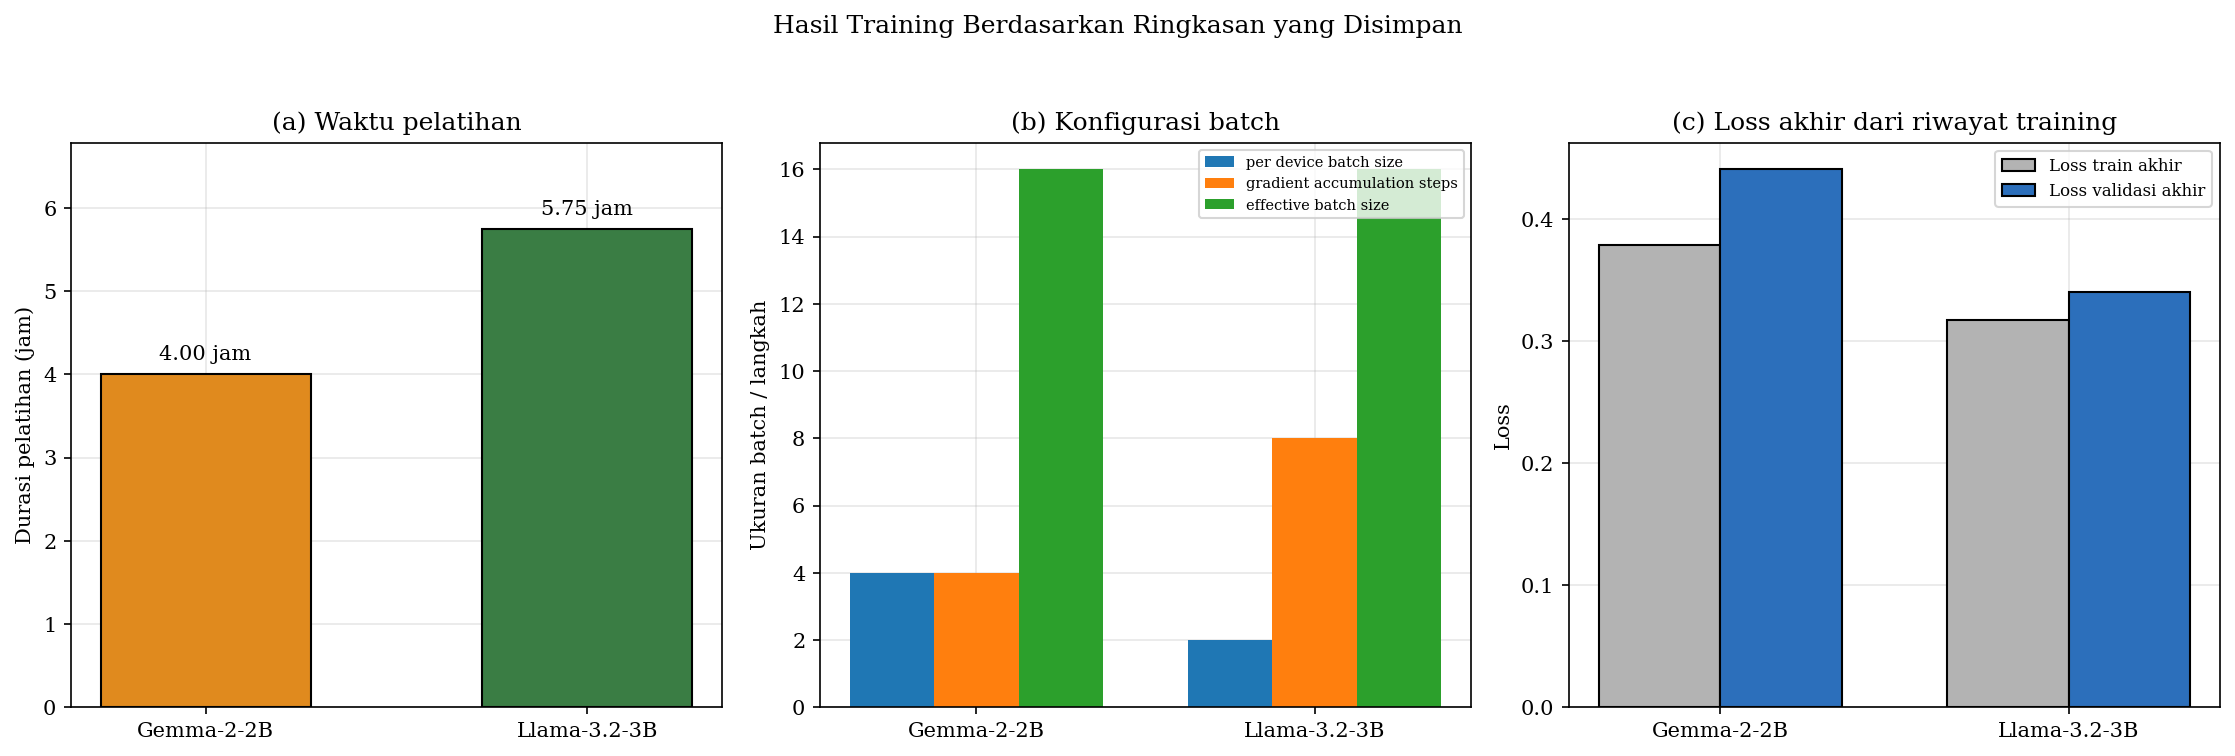

In [261]:
def fig31_efisiensi_training():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    warna = [C_GEMMA, C_LLAMA]
    label = [MODEL_LABELS[m] for m in MODEL_KEYS]
    ax = axes[0]
    jam = TRAIN_META.loc[MODEL_KEYS, "train_runtime_sec"].astype(float) / 3600
    ax.bar(label, jam, color=warna, edgecolor="black", width=.55)
    for i, v in enumerate(jam): ax.text(i, v + jam.max() * .03, f"{v:.2f} jam", ha="center")
    ax.set_ylabel("Durasi pelatihan (jam)"); ax.set_ylim(0, jam.max() * 1.18); ax.set_title("(a) Waktu pelatihan")

    ax = axes[1]
    x = np.arange(2); w = .25
    for j, kolom in enumerate(["per_device_batch_size", "gradient_accumulation_steps", "effective_batch_size"]):
        vals = TRAIN_META.loc[MODEL_KEYS, kolom].astype(float)
        ax.bar(x + (j - 1) * w, vals, w, label=kolom.replace("_", " "))
    ax.set_xticks(x); ax.set_xticklabels(label); ax.set_ylabel("Ukuran batch / langkah")
    ax.set_title("(b) Konfigurasi batch"); ax.legend(fontsize=7)

    ax = axes[2]
    x = np.arange(2); w = .35
    akhir_train = [LOSS_HISTORY[m]["train"][-1] for m in MODEL_KEYS]
    akhir_eval = [LOSS_HISTORY[m]["val"][-1] for m in MODEL_KEYS]
    ax.bar(x - w/2, akhir_train, w, color=C_BASE, edgecolor="black", label="Loss train akhir")
    ax.bar(x + w/2, akhir_eval, w, color=C_FT, edgecolor="black", label="Loss validasi akhir")
    ax.set_xticks(x); ax.set_xticklabels(label); ax.set_ylabel("Loss")
    ax.set_title("(c) Loss akhir dari riwayat training"); ax.legend(fontsize=8)

    fig.suptitle("Hasil Training Berdasarkan Ringkasan yang Disimpan", y=1.04)
    plt.tight_layout(); plt.savefig("fig31_efisiensi_training.png", bbox_inches="tight"); plt.show()

fig31_efisiensi_training()


### Gambar 32 — Hyperparameter QLoRA

Rank, alpha, dropout, learning rate, dan epoch dibaca dari ringkasan training tiap model.


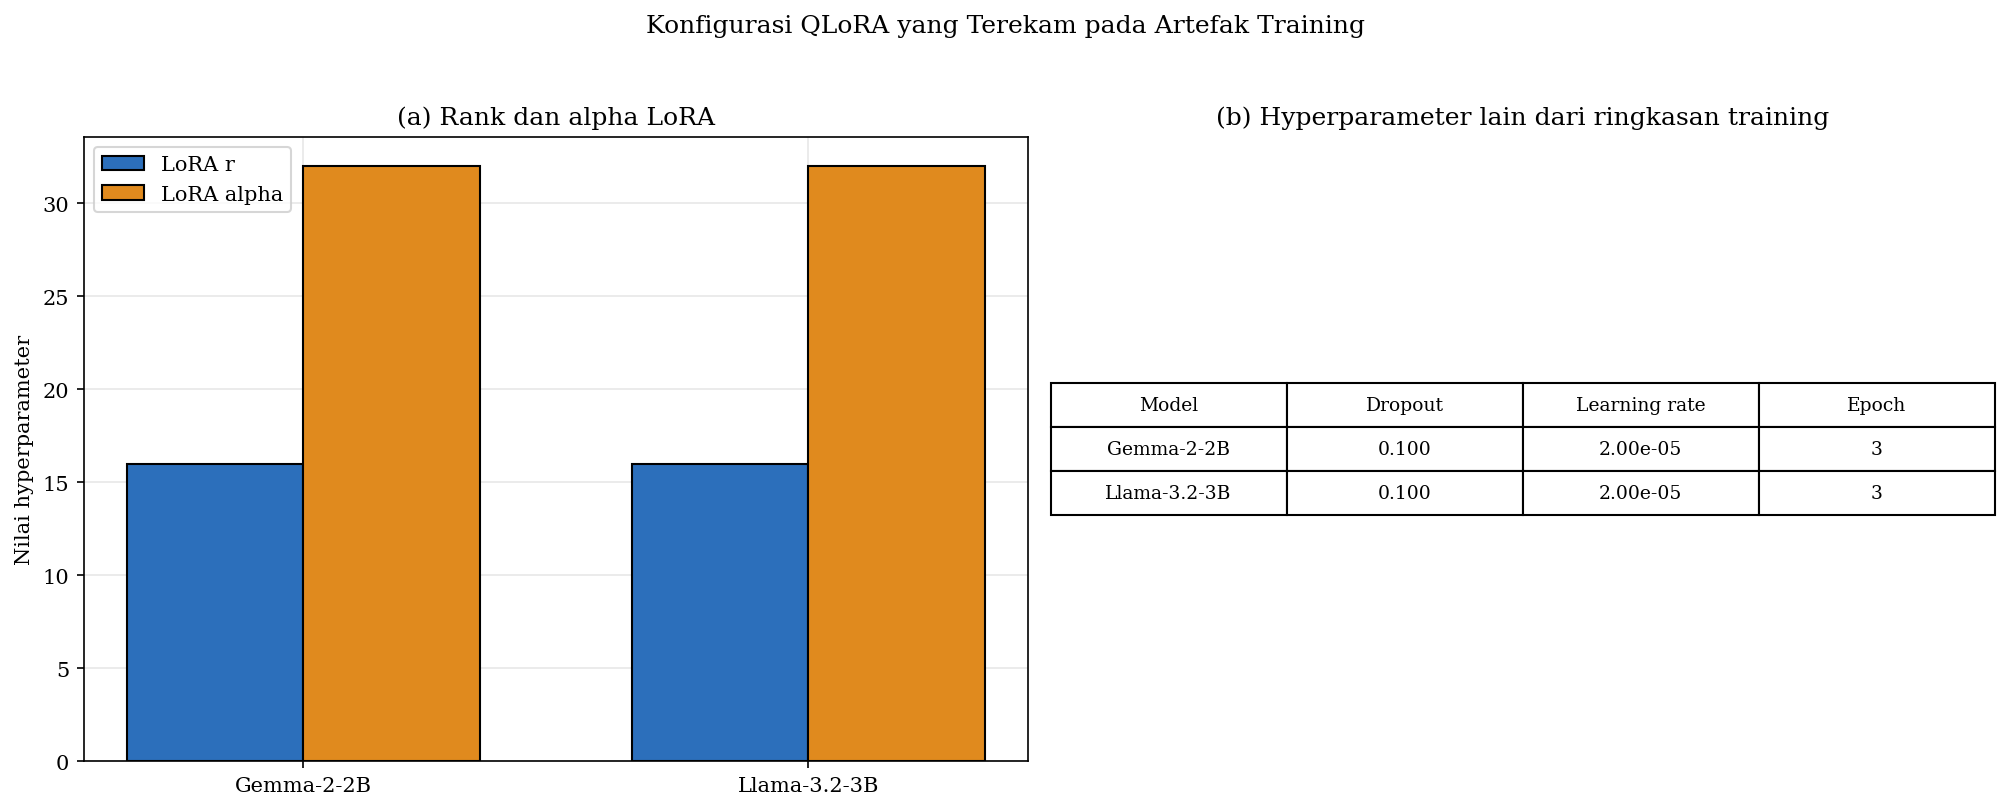

In [262]:
def fig32_efisiensi_parameter():
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
    x = np.arange(2); w = .35
    ax = axes[0]
    r = TRAIN_META.loc[MODEL_KEYS, "lora_r"].astype(float)
    alpha = TRAIN_META.loc[MODEL_KEYS, "lora_alpha"].astype(float)
    ax.bar(x - w/2, r, w, color=C_CLEAN, edgecolor="black", label="LoRA r")
    ax.bar(x + w/2, alpha, w, color=C_ACCENT, edgecolor="black", label="LoRA alpha")
    ax.set_xticks(x); ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_KEYS])
    ax.set_ylabel("Nilai hyperparameter"); ax.set_title("(a) Rank dan alpha LoRA"); ax.legend()

    ax = axes[1]
    drop = TRAIN_META.loc[MODEL_KEYS, "lora_dropout"].astype(float)
    lr = TRAIN_META.loc[MODEL_KEYS, "learning_rate"].astype(float)
    isi = [[MODEL_LABELS[m], f"{drop.loc[m]:.3f}", f"{lr.loc[m]:.2e}",
            f"{TRAIN_META.loc[m, 'epochs']:g}"] for m in MODEL_KEYS]
    ax.axis("off"); ax.grid(False)
    tabel = ax.table(cellText=isi, colLabels=["Model", "Dropout", "Learning rate", "Epoch"],
                     loc="center", cellLoc="center")
    tabel.auto_set_font_size(False); tabel.set_fontsize(9); tabel.scale(1, 1.7)
    ax.set_title("(b) Hyperparameter lain dari ringkasan training")

    fig.suptitle("Konfigurasi QLoRA yang Terekam pada Artefak Training", y=1.03)
    plt.tight_layout(); plt.savefig("fig32_efisiensi_parameter.png", bbox_inches="tight"); plt.show()

fig32_efisiensi_parameter()


### Gambar 33 — Waktu inferensi

Grafik ini dilewati karena durasi inferensi belum disimpan sebagai artefak di `Hasil/tujuan2`.


In [263]:
# Durasi inferensi tidak disimpan oleh notebook Tujuan 2 sebagai artefak hasil.
# Karena itu grafik waktu inferensi lama tidak dibuat ulang: menampilkannya akan memerlukan
# angka dari metadata notebook atau angka hardcoded, keduanya di luar kontrak notebook ini.
lewati("Gambar 33 tidak dibuat: belum ada artefak durasi inferensi di Hasil/tujuan2.")


[DILEWATI] Gambar 33 tidak dibuat: belum ada artefak durasi inferensi di Hasil/tujuan2.


### Gambar 34 — Perubahan gaya menjawab setelah instruction-tuning *(opsional)*
Dihitung langsung dari berkas prediksi. Grafik ini memperlihatkan salah satu efek instruction-tuning yang paling kasat mata: panjang dan format jawaban menjadi jauh lebih dekat dengan gaya jawaban referensi dibandingkan model base yang cenderung bertele-tele dan memakai penanda markdown.

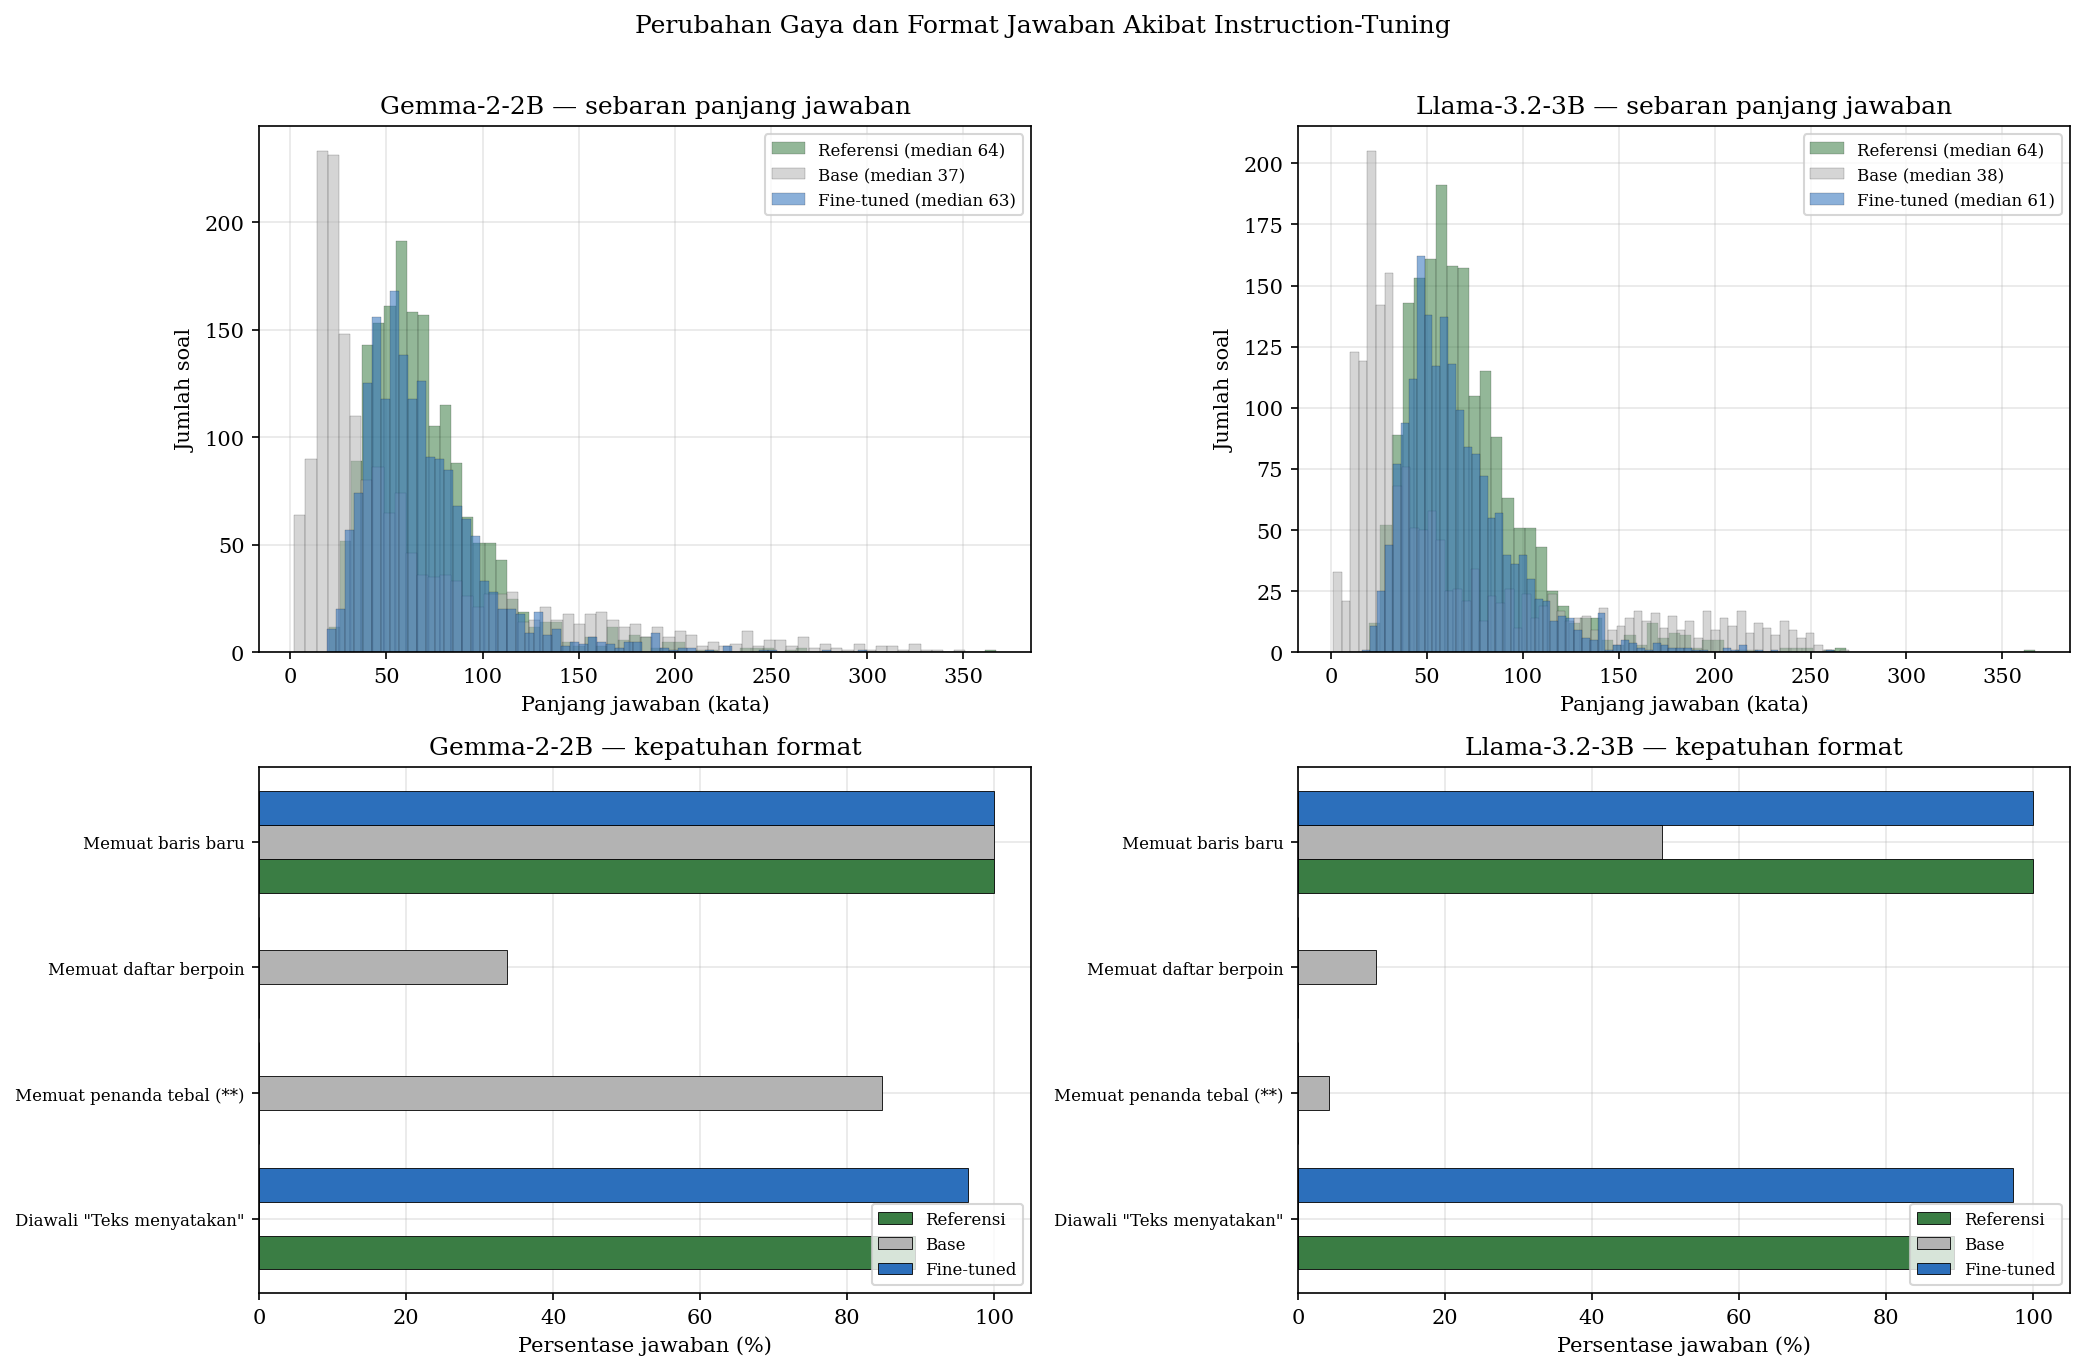

In [264]:
def fig34_gaya_jawaban():
    berkas = {mk: hasil_t2(f"eval_{mk}_predictions.csv") for mk in MODEL_KEYS}
    tersedia = {mk: f for mk, f in berkas.items() if os.path.exists(f)}
    if not tersedia:
        lewati("eval_gemma2_predictions.csv / eval_llama3.2_predictions.csv belum tersedia.")
        return

    fig, axes = plt.subplots(2, len(tersedia), figsize=(7 * len(tersedia), 9), squeeze=False)
    for j, (mk, berkas_mk) in enumerate(tersedia.items()):
        df = pd.read_csv(berkas_mk)
        panjang = {
            "Referensi": df["ans_ref"].astype(str).str.split().str.len(),
            "Base": df["ans_pred_base"].astype(str).str.split().str.len(),
            "Fine-tuned": df["ans_pred_finetuned"].astype(str).str.split().str.len(),
        }

        ax = axes[0, j]
        for nama, warna in [("Referensi", C_KEEP), ("Base", C_BASE), ("Fine-tuned", C_FT)]:
            ax.hist(panjang[nama], bins=60, alpha=.55, color=warna,
                    edgecolor="black", linewidth=.15, label=f"{nama} (median {panjang[nama].median():.0f})")
        ax.set_xlabel("Panjang jawaban (kata)"); ax.set_ylabel("Jumlah soal")
        ax.set_title(f"{MODEL_LABELS[mk]} — sebaran panjang jawaban"); ax.legend(fontsize=8)

        ax = axes[1, j]
        pola = {
            "Diawali \"Teks menyatakan\"": lambda s: s.str.strip().str.lower().str.startswith("teks menyatakan"),
            "Memuat penanda tebal (**)": lambda s: s.str.contains(r"\*\*", regex=True, na=False),
            "Memuat daftar berpoin": lambda s: s.str.contains(r"(?:^|\n)\s*[-*•]\s", regex=True, na=False),
            "Memuat baris baru": lambda s: s.str.contains("\n", na=False),
        }
        nama_pola = list(pola.keys())
        y = np.arange(len(nama_pola)); w = .27
        for i, (kol, nama, warna) in enumerate([("ans_ref", "Referensi", C_KEEP),
                                                ("ans_pred_base", "Base", C_BASE),
                                                ("ans_pred_finetuned", "Fine-tuned", C_FT)]):
            s = df[kol].astype(str)
            nilai = [100 * pola[p](s).mean() for p in nama_pola]
            ax.barh(y + (i - 1) * w, nilai, w, color=warna, edgecolor="black", linewidth=.4, label=nama)
        ax.set_yticks(y); ax.set_yticklabels(nama_pola, fontsize=8)
        ax.set_xlabel("Persentase jawaban (%)"); ax.set_xlim(0, 105)
        ax.set_title(f"{MODEL_LABELS[mk]} — kepatuhan format"); ax.legend(fontsize=8, loc="lower right")

    fig.suptitle("Perubahan Gaya dan Format Jawaban Akibat Instruction-Tuning", y=1.01)
    plt.tight_layout(); plt.savefig("fig34_gaya_jawaban.png", bbox_inches="tight"); plt.show()

fig34_gaya_jawaban()

---
# Bagian 5 — Evaluasi Otomatis

Jumlah soal dan seluruh metrik dihitung dari `test.csv`, `summary_metrics.csv`, dan berkas
`*_scored.csv` pada `Hasil/tujuan2`.


In [265]:
# Pemuatan berkas hasil evaluasi otomatis
BERKAS_SUMMARY = hasil_t2("summary_metrics.csv")
summary = pd.read_csv(BERKAS_SUMMARY).set_index("model") if ada(BERKAS_SUMMARY) else None
if summary is None:
    lewati(f"{BERKAS_SUMMARY} belum tersedia — seluruh Bagian 5 akan dilewati.")

scored = {}
for mk in MODEL_KEYS:
    for cond in CONDITIONS:
        f = hasil_t2(f"{mk}_{cond}_scored.csv")
        if os.path.exists(f):
            scored[(mk, cond)] = pd.read_csv(f)
ADA_SCORED = len(scored) == len(MODEL_KEYS) * len(CONDITIONS)
if not ADA_SCORED:
    lewati("Berkas *_scored.csv belum lengkap — grafik tingkat-soal akan dilewati.")

df_test = pd.read_csv(hasil_t2("test.csv")) if ada(hasil_t2("test.csv")) else None

def pasangan(model_key, metric):
    """Skor base dan fine-tuned yang dipasangkan berdasarkan record_id yang sama.
    Untuk EM (yang mengandung NaN pada soal non-numerik), baris NaN dibuang agar
    uji statistik berpasangan hanya mencakup soal yang terdefinisi."""
    a = scored[(model_key, "base")][["record_id", metric]].rename(columns={metric: "base"})
    b = scored[(model_key, "finetuned")][["record_id", metric]].rename(columns={metric: "finetuned"})
    merged = a.merge(b, on="record_id")
    return merged.dropna(subset=["base", "finetuned"]) if metric == "em" else merged

print(f"summary_metrics.csv: {'tersedia' if summary is not None else 'belum ada'} | "
      f"berkas skor tingkat-soal: {len(scored)}/4")

summary_metrics.csv: tersedia | berkas skor tingkat-soal: 4/4


### Gambar 35 — Ringkasan metrik otomatis: base versus fine-tuned

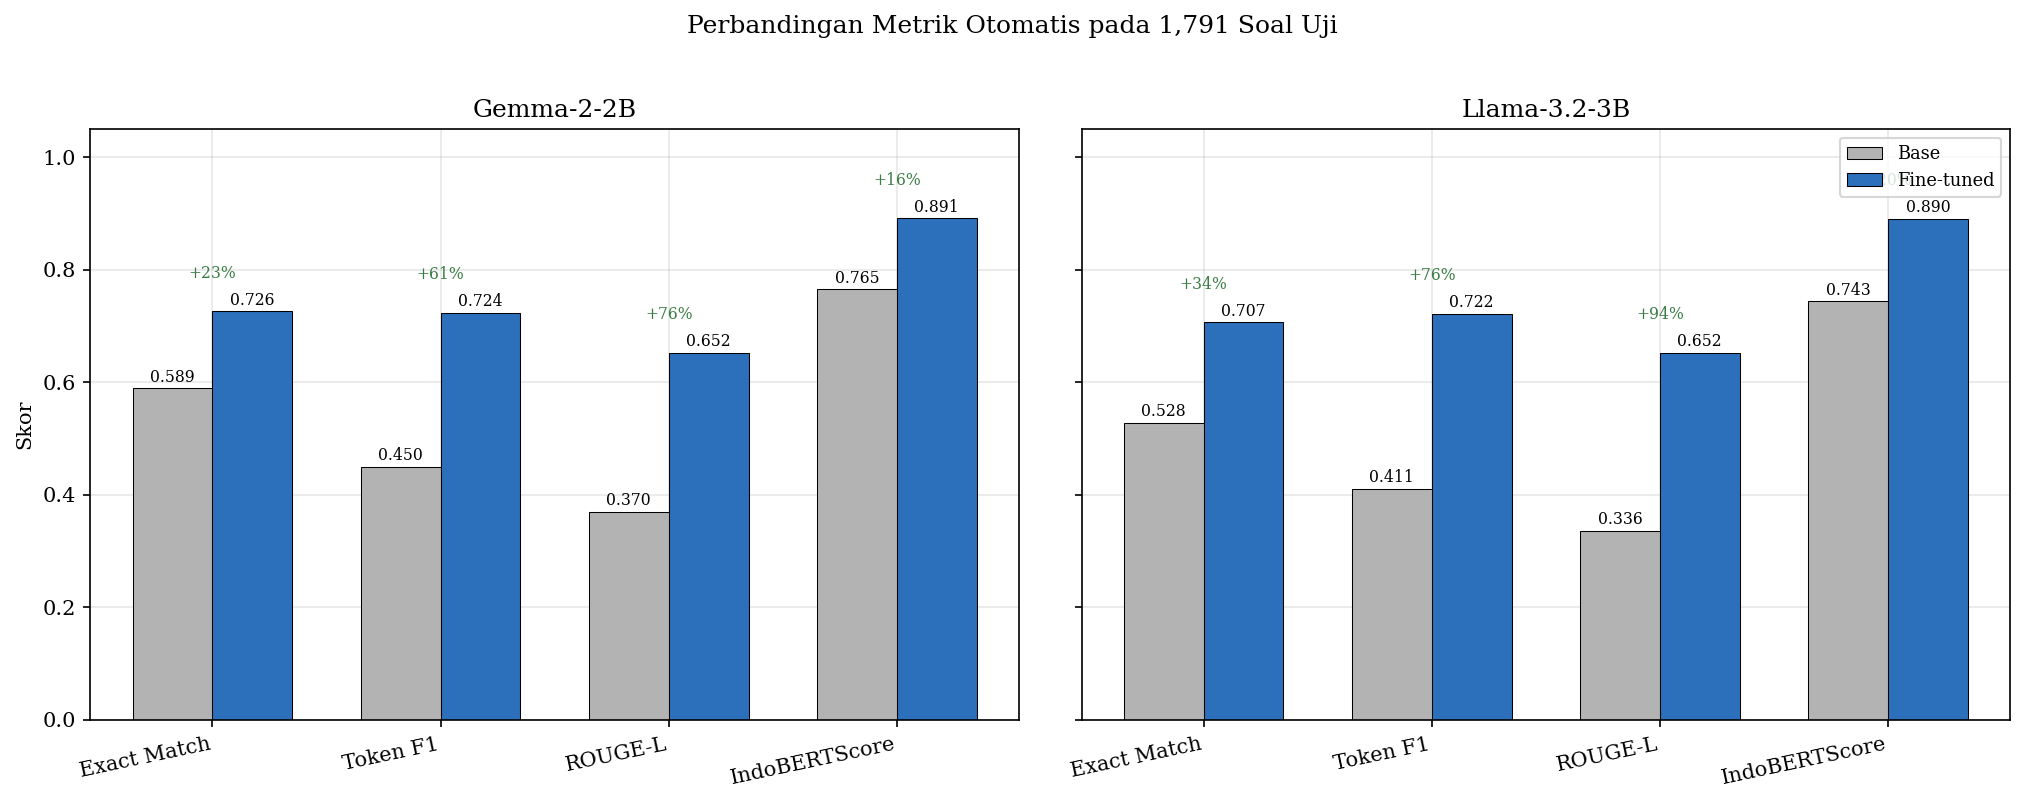

In [266]:
def fig35_ringkasan_metrik():
    if summary is None:
        lewati("summary_metrics.csv tidak tersedia."); return
    fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(6.8 * len(MODEL_KEYS), 5.2), sharey=True)
    x = np.arange(len(METRICS)); w = .35
    for ax, mk in zip(axes, MODEL_KEYS):
        base = [summary.loc[f"{mk}_base", m] for m in METRICS]
        ft = [summary.loc[f"{mk}_finetuned", m] for m in METRICS]
        ax.bar(x - w / 2, base, w, color=C_BASE, edgecolor="black", linewidth=.5, label="Base")
        ax.bar(x + w / 2, ft, w, color=C_FT, edgecolor="black", linewidth=.5, label="Fine-tuned")
        for xi, v in zip(x - w / 2, base): ax.text(xi, v + .012, f"{v:.3f}", ha="center", fontsize=7.5)
        for xi, v in zip(x + w / 2, ft): ax.text(xi, v + .012, f"{v:.3f}", ha="center", fontsize=7.5)
        for xi, (b, f_) in enumerate(zip(base, ft)):
            if b > 0:
                ax.annotate(f"+{100 * (f_ - b) / b:.0f}%", xy=(xi, max(b, f_) + .06),
                            ha="center", fontsize=7.5, color=C_KEEP)
        ax.set_xticks(x); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=12, ha="right")
        ax.set_title(MODEL_LABELS[mk]); ax.set_ylim(0, 1.05)
    axes[0].set_ylabel("Skor"); axes[-1].legend(fontsize=8.5, loc="upper right")
    fig.suptitle(f"Perbandingan Metrik Otomatis pada {N_TEST:,} Soal Uji", y=1.02)
    plt.tight_layout(); plt.savefig("fig35_ringkasan_metrik.png", bbox_inches="tight"); plt.show()

fig35_ringkasan_metrik()

### Gambar 36 — Besaran peningkatan akibat instruction-tuning

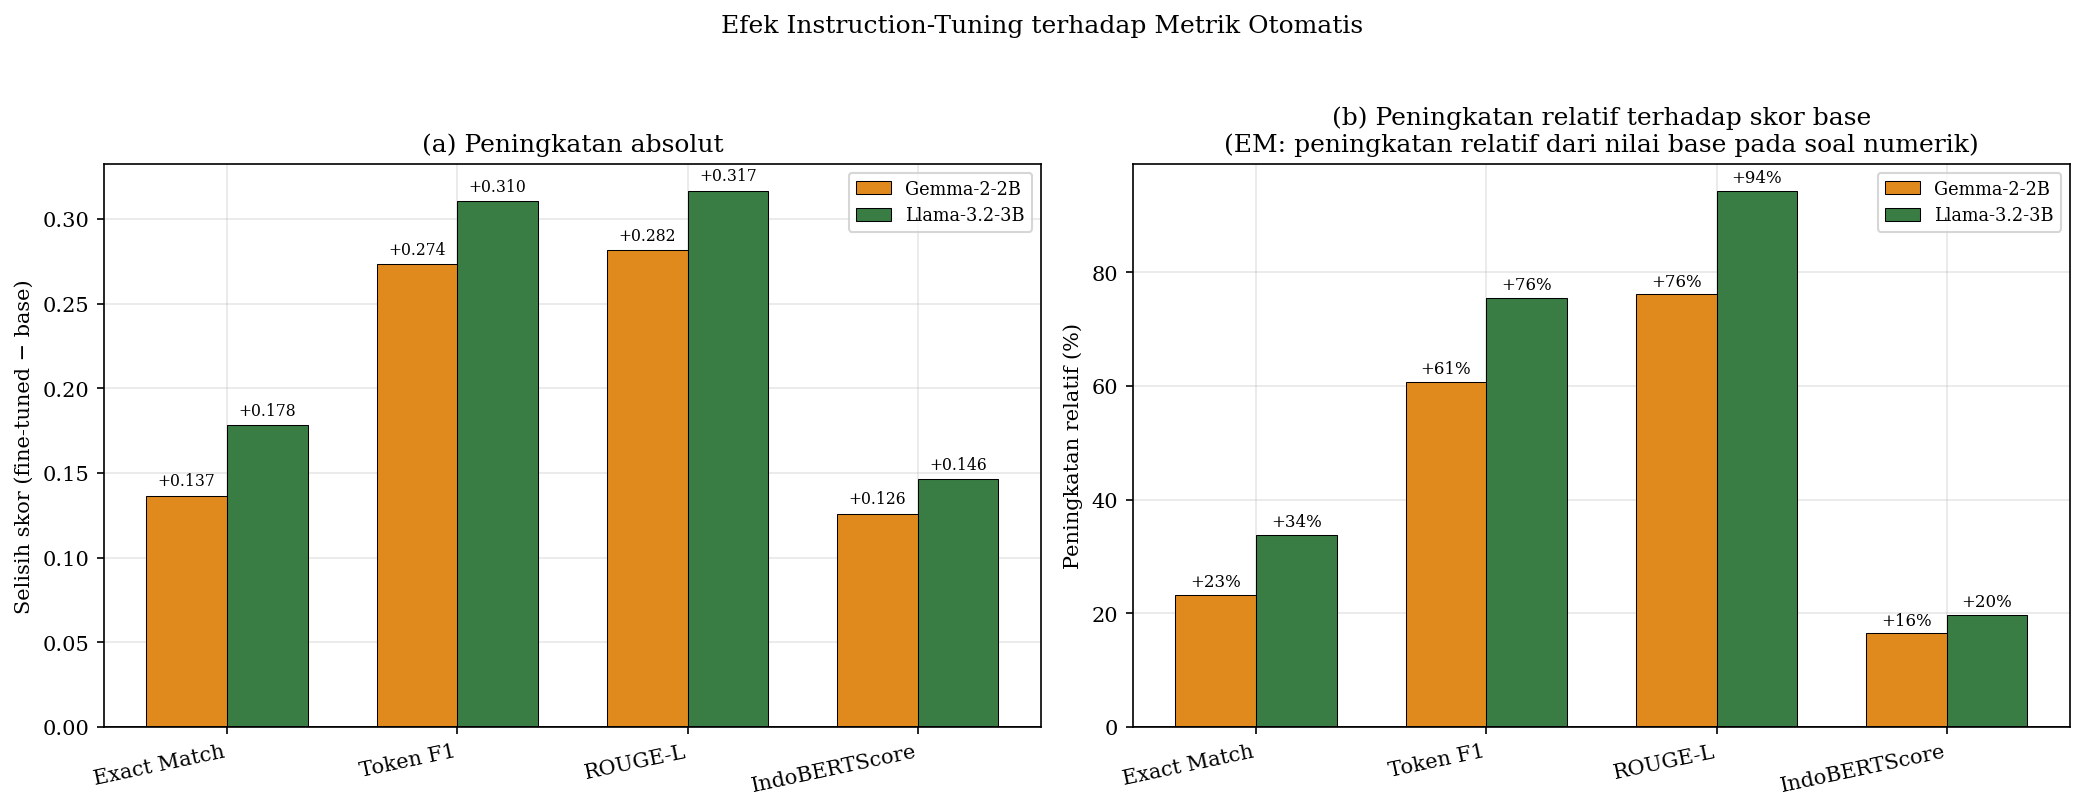

In [267]:
def fig36_delta_peningkatan():
    if summary is None:
        lewati("summary_metrics.csv tidak tersedia."); return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

    ax = axes[0]
    x = np.arange(len(METRICS)); w = .35
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        delta = [summary.loc[f"{mk}_finetuned", m] - summary.loc[f"{mk}_base", m] for m in METRICS]
        ax.bar(x + (i - .5) * w, delta, w, color=warna, edgecolor="black",
               linewidth=.5, label=MODEL_LABELS[mk])
        for xi, v in zip(x + (i - .5) * w, delta):
            ax.text(xi, v + (.006 if v >= 0 else -.018), f"{v:+.3f}", ha="center", fontsize=7.5)
    ax.axhline(0, color="black", lw=.8)
    ax.set_xticks(x); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=12, ha="right")
    ax.set_ylabel("Selisih skor (fine-tuned − base)")
    ax.set_title("(a) Peningkatan absolut"); ax.legend(fontsize=8.5)

    ax = axes[1]
    for i, (mk, warna) in enumerate([("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]):
        rel = []
        for m in METRICS:
            b = summary.loc[f"{mk}_base", m]
            f_ = summary.loc[f"{mk}_finetuned", m]
            rel.append(100 * (f_ - b) / b if b > 0 else np.nan)
        ax.bar(x + (i - .5) * w, rel, w, color=warna, edgecolor="black",
               linewidth=.5, label=MODEL_LABELS[mk])
        for xi, v in zip(x + (i - .5) * w, rel):
            if pd.notna(v):
                ax.text(xi, v + 1.5, f"{v:+.0f}%", ha="center", fontsize=8)
    ax.axhline(0, color="black", lw=.8)
    ax.set_xticks(x); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=12, ha="right")
    ax.set_ylabel("Peningkatan relatif (%)")
    ax.set_title("(b) Peningkatan relatif terhadap skor base\n(EM: peningkatan relatif dari nilai base pada soal numerik)")
    ax.legend(fontsize=8.5)

    fig.suptitle("Efek Instruction-Tuning terhadap Metrik Otomatis", y=1.03)
    plt.tight_layout(); plt.savefig("fig36_delta_peningkatan.png", bbox_inches="tight"); plt.show()

fig36_delta_peningkatan()

### Gambar 37 — Sebaran skor tingkat-soal

Boxplot menggunakan seluruh baris pada berkas skor yang tersedia.


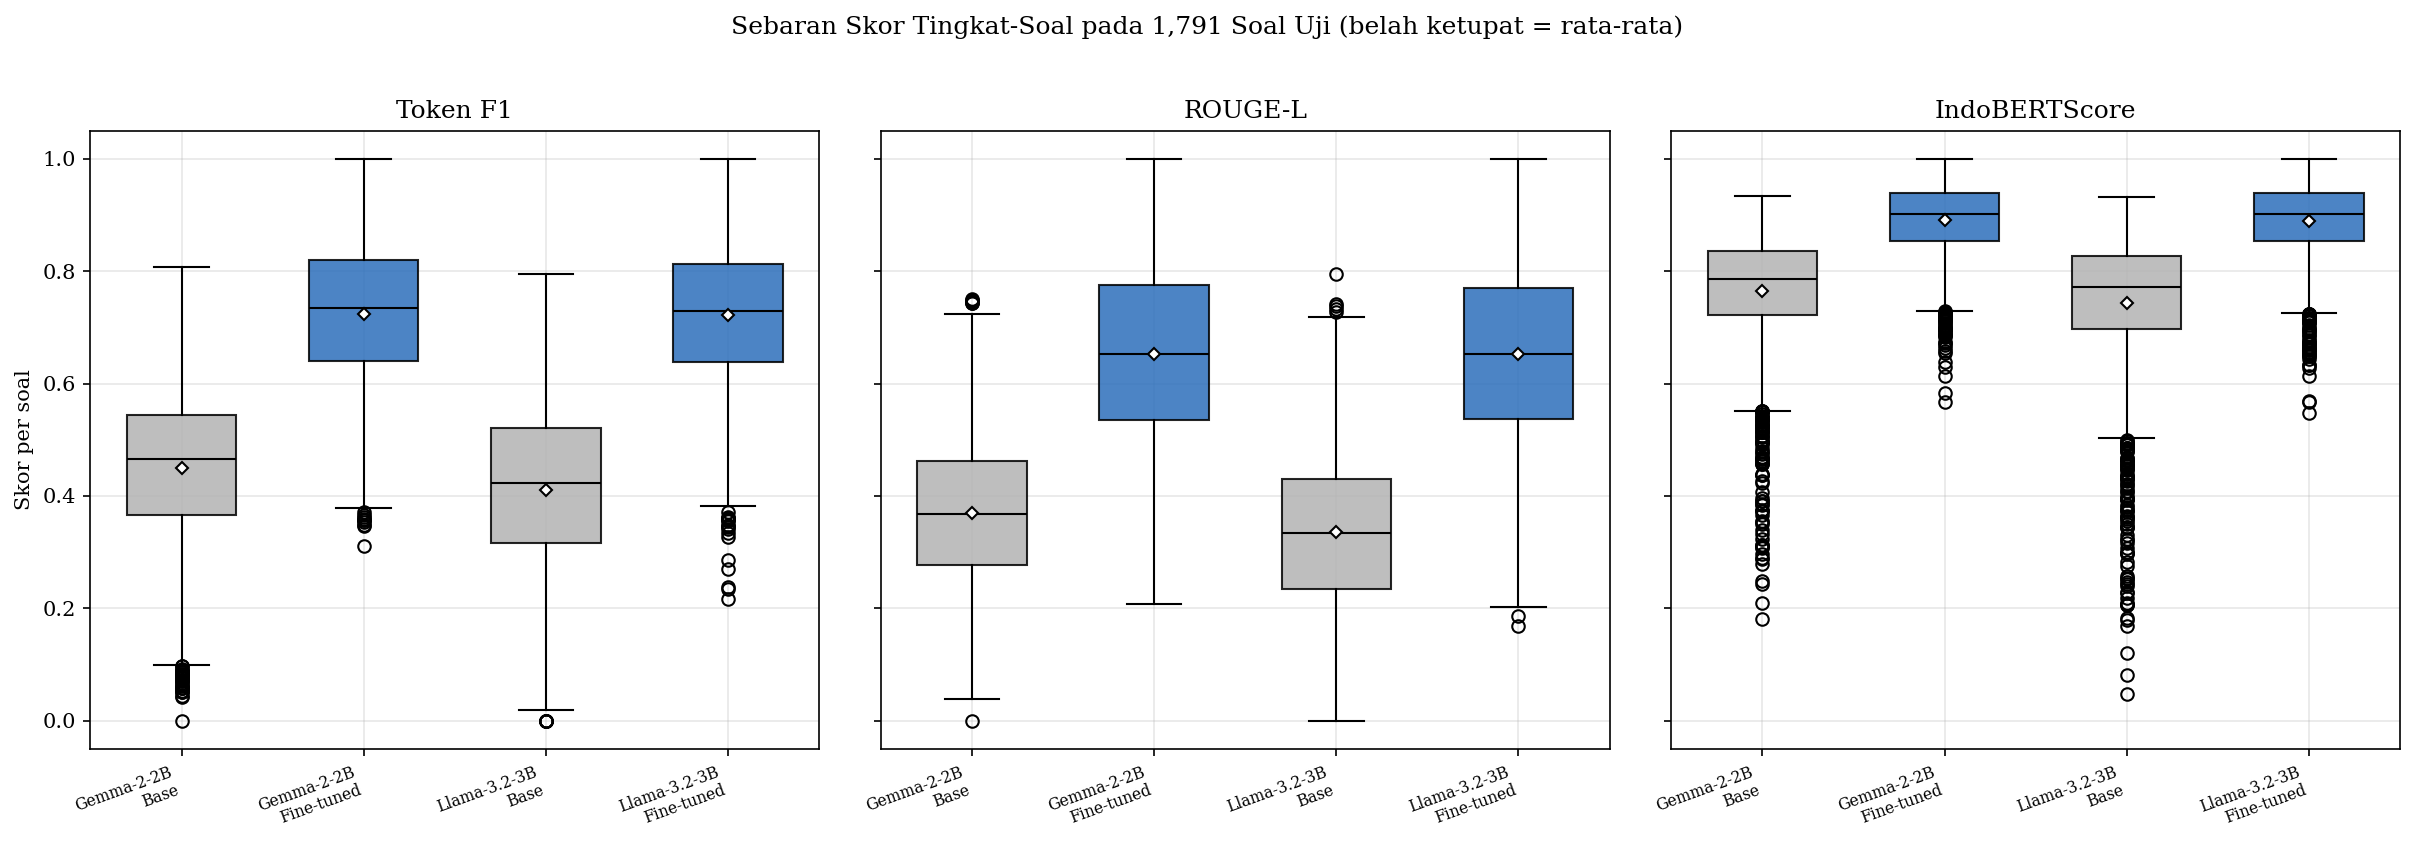

In [268]:
def fig37_sebaran_skor():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    metrik_plot = ["f1", "rouge_l", "indobertscore"]
    fig, axes = plt.subplots(1, len(metrik_plot), figsize=(5.4 * len(metrik_plot), 5.5), sharey=True)
    label = [f"{MODEL_LABELS[mk]}\n{'Base' if c == 'base' else 'Fine-tuned'}"
             for mk in MODEL_KEYS for c in CONDITIONS]
    warna = [C_BASE, C_FT] * len(MODEL_KEYS)
    for ax, m in zip(axes, metrik_plot):
        data = [scored[(mk, c)][m].values for mk in MODEL_KEYS for c in CONDITIONS]
        bp = ax.boxplot(data, patch_artist=True, widths=.6, showmeans=True,
                        meanprops={"marker": "D", "markerfacecolor": "white",
                                   "markeredgecolor": "black", "markersize": 4})
        for patch, col in zip(bp["boxes"], warna):
            patch.set_facecolor(col); patch.set_alpha(.85)
        for med in bp["medians"]: med.set_color("black")
        ax.set_xticklabels(label, fontsize=7.5, rotation=20, ha="right")
        ax.set_title(METRIC_LABELS[m])
    axes[0].set_ylabel("Skor per soal")
    fig.suptitle(f"Sebaran Skor Tingkat-Soal pada {N_TEST:,} Soal Uji (belah ketupat = rata-rata)", y=1.02)
    plt.tight_layout(); plt.savefig("fig37_sebaran_skor.png", bbox_inches="tight"); plt.show()

fig37_sebaran_skor()

### Gambar 38 — Exact Match numerik: cakupan dan akurasi pada soal berbasis angka

Cakupan, Exact Match, dan distribusi Token F1 dihitung langsung dari berkas skor tingkat-soal.


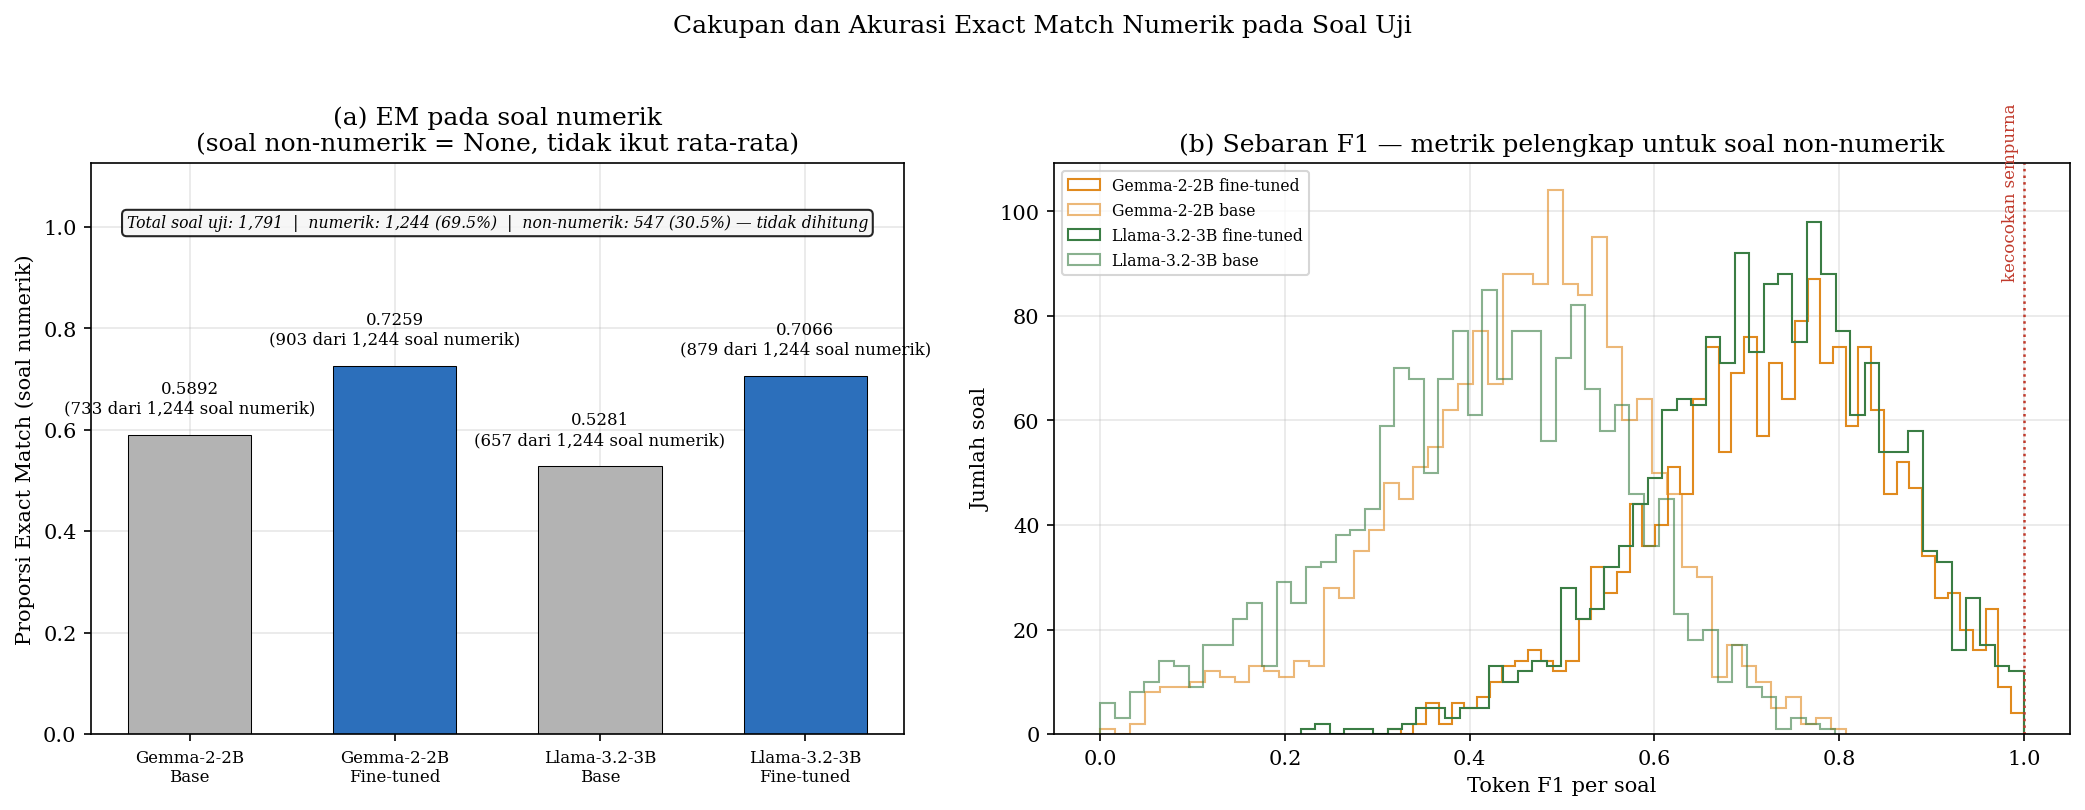

In [269]:
def fig38_keterbatasan_em():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1, 1.25]})

    ax = axes[0]
    label = [f"{MODEL_LABELS[mk]}\n{'Base' if c == 'base' else 'Fine-tuned'}"
             for mk in MODEL_KEYS for c in CONDITIONS]
    # pandas .mean() mengabaikan NaN — hasilnya adalah EM di soal numerik saja
    nilai = [scored[(mk, c)]["em"].mean() for mk in MODEL_KEYS for c in CONDITIONS]
    n_numerik = [int(scored[(mk, c)]["em"].notna().sum()) for mk in MODEL_KEYS for c in CONDITIONS]
    n_benar = [int(scored[(mk, c)]["em"].sum()) for mk in MODEL_KEYS for c in CONDITIONS]
    ax.bar(label, nilai, color=[C_BASE, C_FT] * len(MODEL_KEYS), edgecolor="black", linewidth=.5, width=.6)
    ymax = max((v for v in nilai if pd.notna(v) and v > 0), default=.01)
    for i, (v, n_n, n_b) in enumerate(zip(nilai, n_numerik, n_benar)):
        ax.text(i, v + ymax * .06, f"{v:.4f}\n({n_b} dari {n_n:,} soal numerik)",
                ha="center", fontsize=8)
    ax.set_ylabel("Proporsi Exact Match (soal numerik)"); ax.tick_params(axis="x", labelsize=8)
    ax.set_ylim(0, ymax * 1.55)
    n_num0 = n_numerik[0]
    ax.text(0.5, 0.91,
            f"Total soal uji: {N_TEST:,}  |  numerik: {n_num0:,} ({100*n_num0/N_TEST:.1f}%)  |  "
            f"non-numerik: {N_TEST - n_num0:,} ({100*(N_TEST - n_num0)/N_TEST:.1f}%) — tidak dihitung",
            transform=ax.transAxes, ha="center", va="top", fontsize=7.5, style="italic",
            bbox=dict(boxstyle="round,pad=.3", facecolor="#f5f5f5", alpha=.85))
    ax.set_title("(a) EM pada soal numerik\n(soal non-numerik = None, tidak ikut rata-rata)")

    ax = axes[1]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        d = scored[(mk, "finetuned")]
        ax.hist(d["f1"], bins=50, histtype="step", lw=1.8, color=warna,
                label=f"{MODEL_LABELS[mk]} fine-tuned")
        d2 = scored[(mk, "base")]
        ax.hist(d2["f1"], bins=50, histtype="step", lw=1.3, ls="--", color=warna, alpha=.6,
                label=f"{MODEL_LABELS[mk]} base")
    ax.axvline(1.0, color=C_DROP, lw=1.2, ls=":")
    ax.text(.995, ax.get_ylim()[1] * .8, "kecocokan sempurna", rotation=90,
            ha="right", fontsize=8, color=C_DROP)
    ax.set_xlabel("Token F1 per soal"); ax.set_ylabel("Jumlah soal")
    ax.set_title("(b) Sebaran F1 — metrik pelengkap untuk soal non-numerik"); ax.legend(fontsize=7.5)

    fig.suptitle("Cakupan dan Akurasi Exact Match Numerik pada Soal Uji", y=1.03)
    plt.tight_layout(); plt.savefig("fig38_keterbatasan_em.png", bbox_inches="tight"); plt.show()

fig38_keterbatasan_em()

### Gambar 39 — Hubungan antar-metrik: kesamaan leksikal versus kesamaan semantik

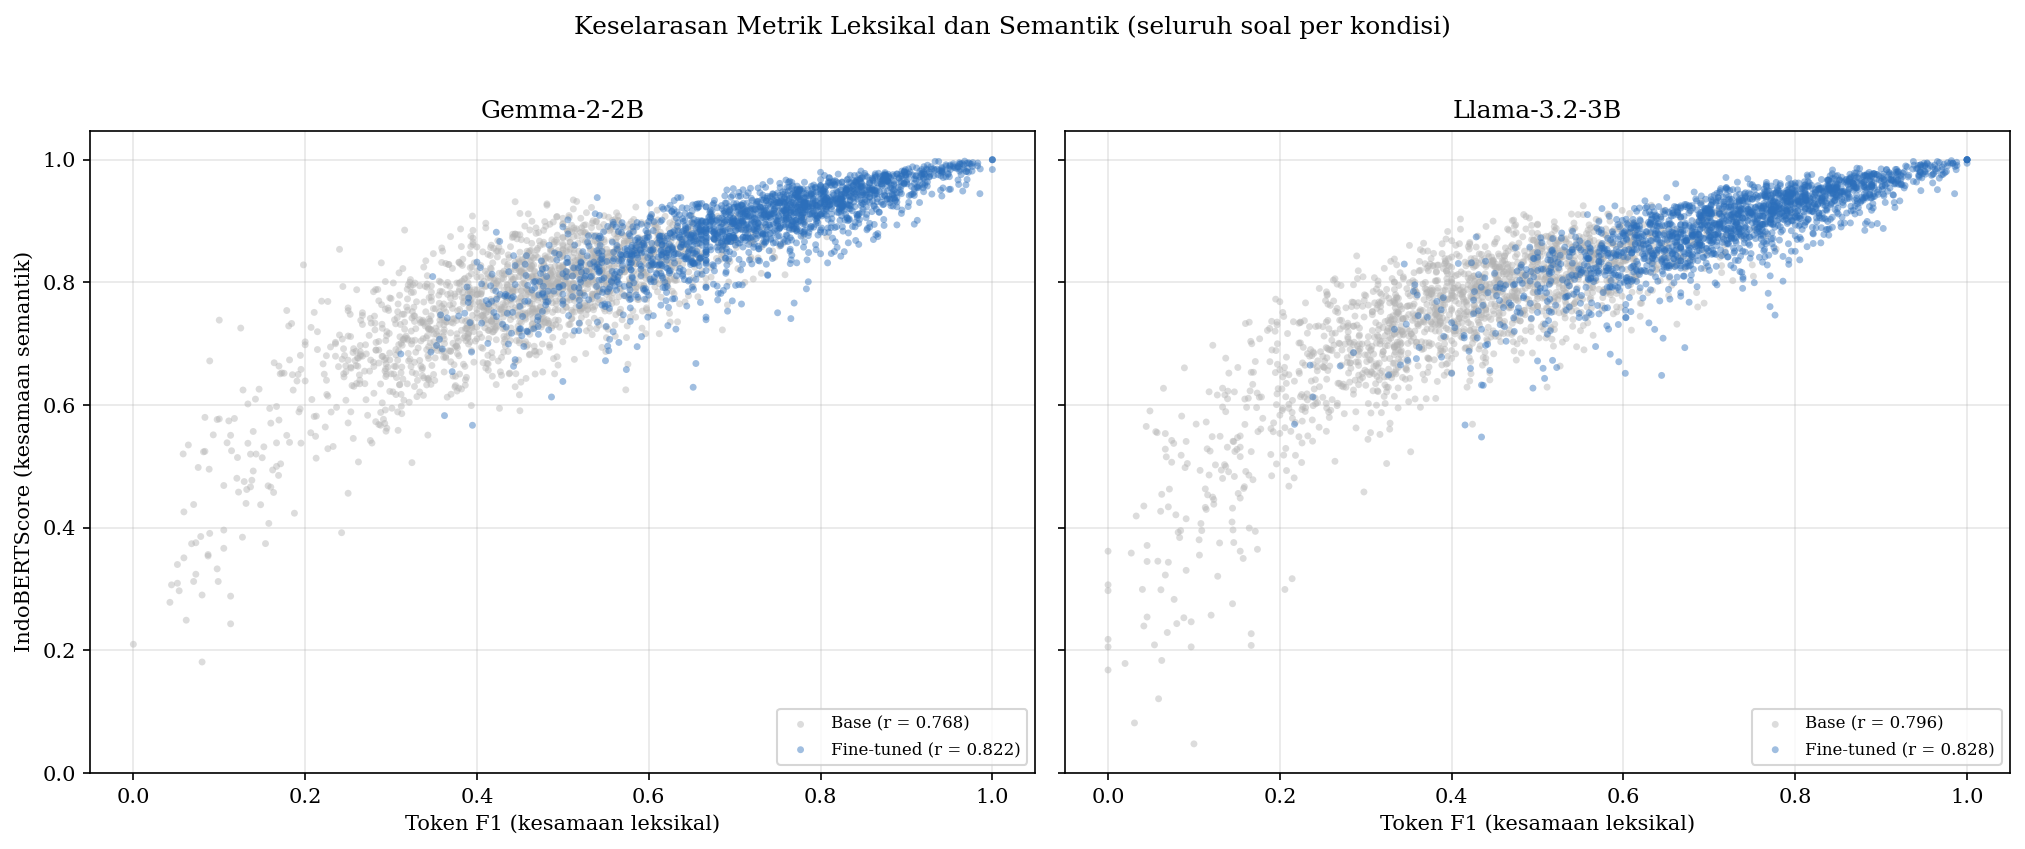

In [270]:
def fig39_hubungan_metrik():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(6.8 * len(MODEL_KEYS), 5.5),
                             sharex=True, sharey=True)
    for ax, mk in zip(axes, MODEL_KEYS):
        for cond, warna in [("base", C_BASE), ("finetuned", C_FT)]:
            d = scored[(mk, cond)]
            idx = np.arange(len(d))
            r = np.corrcoef(d["f1"], d["indobertscore"])[0, 1]
            ax.scatter(d["f1"].values[idx], d["indobertscore"].values[idx], s=11, alpha=.45,
                       color=warna, edgecolor="none",
                       label=f"{'Base' if cond == 'base' else 'Fine-tuned'} (r = {r:.3f})")
        ax.set_xlabel("Token F1 (kesamaan leksikal)")
        ax.set_title(MODEL_LABELS[mk]); ax.legend(fontsize=8, loc="lower right")
    axes[0].set_ylabel("IndoBERTScore (kesamaan semantik)")
    fig.suptitle("Keselarasan Metrik Leksikal dan Semantik (seluruh soal per kondisi)", y=1.02)
    plt.tight_layout(); plt.savefig("fig39_hubungan_metrik.png", bbox_inches="tight"); plt.show()

fig39_hubungan_metrik()

### Gambar 40 — Performa per tipe sub-tugas *(butuh `test.csv`)*
Analisis ini menunjukkan pada jenis pertanyaan mana instruction-tuning memberi manfaat terbesar dan terkecil — informasi yang hilang bila hanya melaporkan rata-rata keseluruhan.

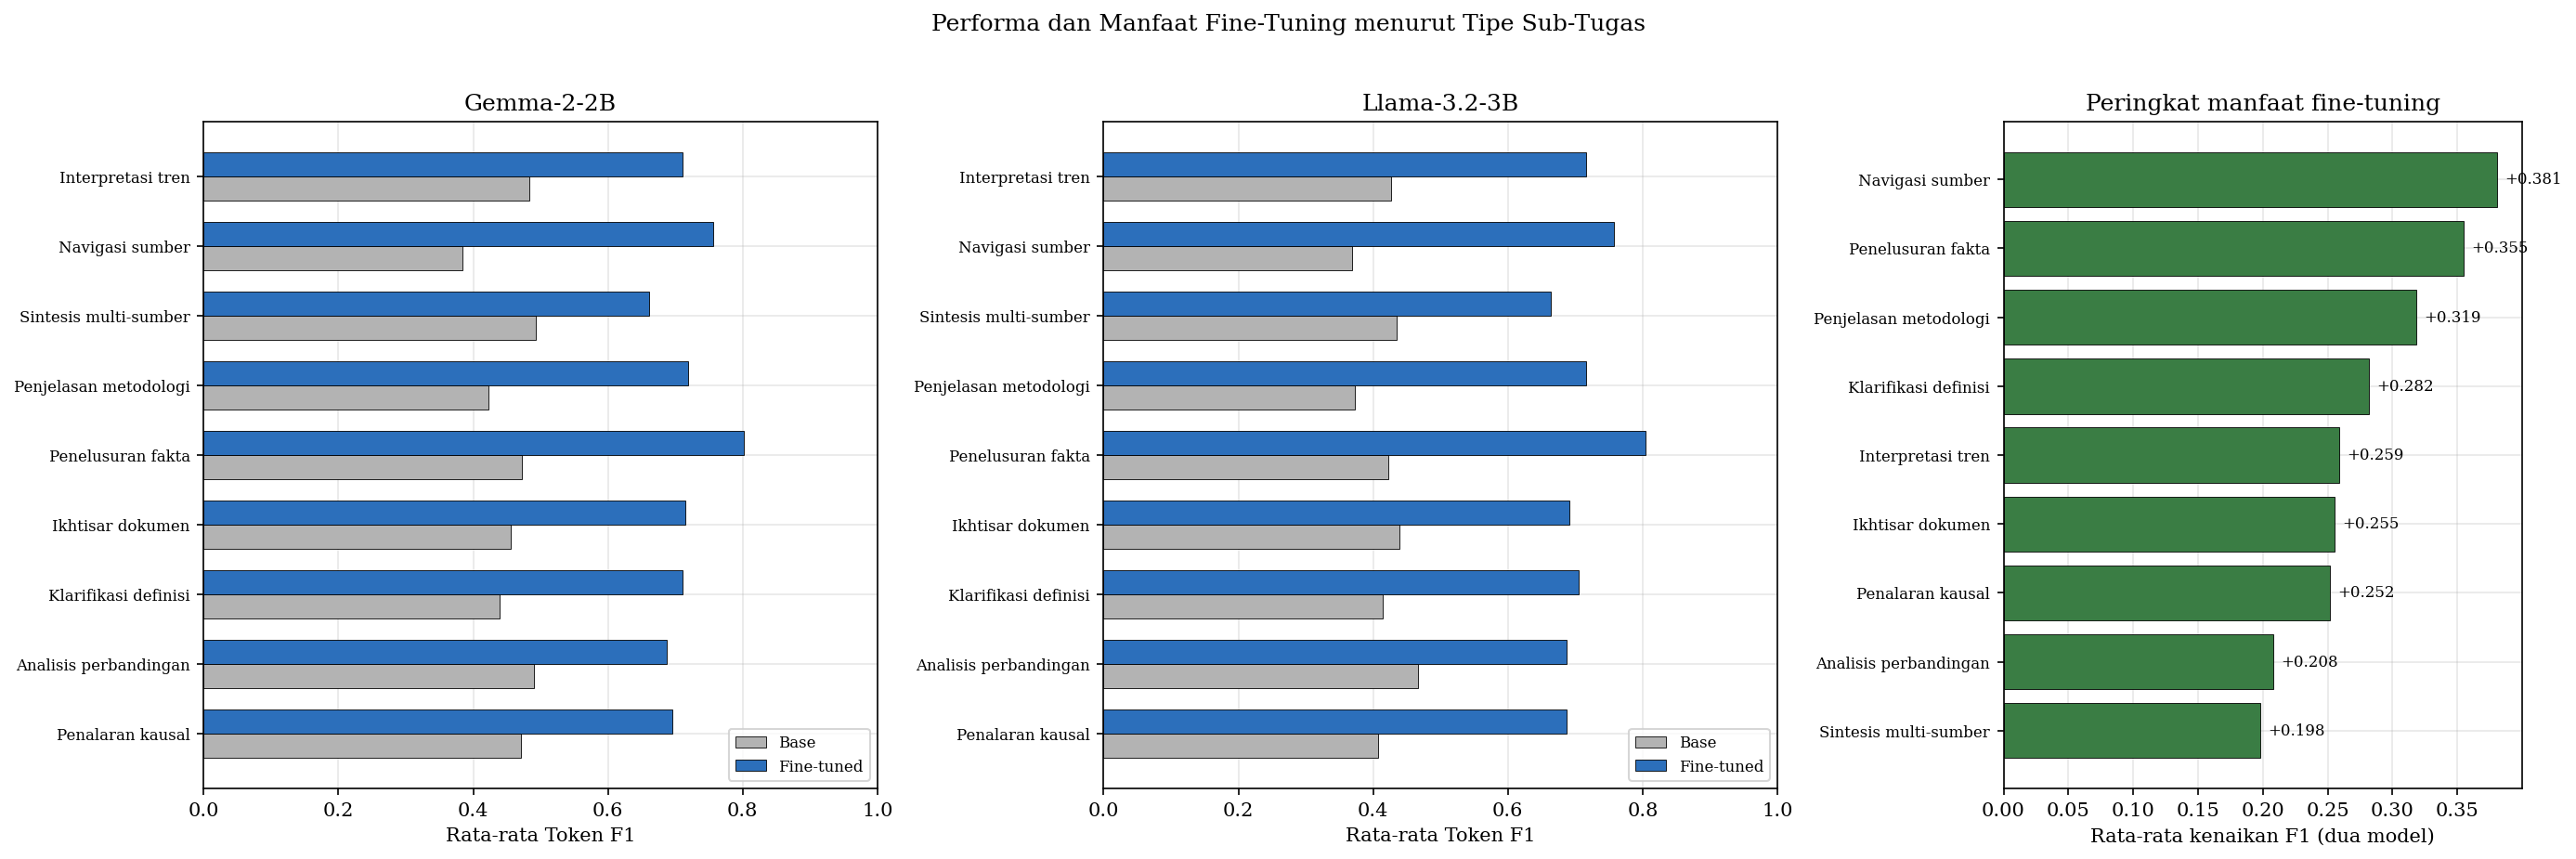

In [271]:
def fig40_performa_per_subtask():
    if not ADA_SCORED or df_test is None:
        lewati("Butuh test.csv dan berkas *_scored.csv lengkap."); return
    meta = df_test[["record_id", "subtask_type"]].drop_duplicates("record_id")
    subtask = sorted(meta["subtask_type"].dropna().unique())

    fig, axes = plt.subplots(1, len(MODEL_KEYS) + 1, figsize=(6.2 * (len(MODEL_KEYS) + 1), 6),
                             gridspec_kw={"width_ratios": [1.3] * len(MODEL_KEYS) + [1]})
    delta_semua = {}
    for ax, mk in zip(axes, MODEL_KEYS):
        base = scored[(mk, "base")].merge(meta, on="record_id").groupby("subtask_type")["f1"].mean().reindex(subtask)
        ft = scored[(mk, "finetuned")].merge(meta, on="record_id").groupby("subtask_type")["f1"].mean().reindex(subtask)
        delta_semua[mk] = ft - base
        y = np.arange(len(subtask)); w = .35
        ax.barh(y - w / 2, base, w, color=C_BASE, edgecolor="black", linewidth=.4, label="Base")
        ax.barh(y + w / 2, ft, w, color=C_FT, edgecolor="black", linewidth=.4, label="Fine-tuned")
        ax.set_yticks(y)
        ax.set_yticklabels([SUBTASK_LABEL.get(s, s) for s in subtask], fontsize=8)
        ax.set_xlabel("Rata-rata Token F1"); ax.set_xlim(0, 1)
        ax.set_title(MODEL_LABELS[mk]); ax.legend(fontsize=8, loc="lower right")

    ax = axes[-1]
    d = pd.DataFrame(delta_semua).reindex(subtask)
    d["rerata"] = d.mean(axis=1)
    d = d.sort_values("rerata")
    y = np.arange(len(d))
    ax.barh(y, d["rerata"], color=C_KEEP, edgecolor="black", linewidth=.4)
    for yi, v in zip(y, d["rerata"]):
        ax.text(v + .006, yi, f"{v:+.3f}", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([SUBTASK_LABEL.get(s, s) for s in d.index], fontsize=8)
    ax.set_xlabel("Rata-rata kenaikan F1 (dua model)")
    ax.set_title("Peringkat manfaat fine-tuning")

    fig.suptitle("Performa dan Manfaat Fine-Tuning menurut Tipe Sub-Tugas", y=1.02)
    plt.tight_layout(); plt.savefig("fig40_performa_per_subtask.png", bbox_inches="tight"); plt.show()

fig40_performa_per_subtask()

### Gambar 41 — Perbandingan per soal: menang, seri, atau kalah

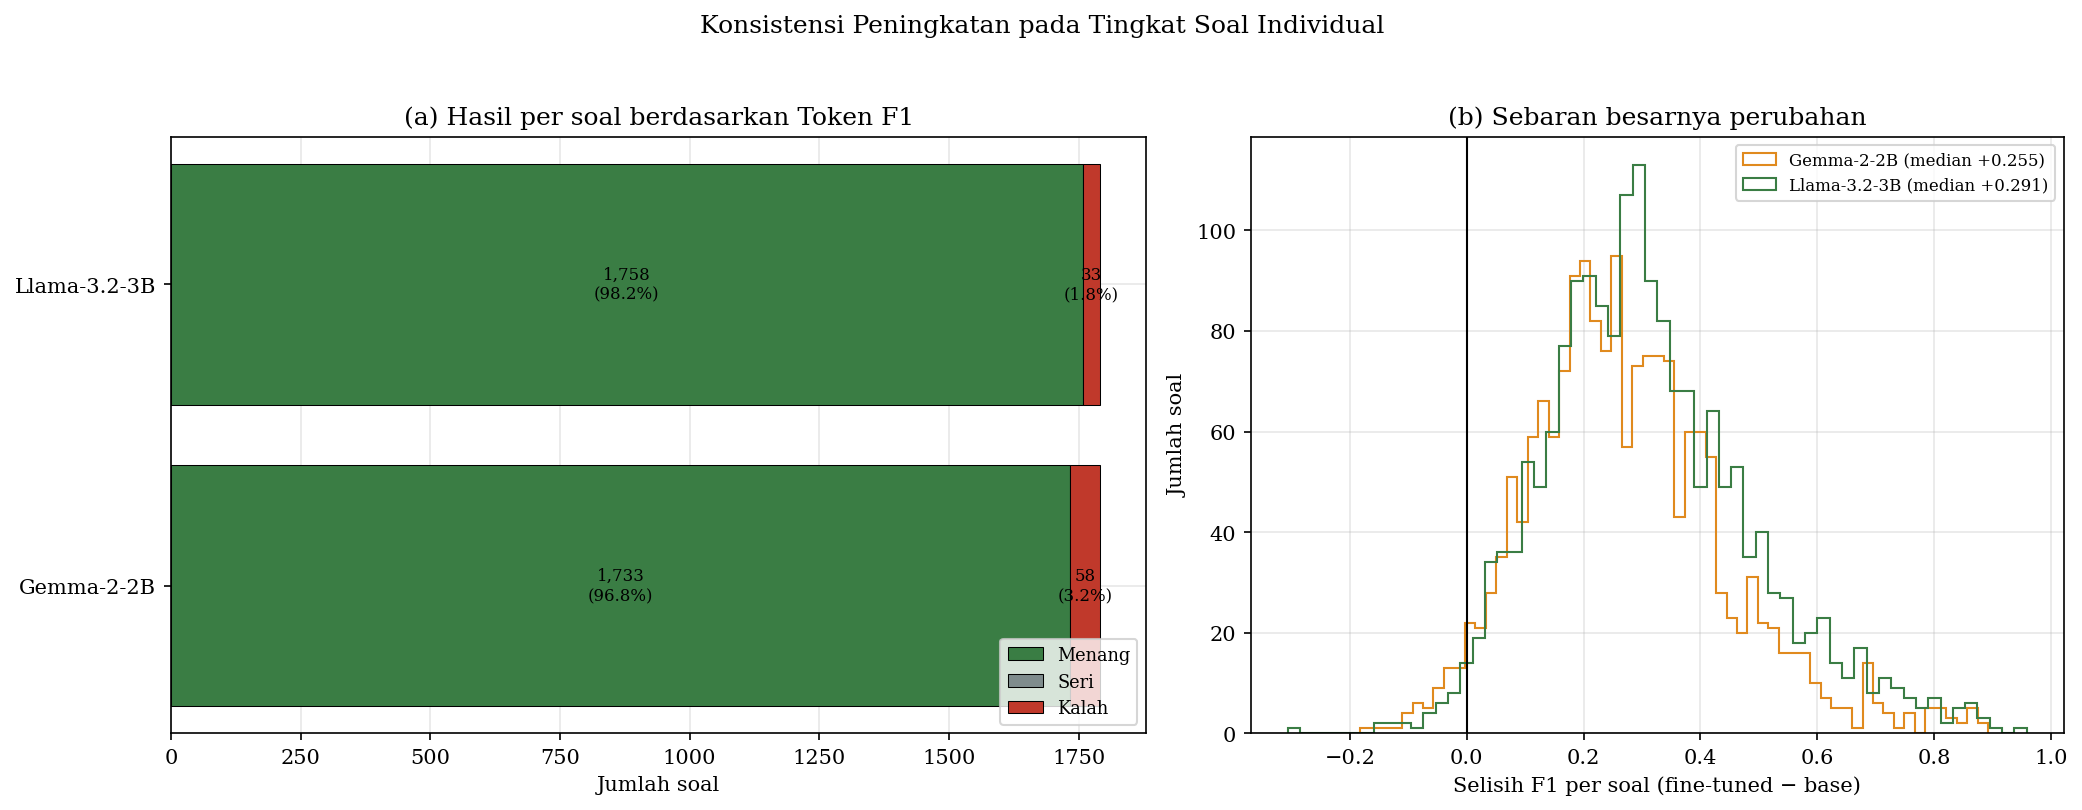

In [272]:
def fig41_menang_kalah():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={"width_ratios": [1.2, 1]})

    ax = axes[0]
    rekap = {}
    for mk in MODEL_KEYS:
        d = pasangan(mk, "f1")
        rekap[mk] = {"Menang": int((d["finetuned"] > d["base"]).sum()),
                     "Seri": int((d["finetuned"] == d["base"]).sum()),
                     "Kalah": int((d["finetuned"] < d["base"]).sum())}
    d = pd.DataFrame(rekap).T
    kiri = np.zeros(len(d))
    for kat, warna in [("Menang", C_KEEP), ("Seri", C_MUTED), ("Kalah", C_DROP)]:
        nilai = d[kat].values
        ax.barh([MODEL_LABELS[m] for m in d.index], nilai, left=kiri, color=warna,
                edgecolor="black", linewidth=.5, label=kat)
        for yi, (v, l) in enumerate(zip(nilai, kiri)):
            if v > 0:
                ax.text(l + v / 2, yi, f"{v:,}\n({100 * v / d.loc[d.index[yi]].sum():.1f}%)",
                        ha="center", va="center", fontsize=8)
        kiri += nilai
    ax.set_xlabel("Jumlah soal"); ax.set_title("(a) Hasil per soal berdasarkan Token F1")
    ax.legend(fontsize=8.5, loc="lower right")

    ax = axes[1]
    for mk, warna in [("gemma2", C_GEMMA), ("llama3.2", C_LLAMA)]:
        d = pasangan(mk, "f1")
        selisih = d["finetuned"] - d["base"]
        ax.hist(selisih, bins=60, histtype="step", lw=1.8, color=warna,
                label=f"{MODEL_LABELS[mk]} (median {selisih.median():+.3f})")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Selisih F1 per soal (fine-tuned − base)"); ax.set_ylabel("Jumlah soal")
    ax.set_title("(b) Sebaran besarnya perubahan"); ax.legend(fontsize=8)

    fig.suptitle("Konsistensi Peningkatan pada Tingkat Soal Individual", y=1.03)
    plt.tight_layout(); plt.savefig("fig41_menang_kalah.png", bbox_inches="tight"); plt.show()

fig41_menang_kalah()

### Gambar 42 — Uji signifikansi statistik peningkatan
Karena skor base dan fine-tuned diukur pada soal yang sama, digunakan uji berpasangan. Normalitas selisih diperiksa dengan Shapiro-Wilk; bila tidak normal (umum terjadi pada metrik terbatas 0–1) dipakai Wilcoxon signed-rank. Ukuran efek dilaporkan dengan Cliff's delta sebagai pelengkap nilai-p yang sangat sensitif pada n besar.

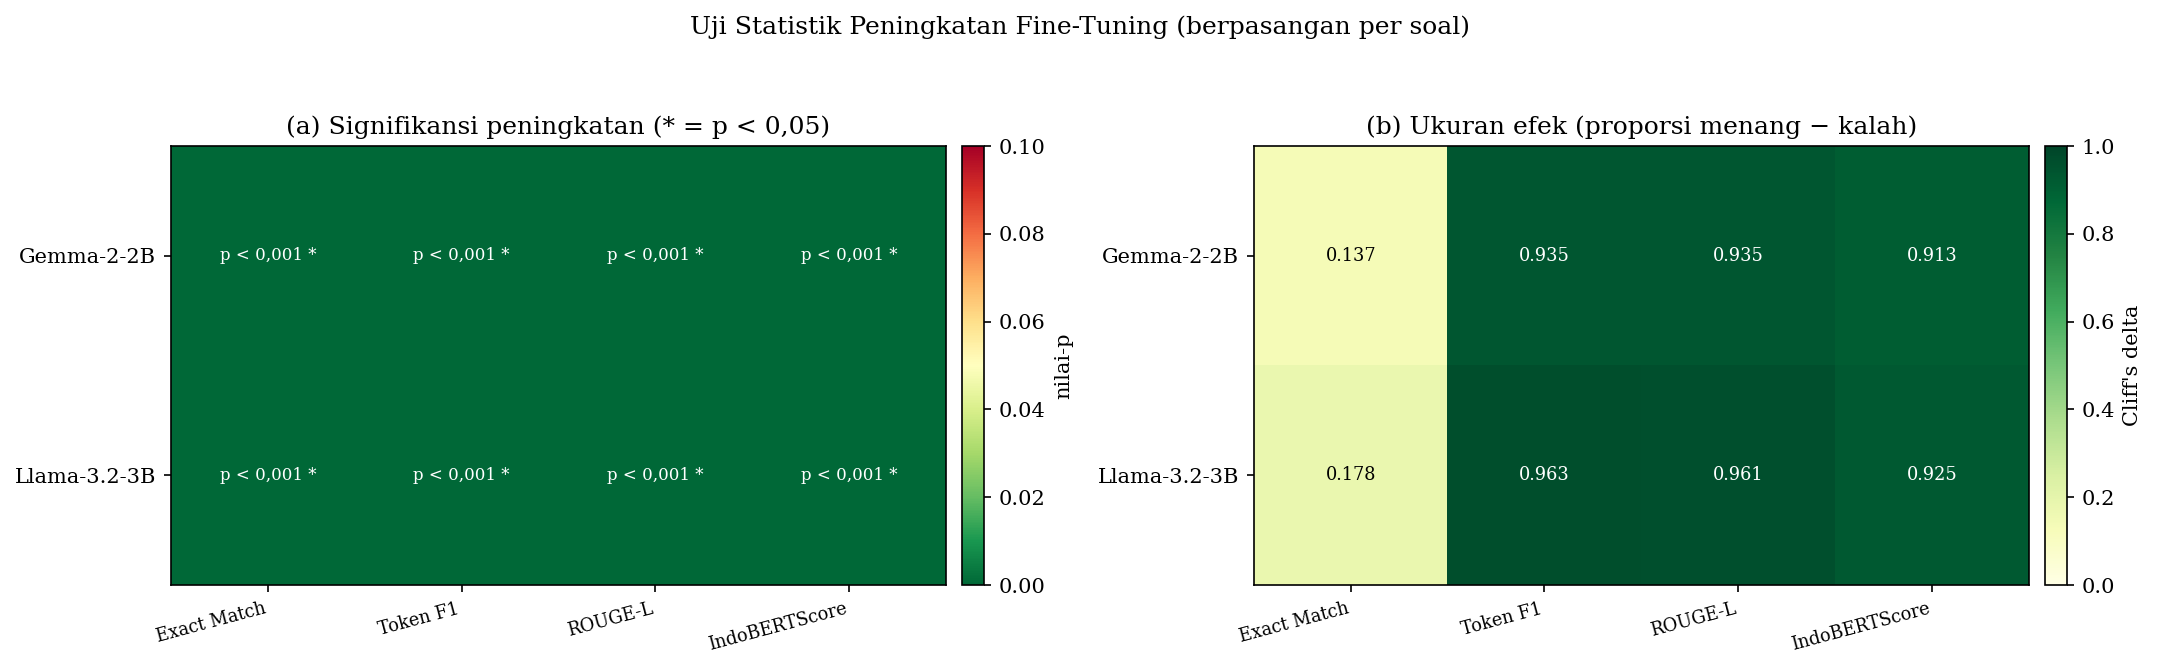

   model        metrik                  uji  rerata_base  rerata_ft  selisih  statistik       p_value  signifikan_5pct  cliffs_delta
  gemma2            em Wilcoxon signed-rank     0.589228   0.725884 0.136656    13240.0  8.111274e-21             True      0.136656
  gemma2            f1 Wilcoxon signed-rank     0.450033   0.723552 0.273519     6396.0 1.620000e-289             True      0.935232
  gemma2       rouge_l Wilcoxon signed-rank     0.370064   0.651866 0.281802     6482.0 1.868978e-289             True      0.935232
  gemma2 indobertscore Wilcoxon signed-rank     0.765094   0.891094 0.125999    16631.0 3.562932e-282             True      0.912898
llama3.2            em Wilcoxon signed-rank     0.528135   0.706592 0.178457    18427.5  2.319928e-28             True      0.178457
llama3.2            f1 Wilcoxon signed-rank     0.411047   0.721543 0.310496     3712.0 1.855193e-291             True      0.963149
llama3.2       rouge_l Wilcoxon signed-rank     0.335616   0.652464 0

In [273]:
def fig42_uji_signifikansi():
    if not ADA_SCORED:
        lewati("Berkas *_scored.csv belum lengkap."); return None

    baris = []
    for mk in MODEL_KEYS:
        for m in METRICS:
            d = pasangan(mk, m)
            selisih = (d["finetuned"] - d["base"]).to_numpy()
            if np.allclose(selisih, 0):
                uji, stat, p = "tidak dapat diuji", np.nan, np.nan
                normal = False
            else:
                sampel = selisih if len(selisih) <= 5000 else pd.Series(selisih).sample(5000, random_state=42).to_numpy()
                _, p_norm = stats.shapiro(sampel)
                normal = p_norm >= .05
                if normal:
                    stat, p = stats.ttest_rel(d["finetuned"], d["base"])
                    uji = "Paired t-test"
                else:
                    stat, p = stats.wilcoxon(selisih)
                    uji = "Wilcoxon signed-rank"
            menang = (selisih > 0).mean(); kalah = (selisih < 0).mean()
            baris.append({"model": mk, "metrik": m, "uji": uji,
                          "rerata_base": d["base"].mean(), "rerata_ft": d["finetuned"].mean(),
                          "selisih": selisih.mean(), "statistik": stat, "p_value": p,
                          "signifikan_5pct": bool(p < .05) if pd.notna(p) else False,
                          "cliffs_delta": menang - kalah})
    hasil = pd.DataFrame(baris)

    mat = hasil.pivot(index="model", columns="metrik", values="p_value").reindex(
        index=MODEL_KEYS, columns=METRICS)
    eff = hasil.pivot(index="model", columns="metrik", values="cliffs_delta").reindex(
        index=MODEL_KEYS, columns=METRICS)

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.2))

    ax = axes[0]
    im = ax.imshow(mat.values, cmap="RdYlGn_r", vmin=0, vmax=.1, aspect="auto")
    ax.set_xticks(range(len(METRICS))); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS],
                                                           rotation=15, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(MODEL_KEYS))); ax.set_yticklabels([MODEL_LABELS[m] for m in MODEL_KEYS])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            p = mat.values[i, j]
            if pd.isna(p):
                teks = "n/a"
            else:
                teks = ("p < 0,001" if p < .001 else f"p = {p:.3f}") + (" *" if p < .05 else "")
            gelap = pd.notna(p) and (p < .02 or p > .085)
            ax.text(j, i, teks, ha="center", va="center", fontsize=8,
                    color="white" if gelap else "black")
    fig.colorbar(im, ax=ax, fraction=.03, pad=.02).set_label("nilai-p")
    ax.set_title("(a) Signifikansi peningkatan (* = p < 0,05)")
    ax.grid(False)

    ax = axes[1]
    im = ax.imshow(eff.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(METRICS))); ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS],
                                                           rotation=15, ha="right", fontsize=8.5)
    ax.set_yticks(range(len(MODEL_KEYS))); ax.set_yticklabels([MODEL_LABELS[m] for m in MODEL_KEYS])
    for i in range(eff.shape[0]):
        for j in range(eff.shape[1]):
            v = eff.values[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8.5,
                    color="white" if v > .55 else "black")
    fig.colorbar(im, ax=ax, fraction=.03, pad=.02).set_label("Cliff's delta")
    ax.set_title("(b) Ukuran efek (proporsi menang − kalah)")
    ax.grid(False)

    fig.suptitle("Uji Statistik Peningkatan Fine-Tuning (berpasangan per soal)", y=1.05)
    plt.tight_layout(); plt.savefig("fig42_uji_signifikansi.png", bbox_inches="tight"); plt.show()

    print(hasil.to_string(index=False))
    return hasil

hasil_uji = fig42_uji_signifikansi()

---
# Bagian 6 — Evaluasi Model GGUF Q4_K_M

Bagian ini membaca keluaran asli notebook `17-compute-automatic-eval-gguf.ipynb` dari
`Hasil/tujuan2`. Tidak ada skor pengganti: bila `summary_metrics_gguf.csv` belum tersedia,
visualisasi GGUF dilewati. Berkas `*_scored_gguf.csv` dipakai untuk memeriksa konsistensi
ringkasan terhadap rerata skor tingkat-soal bila keempatnya tersedia.


In [274]:
# Pemuatan artefak evaluasi GGUF yang benar-benar dihasilkan Tujuan 2
BERKAS_SUMMARY_GGUF = hasil_t2("summary_metrics_gguf.csv")
summary_gguf = None
if ada(BERKAS_SUMMARY_GGUF):
    _summary_gguf_raw = pd.read_csv(BERKAS_SUMMARY_GGUF)
    kolom_wajib = ["model", *METRICS]
    kurang = [c for c in kolom_wajib if c not in _summary_gguf_raw.columns]
    if kurang:
        raise ValueError(f"summary_metrics_gguf.csv tidak memiliki kolom wajib: {kurang}")
    summary_gguf = _summary_gguf_raw.set_index("model")
    baris_wajib = [f"{mk}_{cond}" for mk in MODEL_KEYS for cond in CONDITIONS]
    baris_hilang = [r for r in baris_wajib if r not in summary_gguf.index]
    if baris_hilang:
        raise ValueError(f"summary_metrics_gguf.csv tidak memiliki baris model: {baris_hilang}")
else:
    lewati(f"{BERKAS_SUMMARY_GGUF} belum tersedia — evaluasi GGUF akan dilewati.")

scored_gguf = {}
for mk in MODEL_KEYS:
    for cond in CONDITIONS:
        f = hasil_t2(f"{mk}_{cond}_scored_gguf.csv")
        if ada(f):
            scored_gguf[(mk, cond)] = pd.read_csv(f)

ADA_SCORED_GGUF = len(scored_gguf) == len(MODEL_KEYS) * len(CONDITIONS)
if summary_gguf is not None and ADA_SCORED_GGUF:
    selisih_maks = 0.0
    for (mk, cond), data in scored_gguf.items():
        for metrik in METRICS:
            if metrik not in data.columns:
                raise ValueError(f"{mk}_{cond}_scored_gguf.csv tidak memiliki kolom {metrik}")
            nilai_ringkasan = summary_gguf.loc[f"{mk}_{cond}", metrik]
            selisih_maks = max(selisih_maks, abs(data[metrik].mean() - nilai_ringkasan))
    print(f"Validasi ringkasan GGUF terhadap skor tingkat-soal: selisih maksimum {selisih_maks:.3g}")
elif summary_gguf is not None:
    lewati(f"Berkas *_scored_gguf.csv baru tersedia {len(scored_gguf)}/4 — validasi tingkat-soal dilewati.")


Validasi ringkasan GGUF terhadap skor tingkat-soal: selisih maksimum 5.55e-17


### Gambar 43 — Kinerja model setelah ekspor GGUF Q4_K_M
Panel (a) menampilkan seluruh metrik dari `summary_metrics_gguf.csv`. Panel (b) menghitung
perubahan terhadap `summary_metrics.csv` untuk kombinasi model dan kondisi yang sama, sehingga
dampak ekspor GGUF terlihat langsung tanpa memasukkan nilai secara manual.


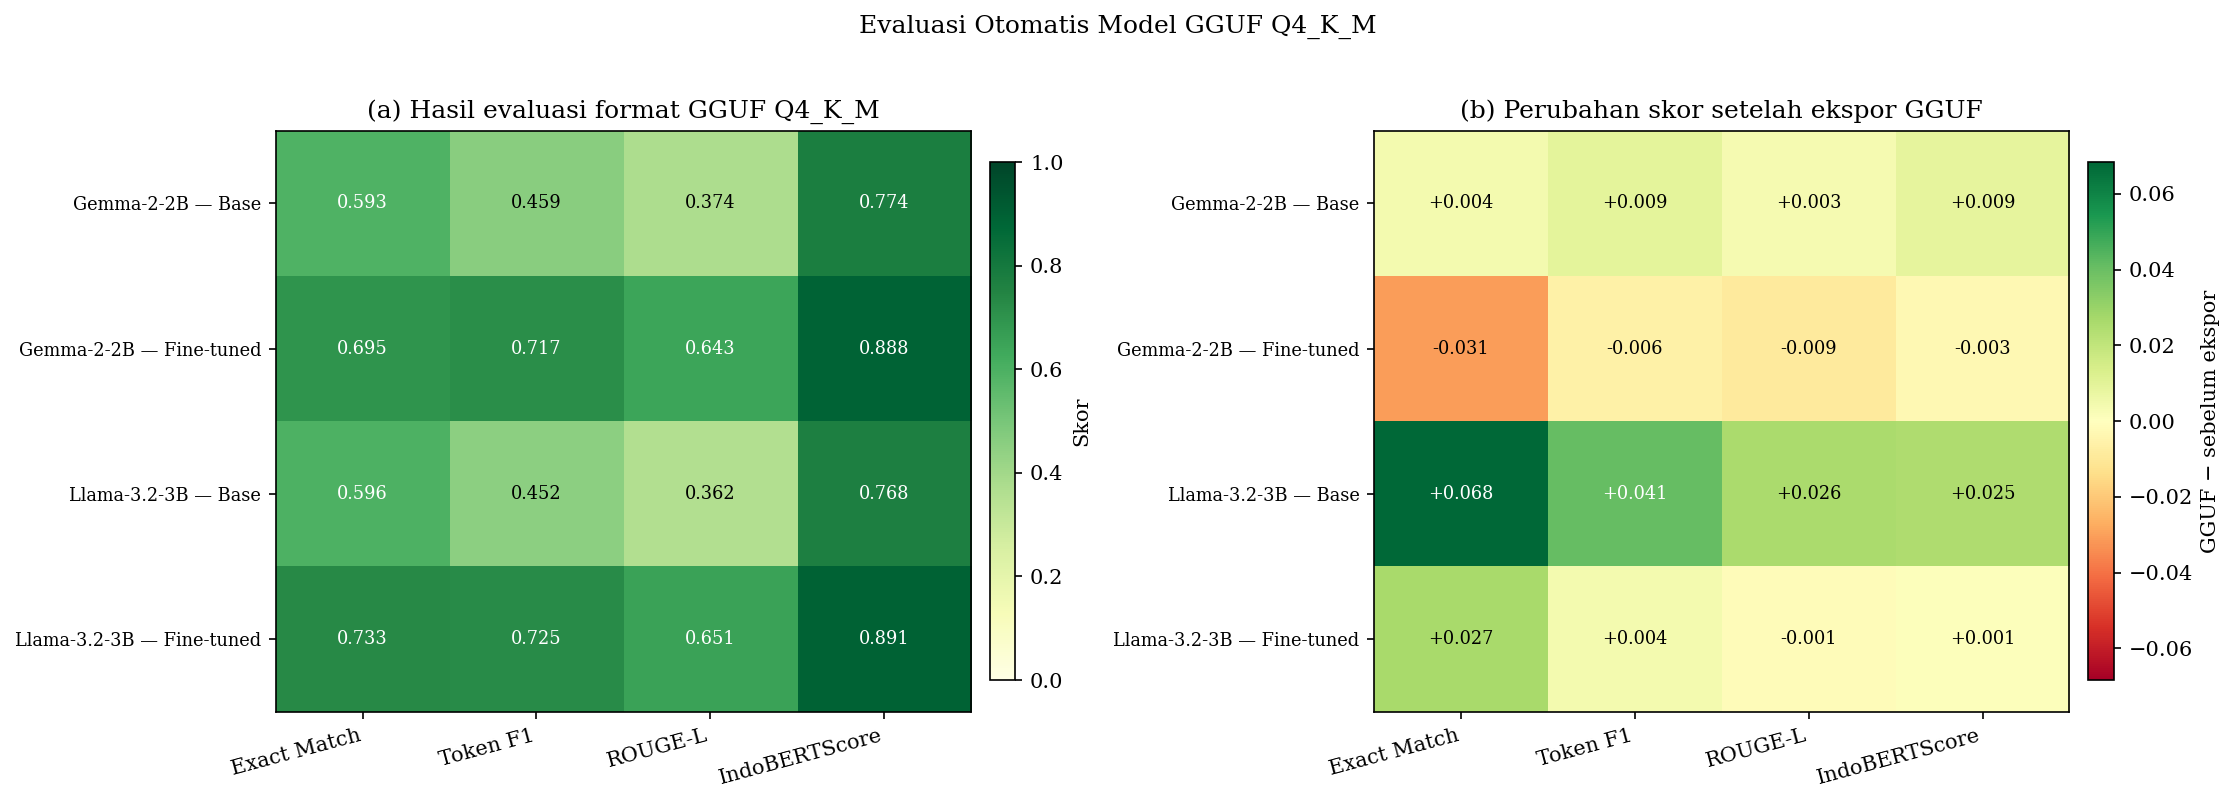

Ringkasan metrik GGUF Q4_K_M:
                    Exact Match  Token F1   ROUGE-L  IndoBERTScore
model                                                             
gemma2_base            0.593248  0.459312  0.373543       0.774076
gemma2_finetuned       0.695338  0.717424  0.642917       0.888417
llama3.2_base          0.596463  0.451857  0.361699       0.768241
llama3.2_finetuned     0.733119  0.725324  0.651080       0.890660

Perbandingan dengan hasil sebelum ekspor GGUF:
             model        metrik  sebelum_gguf  gguf_q4_k_m   selisih
       gemma2_base            em      0.589228     0.593248  0.004019
       gemma2_base            f1      0.450033     0.459312  0.009279
       gemma2_base       rouge_l      0.370064     0.373543  0.003480
       gemma2_base indobertscore      0.765094     0.774076  0.008982
  gemma2_finetuned            em      0.725884     0.695338 -0.030547
  gemma2_finetuned            f1      0.723552     0.717424 -0.006128
  gemma2_finetuned       rouge

In [275]:
def fig43_evaluasi_gguf():
    if summary_gguf is None:
        lewati("summary_metrics_gguf.csv belum tersedia."); return None

    urutan = [f"{mk}_{cond}" for mk in MODEL_KEYS for cond in CONDITIONS]
    label_baris = [
        f"{MODEL_LABELS[mk]} — {'Base' if cond == 'base' else 'Fine-tuned'}"
        for mk in MODEL_KEYS for cond in CONDITIONS
    ]
    nilai_gguf = summary_gguf.loc[urutan, METRICS].astype(float)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
    ax = axes[0]
    im = ax.imshow(nilai_gguf.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=15, ha="right")
    ax.set_yticks(range(len(urutan))); ax.set_yticklabels(label_baris, fontsize=8.5)
    for i in range(len(urutan)):
        for j in range(len(METRICS)):
            v = nilai_gguf.iloc[i, j]
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8.5,
                    color="white" if v > .58 else "black")
    fig.colorbar(im, ax=ax, fraction=.035, pad=.025).set_label("Skor")
    ax.set_title("(a) Hasil evaluasi format GGUF Q4_K_M")
    ax.grid(False)

    ax = axes[1]
    perbandingan = None
    if summary is None:
        ax.axis("off")
        ax.text(.5, .5, "summary_metrics.csv belum tersedia;\nperubahan format belum dapat dihitung.",
                ha="center", va="center", transform=ax.transAxes)
    else:
        nilai_awal = summary.loc[urutan, METRICS].astype(float)
        delta = nilai_gguf - nilai_awal
        batas = np.nanmax(np.abs(delta.values))
        batas = batas if np.isfinite(batas) and batas > 0 else 1e-6
        im = ax.imshow(delta.values, cmap="RdYlGn", vmin=-batas, vmax=batas, aspect="auto")
        ax.set_xticks(range(len(METRICS)))
        ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], rotation=15, ha="right")
        ax.set_yticks(range(len(urutan))); ax.set_yticklabels(label_baris, fontsize=8.5)
        for i in range(len(urutan)):
            for j in range(len(METRICS)):
                v = delta.iloc[i, j]
                ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8.5,
                        color="white" if abs(v) > .55 * batas else "black")
        fig.colorbar(im, ax=ax, fraction=.035, pad=.025).set_label("GGUF − sebelum ekspor")
        ax.set_title("(b) Perubahan skor setelah ekspor GGUF")
        ax.grid(False)

        blok = []
        for nama_baris in urutan:
            for metrik in METRICS:
                blok.append({
                    "model": nama_baris,
                    "metrik": metrik,
                    "sebelum_gguf": nilai_awal.loc[nama_baris, metrik],
                    "gguf_q4_k_m": nilai_gguf.loc[nama_baris, metrik],
                    "selisih": delta.loc[nama_baris, metrik],
                })
        perbandingan = pd.DataFrame(blok)

    fig.suptitle("Evaluasi Otomatis Model GGUF Q4_K_M", y=1.02)
    plt.tight_layout(); plt.savefig("fig43_evaluasi_gguf.png", bbox_inches="tight"); plt.show()

    print("Ringkasan metrik GGUF Q4_K_M:")
    print(nilai_gguf.rename(columns=METRIC_LABELS).to_string())
    if perbandingan is not None:
        print("\nPerbandingan dengan hasil sebelum ekspor GGUF:")
        print(perbandingan.to_string(index=False))
    return perbandingan

perbandingan_gguf = fig43_evaluasi_gguf()


---
# Bagian 7 — Evaluasi Manusia

Bagian ini hanya berjalan bila artefak evaluasi manusia tersedia. Jumlah evaluator, kondisi,
dan observasi mengikuti isi berkas hasil, bukan nilai tetap pada notebook visualisasi.


In [276]:
HUMAN_CRITERIA = ["fluency", "factual_correctness", "completeness"]
HUMAN_LABELS = {"fluency": "Kelancaran bahasa", "factual_correctness": "Ketepatan faktual",
                "completeness": "Kelengkapan"}

def muat_evaluasi_manusia():
    berkas = [hasil_t2(f"human_eval_evaluator{i}.csv") for i in range(1, 6)] + [hasil_t2("human_eval_key.csv")]
    if not ada(*berkas):
        return None
    frames = []
    for i in range(1, 6):
        d = pd.read_csv(hasil_t2(f"human_eval_evaluator{i}.csv"))
        d["evaluator_id"] = i
        frames.append(d)
    semua = pd.concat(frames, ignore_index=True)
    kurang = [c for c in HUMAN_CRITERIA if c not in semua.columns]
    if kurang:
        print(f"[PERINGATAN] kolom penilaian belum ada: {kurang}")
        return None
    belum = semua[HUMAN_CRITERIA].isna().any(axis=1).sum()
    if belum:
        print(f"[PERINGATAN] {belum} baris belum dinilai dan dikeluarkan dari analisis.")
        semua = semua.dropna(subset=HUMAN_CRITERIA)
    kunci = pd.read_csv(hasil_t2("human_eval_key.csv"))
    return semua.merge(kunci, on="eval_id", how="left")

df_human = muat_evaluasi_manusia()
if df_human is None:
    lewati("Berkas evaluasi manusia belum lengkap — Bagian 6 akan dilewati.")
else:
    print(f"Penilaian manusia termuat: {len(df_human):,} baris dari "
          f"{df_human['evaluator_id'].nunique()} evaluator")

Penilaian manusia termuat: 360 baris dari 5 evaluator


### Gambar 44 — Skor evaluasi manusia per kriteria

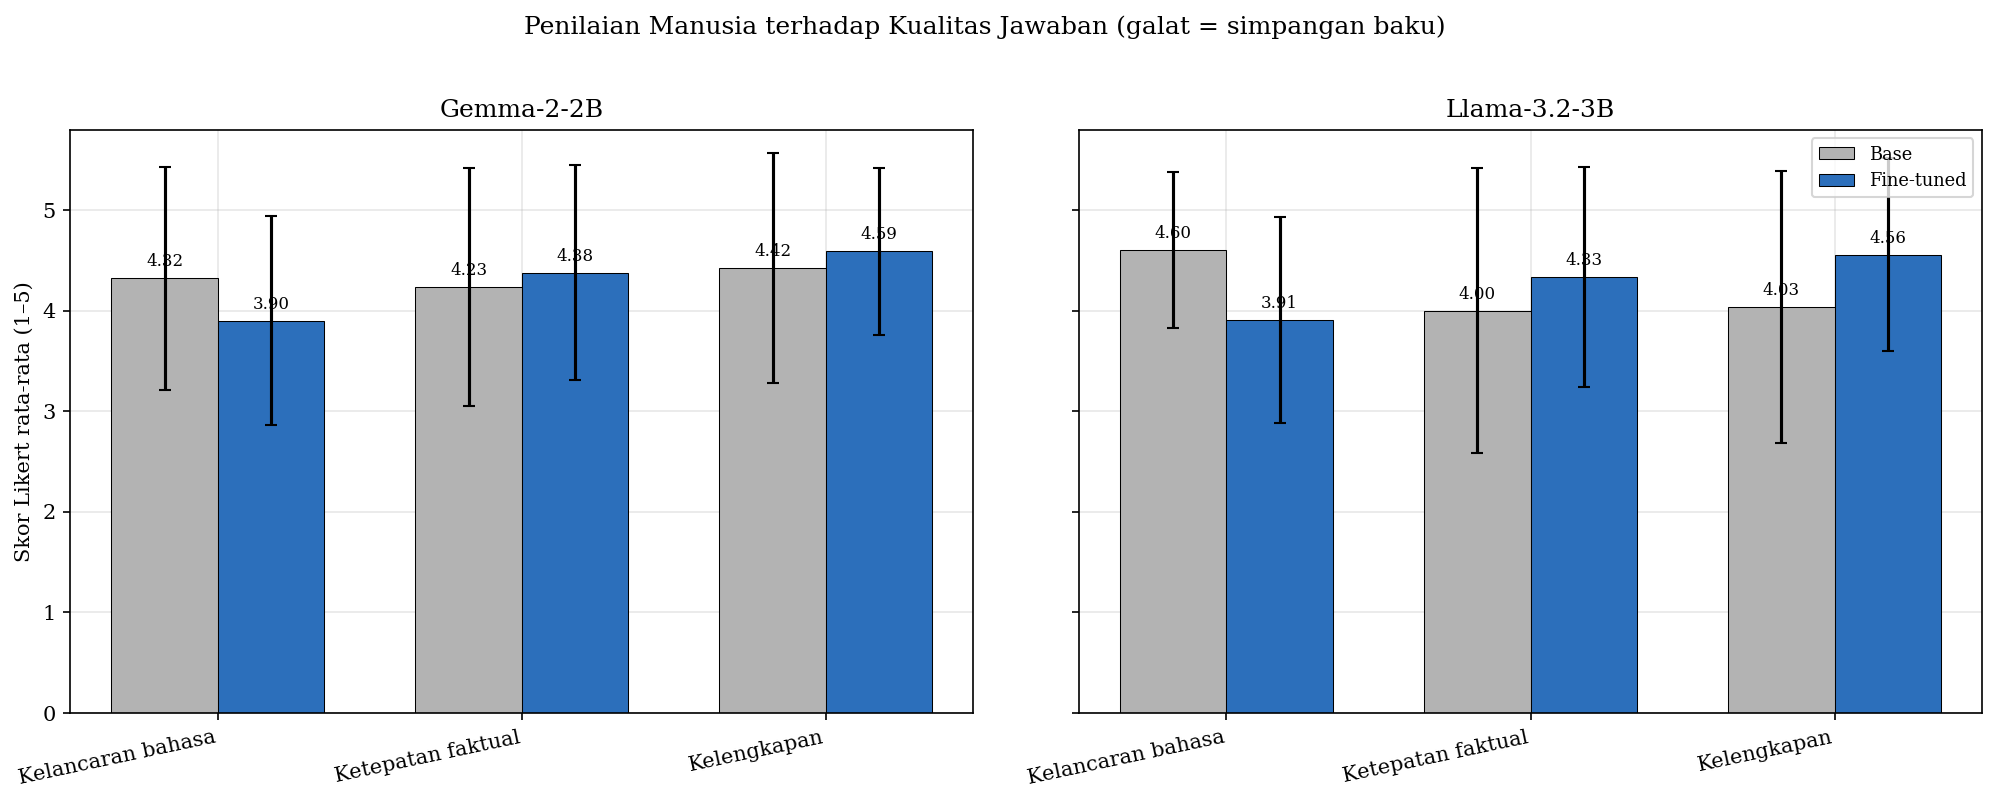

In [277]:
def fig44_skor_manusia():
    if df_human is None:
        lewati("Data evaluasi manusia belum tersedia."); return
    fig, axes = plt.subplots(1, len(MODEL_KEYS), figsize=(6.8 * len(MODEL_KEYS), 5.2), sharey=True)
    x = np.arange(len(HUMAN_CRITERIA)); w = .35
    for ax, mk in zip(axes, MODEL_KEYS):
        sub = df_human[df_human["_model_key"] == mk]
        base = [sub[sub["_condition"] == "base"][c].mean() for c in HUMAN_CRITERIA]
        ft = [sub[sub["_condition"] == "finetuned"][c].mean() for c in HUMAN_CRITERIA]
        sd_base = [sub[sub["_condition"] == "base"][c].std() for c in HUMAN_CRITERIA]
        sd_ft = [sub[sub["_condition"] == "finetuned"][c].std() for c in HUMAN_CRITERIA]
        ax.bar(x - w / 2, base, w, yerr=sd_base, capsize=3, color=C_BASE,
               edgecolor="black", linewidth=.5, label="Base")
        ax.bar(x + w / 2, ft, w, yerr=sd_ft, capsize=3, color=C_FT,
               edgecolor="black", linewidth=.5, label="Fine-tuned")
        for xi, v in zip(x - w / 2, base): ax.text(xi, v + .12, f"{v:.2f}", ha="center", fontsize=8)
        for xi, v in zip(x + w / 2, ft): ax.text(xi, v + .12, f"{v:.2f}", ha="center", fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels([HUMAN_LABELS[c] for c in HUMAN_CRITERIA],
                                             rotation=12, ha="right")
        ax.set_title(MODEL_LABELS[mk]); ax.set_ylim(0, 5.8)
    axes[0].set_ylabel("Skor Likert rata-rata (1–5)"); axes[-1].legend(fontsize=8.5)
    fig.suptitle("Penilaian Manusia terhadap Kualitas Jawaban (galat = simpangan baku)", y=1.02)
    plt.tight_layout(); plt.savefig("fig44_skor_manusia.png", bbox_inches="tight"); plt.show()

fig44_skor_manusia()

### Gambar 45 — Sebaran skor Likert dan uji beda evaluasi manusia

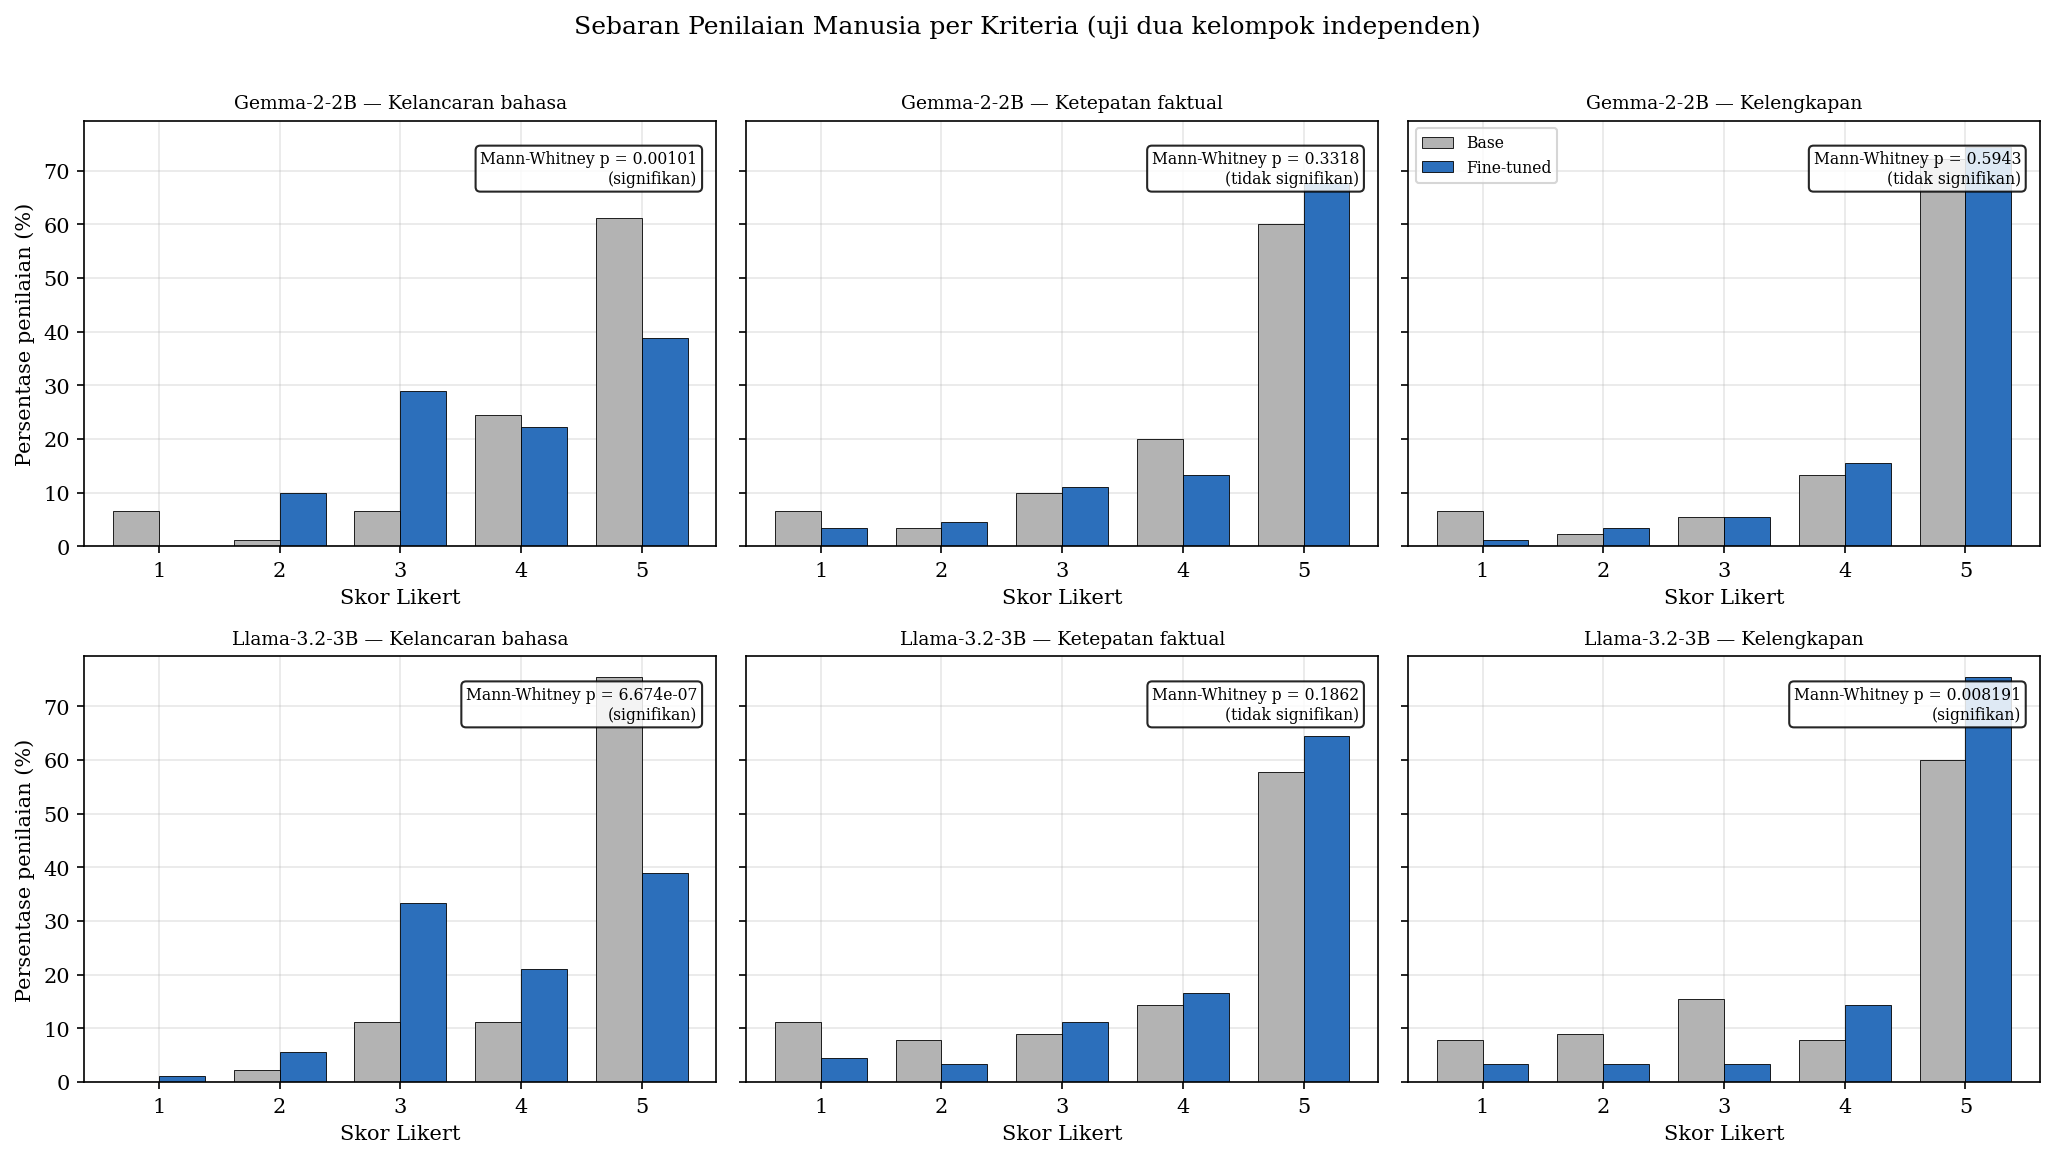

In [278]:
def fig45_sebaran_likert():
    if df_human is None:
        lewati("Data evaluasi manusia belum tersedia."); return
    fig, axes = plt.subplots(len(MODEL_KEYS), len(HUMAN_CRITERIA),
                             figsize=(4.6 * len(HUMAN_CRITERIA), 3.8 * len(MODEL_KEYS)),
                             sharey=True, squeeze=False)
    for i, mk in enumerate(MODEL_KEYS):
        sub = df_human[df_human["_model_key"] == mk]
        for j, crit in enumerate(HUMAN_CRITERIA):
            ax = axes[i][j]
            x = np.arange(1, 6); w = .38
            for k, (cond, warna) in enumerate([("base", C_BASE), ("finetuned", C_FT)]):
                prop = (sub[sub["_condition"] == cond][crit]
                        .value_counts(normalize=True).reindex(x, fill_value=0))
                ax.bar(x + (k - .5) * w, 100 * prop.values, w, color=warna,
                       edgecolor="black", linewidth=.4,
                       label="Base" if cond == "base" else "Fine-tuned")
            g1 = sub[sub["_condition"] == "finetuned"][crit]
            g2 = sub[sub["_condition"] == "base"][crit]
            if len(g1) > 0 and len(g2) > 0:
                _, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
                tanda = "signifikan" if p < .05 else "tidak signifikan"
                ax.text(.97, .93, f"Mann-Whitney p = {p:.4g}\n({tanda})", transform=ax.transAxes,
                        ha="right", va="top", fontsize=7.5,
                        bbox=dict(boxstyle="round,pad=.3", facecolor="white", alpha=.85))
            ax.set_xticks(x); ax.set_xlabel("Skor Likert")
            ax.set_title(f"{MODEL_LABELS[mk]} — {HUMAN_LABELS[crit]}", fontsize=9)
            if i == 0 and j == len(HUMAN_CRITERIA) - 1:
                ax.legend(fontsize=7.5)
    for i in range(len(MODEL_KEYS)):
        axes[i][0].set_ylabel("Persentase penilaian (%)")
    fig.suptitle("Sebaran Penilaian Manusia per Kriteria (uji dua kelompok independen)", y=1.01)
    plt.tight_layout(); plt.savefig("fig45_sebaran_likert.png", bbox_inches="tight"); plt.show()

fig45_sebaran_likert()

### Gambar 46 — Konsistensi antar-evaluator dan keraguan atas jawaban referensi
Panel (a) membandingkan kecenderungan penilaian tiap evaluator sebagai pemeriksaan kalibrasi. Panel (b) melaporkan seberapa sering evaluator justru meragukan jawaban referensi — umpan balik langsung atas kualitas dataset hasil generasi LLM.

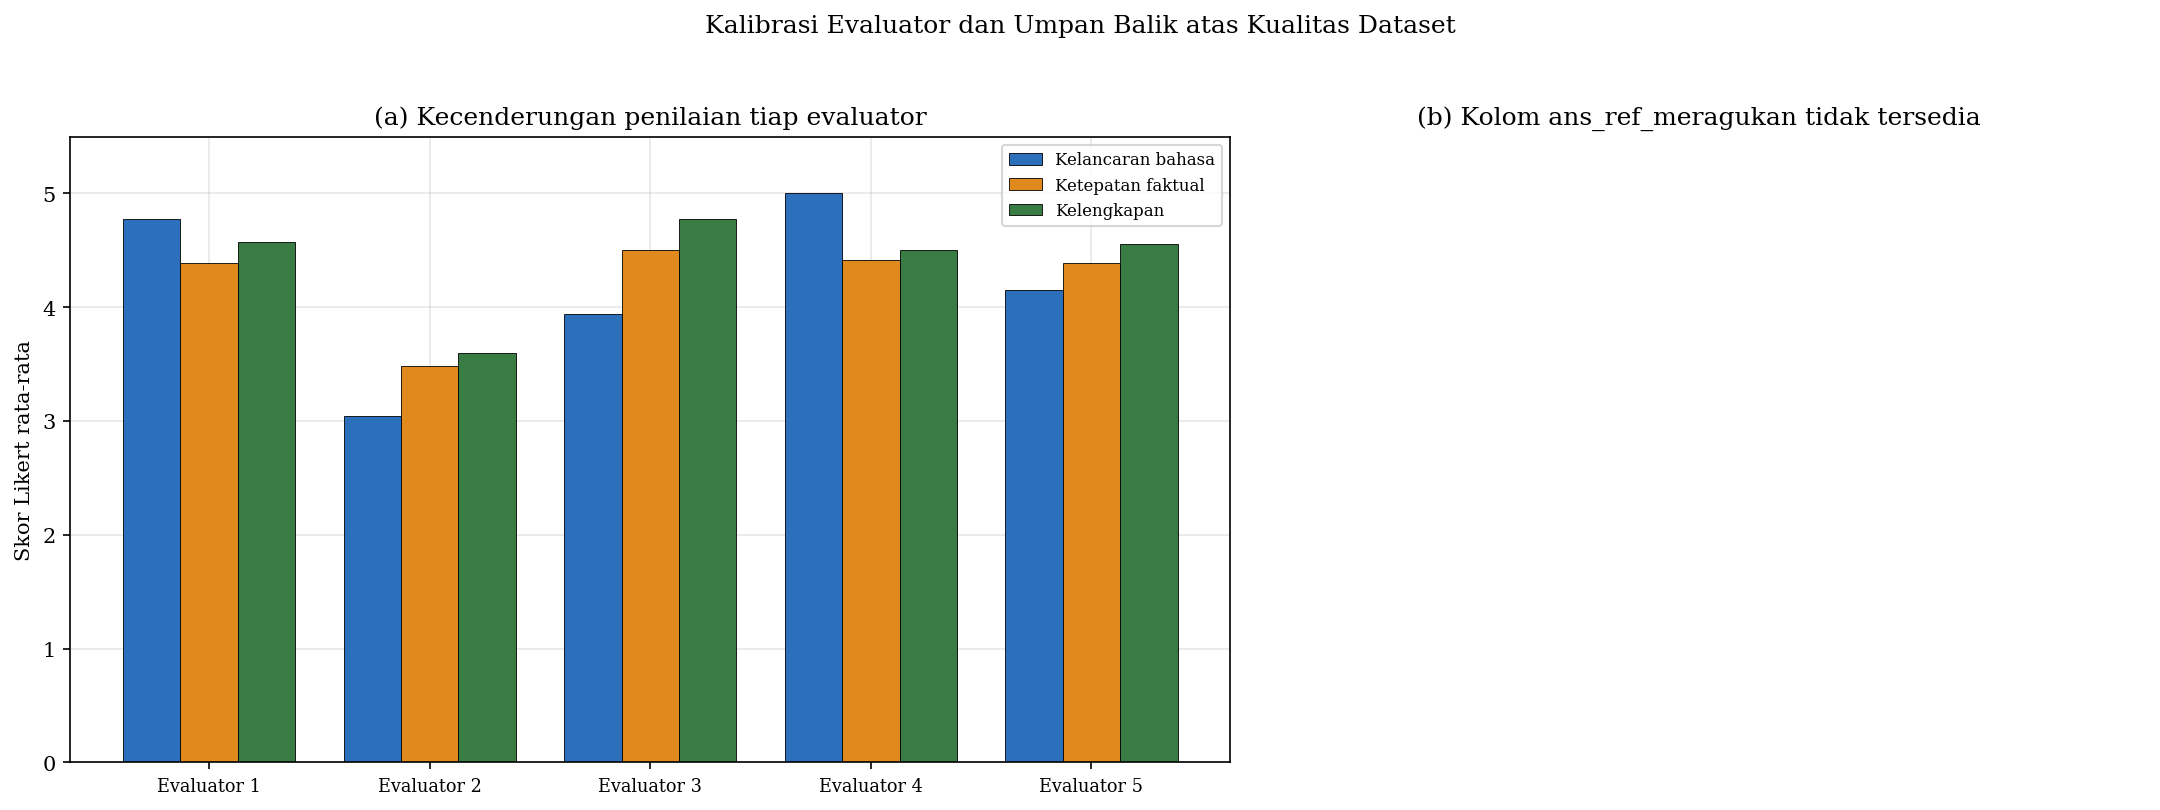

In [279]:
def fig46_konsistensi_evaluator():
    if df_human is None:
        lewati("Data evaluasi manusia belum tersedia."); return
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), gridspec_kw={"width_ratios": [1.3, 1]})

    ax = axes[0]
    x = np.arange(df_human["evaluator_id"].nunique()); w = .26
    evaluator = sorted(df_human["evaluator_id"].unique())
    for i, (crit, warna) in enumerate(zip(HUMAN_CRITERIA, [C_CLEAN, C_ACCENT, C_KEEP])):
        rerata = [df_human[df_human["evaluator_id"] == e][crit].mean() for e in evaluator]
        ax.bar(x + (i - 1) * w, rerata, w, color=warna, edgecolor="black",
               linewidth=.4, label=HUMAN_LABELS[crit])
    ax.set_xticks(x); ax.set_xticklabels([f"Evaluator {e}" for e in evaluator], fontsize=8.5)
    ax.set_ylabel("Skor Likert rata-rata"); ax.set_ylim(0, 5.5)
    ax.set_title("(a) Kecenderungan penilaian tiap evaluator"); ax.legend(fontsize=8)

    ax = axes[1]
    if "ans_ref_meragukan" not in df_human.columns:
        ax.axis("off"); ax.set_title("(b) Kolom ans_ref_meragukan tidak tersedia")
    else:
        label = [f"{MODEL_LABELS[mk]}\n{'Base' if c == 'base' else 'Fine-tuned'}"
                 for mk in MODEL_KEYS for c in CONDITIONS]
        nilai = []
        for mk in MODEL_KEYS:
            for c in CONDITIONS:
                sub = df_human[(df_human["_model_key"] == mk) & (df_human["_condition"] == c)]
                nilai.append(100 * pd.to_numeric(sub["ans_ref_meragukan"], errors="coerce").mean())
        ax.bar(label, nilai, color=[C_BASE, C_FT] * len(MODEL_KEYS),
               edgecolor="black", linewidth=.5, width=.6)
        for i, v in enumerate(nilai):
            if pd.notna(v):
                ax.text(i, v + .4, f"{v:.1f}%", ha="center", fontsize=9)
        ax.set_ylabel("Persentase item (%)"); ax.tick_params(axis="x", labelsize=8)
        ax.set_title("(b) Jawaban referensi yang diragukan evaluator")

    fig.suptitle("Kalibrasi Evaluator dan Umpan Balik atas Kualitas Dataset", y=1.03)
    plt.tight_layout(); plt.savefig("fig46_konsistensi_evaluator.png", bbox_inches="tight"); plt.show()

fig46_konsistensi_evaluator()

---
# Bagian 8 — Sintesis Akhir Tujuan 2
Menggabungkan seluruh bukti: metrik otomatis, signifikansi statistik, dan penilaian manusia, ke dalam satu tabel dan satu grafik ringkas.

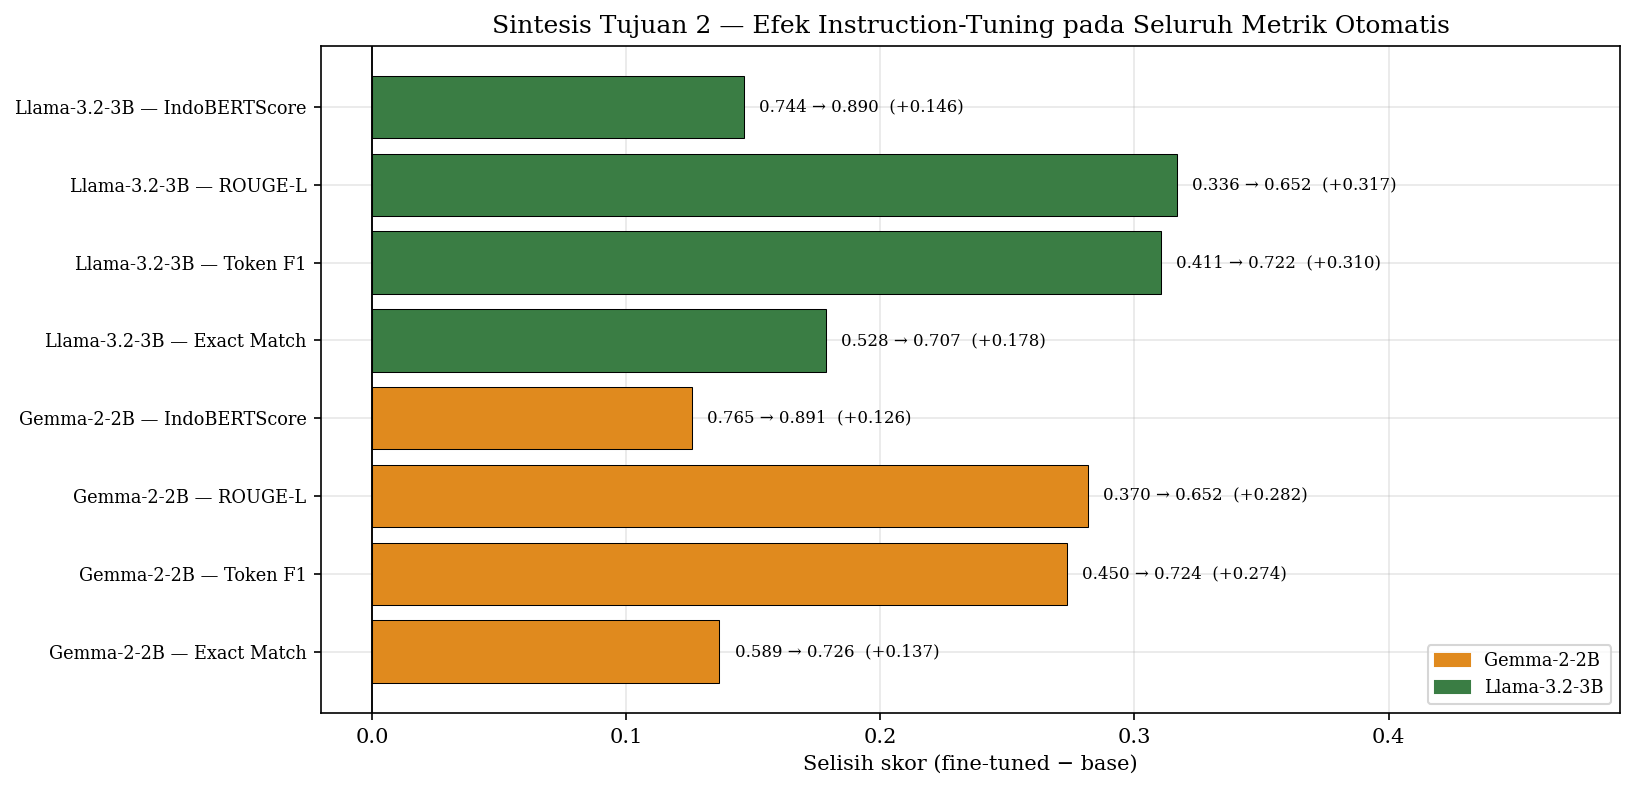

       Model             Aspek   Sumber   Base  Fine-tuned  Selisih Signifikansi
  Gemma-2-2B       Exact Match Otomatis 0.5892      0.7259   0.1367    p < 0,001
  Gemma-2-2B          Token F1 Otomatis 0.4500      0.7236   0.2735    p < 0,001
  Gemma-2-2B           ROUGE-L Otomatis 0.3701      0.6519   0.2818    p < 0,001
  Gemma-2-2B     IndoBERTScore Otomatis 0.7651      0.8911   0.1260    p < 0,001
Llama-3.2-3B       Exact Match Otomatis 0.5281      0.7066   0.1785    p < 0,001
Llama-3.2-3B          Token F1 Otomatis 0.4110      0.7215   0.3105    p < 0,001
Llama-3.2-3B           ROUGE-L Otomatis 0.3356      0.6525   0.3168    p < 0,001
Llama-3.2-3B     IndoBERTScore Otomatis 0.7435      0.8899   0.1464    p < 0,001
  Gemma-2-2B Kelancaran bahasa  Manusia 4.3220      3.9000  -0.4220   p = 0.0010
  Gemma-2-2B Ketepatan faktual  Manusia 4.2330      4.3780   0.1440   p = 0.3318
  Gemma-2-2B       Kelengkapan  Manusia 4.4220      4.5890   0.1670   p = 0.5943
Llama-3.2-3B Kelancaran baha

In [280]:
def fig47_sintesis_akhir():
    if summary is None:
        lewati("summary_metrics.csv tidak tersedia."); return None

    baris = []
    for mk in MODEL_KEYS:
        for m in METRICS:
            b = summary.loc[f"{mk}_base", m]
            f_ = summary.loc[f"{mk}_finetuned", m]
            info = {"Model": MODEL_LABELS[mk], "Aspek": METRIC_LABELS[m], "Sumber": "Otomatis",
                    "Base": round(b, 4), "Fine-tuned": round(f_, 4), "Selisih": round(f_ - b, 4)}
            if hasil_uji is not None:
                r = hasil_uji.query("model == @mk and metrik == @m")
                if len(r):
                    p = r["p_value"].iloc[0]
                    info["Signifikansi"] = ("p < 0,001" if p < .001 else f"p = {p:.4f}") if pd.notna(p) else "n/a"
            baris.append(info)
    if df_human is not None:
        for mk in MODEL_KEYS:
            sub = df_human[df_human["_model_key"] == mk]
            for c in HUMAN_CRITERIA:
                g1 = sub[sub["_condition"] == "finetuned"][c]
                g2 = sub[sub["_condition"] == "base"][c]
                p = stats.mannwhitneyu(g1, g2, alternative="two-sided")[1] if len(g1) and len(g2) else np.nan
                baris.append({"Model": MODEL_LABELS[mk], "Aspek": HUMAN_LABELS[c], "Sumber": "Manusia",
                              "Base": round(g2.mean(), 3), "Fine-tuned": round(g1.mean(), 3),
                              "Selisih": round(g1.mean() - g2.mean(), 3),
                              "Signifikansi": ("p < 0,001" if p < .001 else f"p = {p:.4f}") if pd.notna(p) else "n/a"})
    tabel = pd.DataFrame(baris)

    otomatis = tabel[tabel["Sumber"] == "Otomatis"]
    fig, ax = plt.subplots(figsize=(11, .42 * len(otomatis) + 2))
    y = np.arange(len(otomatis))
    warna = [C_GEMMA if m == MODEL_LABELS["gemma2"] else C_LLAMA for m in otomatis["Model"]]
    ax.barh(y, otomatis["Selisih"], color=warna, edgecolor="black", linewidth=.5)
    for yi, (v, b, f_) in enumerate(zip(otomatis["Selisih"], otomatis["Base"], otomatis["Fine-tuned"])):
        ax.text(v + .006, yi, f"{b:.3f} → {f_:.3f}  ({v:+.3f})", va="center", fontsize=8)
    ax.set_yticks(y); ax.set_yticklabels([f"{m} — {a}" for m, a in zip(otomatis["Model"], otomatis["Aspek"])],
                                         fontsize=8.5)
    ax.axvline(0, color="black", lw=.9)
    ax.set_xlim(-.02, max(otomatis["Selisih"]) * 1.55)
    ax.set_xlabel("Selisih skor (fine-tuned − base)")
    ax.set_title("Sintesis Tujuan 2 — Efek Instruction-Tuning pada Seluruh Metrik Otomatis")
    ax.legend(handles=[Patch(color=C_GEMMA, label=MODEL_LABELS["gemma2"]),
                       Patch(color=C_LLAMA, label=MODEL_LABELS["llama3.2"])],
              fontsize=8.5, loc="lower right")
    plt.tight_layout(); plt.savefig("fig47_sintesis_akhir.png", bbox_inches="tight"); plt.show()

    print(tabel.to_string(index=False))
    tabel.to_csv("tabel_sintesis_tujuan2.csv", index=False)
    print("\nTabel sintesis disimpan: tabel_sintesis_tujuan2.csv")
    return tabel

tabel_sintesis = fig47_sintesis_akhir()